In [155]:
from gettext import install
import pandas as pd
import numpy as np

from math import sqrt
from pathlib import Path

import warnings
from enum import Enum

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error


from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV, LassoCV, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import json
from pathlib import Path

from sklearn.model_selection import train_test_split


from pandas.core.interchange import dataframe

import matplotlib.pyplot as plt
from statsmodels.iolib import summary

from variables import ALLCLINICAL06_VARS

from numpy.linalg import lstsq
from scipy.stats import kruskal
import scikit_posthocs as sp
import statsmodels.formula.api as smf
import seaborn as sns

import xgboost

### Store TXT files as CSV

In [2]:
input_path = Path("data/input/06_input")
output_path = Path("data/output/06_output")

In [3]:
for file_path in input_path.iterdir():
    file = pd.read_csv(file_path, sep="|")
    file.to_csv(file_path.with_suffix(".csv"), sep="|", index=False)

# Explore AllClinical06 dataset and define outcome parameters for summary_metrics_06

In [4]:
# Read file
all_clinical_06 = pd.read_csv(input_path / "AllClinical06.csv", sep="|")

## Aggregate x-ray dataset for KL grade

In [5]:
"""
V06XRKL defines Kellgren and Lawrence grade from 0-4
0 = none (definite absence of x-ray changes of osteoarthritis)
1 = doubtful (doubtful joint space narrowing and possible osteophytic lipping)
2 = minimal (definite osteophytes and possible joint space narrowing)
3 = moderate (moderate multiple osteophytes, definite narrowing of joint space, some sclerosis and possible deformity of bone ends)
4 = severe (large osteophytes, marked narrowing of joint space, severe sclerosis and definite deformity of bone ends)
"""

xr_df = pd.read_csv(input_path / "KXR_SQ_BU06.csv", sep="|")

# select Kellgren and Lawrence Score and take max grade per ID and side
xr_df_grade = xr_df[["ID", "SIDE", "V06XRKL"]]
xr_df_grade = xr_df_grade.groupby(["ID", "SIDE"])["V06XRKL"].max().reset_index()

# clean label format from SIDE and V06XRKL (e.g. "1: Right" --> "Right", "2: 2" -> "2")
xr_df_grade["SIDE"] = xr_df_grade["SIDE"].str.extract(r":\s*(\w+)")
xr_df_grade["V06XRKL"] = xr_df_grade["V06XRKL"].str.extract(r":\s*(\d+)").squeeze().astype(float).astype("Int64")

# Pivot from long to wide format -> one row per ID, separate columns for Left and Right
xr_df_wide = xr_df_grade.pivot(index="ID", columns="SIDE", values="V06XRKL")
xr_df_wide.columns = [f"V06XRKL_{col}" for col in xr_df_wide.columns]
xr_df_wide = xr_df_wide.reset_index()

print(xr_df_wide)

           ID  V06XRKL_Left  V06XRKL_Right
0     9000099             4              2
1     9000296             3              2
2     9000798             4              1
3     9001695             0              3
4     9001897             1              3
...       ...           ...            ...
3659  9999295             0              2
3660  9999365             0              0
3661  9999510             3              1
3662  9999865             1              0
3663  9999878             1              2

[3664 rows x 3 columns]


### Merge with clinical dataset

In [6]:
all_clinical_06_merged = xr_df_wide.merge(all_clinical_06, on="ID", how="inner")

## Aggregate MOAKS dataset for inflammation features

In [7]:
moaks_df = pd.read_csv(input_path / "kMRI_SQ_MOAKS_BICL06.csv", sep="|")

moaks_filtered = moaks_df[(moaks_df["V06MSYIC"] != ".: Missing Form/Incomplete Workbook") & (moaks_df["V06MEFFWK"] != ".: Missing Form/Incomplete Workbook")]

moaks_filtered_synovitis = moaks_df[moaks_df["V06MSYIC"] != ".: Missing Form/Incomplete Workbook"]
moaks_filtered_effusion = moaks_df[moaks_df["V06MEFFWK"] != ".: Missing Form/Incomplete Workbook"]

# check if the ID's overlap with Accelerometry ID's
Accelerometry06 = pd.read_csv(input_path / "Accelerometry06.csv", sep="|")
accelerometry_valid_participants_06 = Accelerometry06[Accelerometry06["V06APASTAT"] != "Not participating"]

patient_ids_with_complete_moaks = set(moaks_filtered["ID"].unique())
patient_ids_with_complete_synovitis = set(moaks_filtered_synovitis["ID"].unique())
patient_ids_with_valid_accelerometry = set(accelerometry_valid_participants_06["ID"].unique())
patient_ids_with_valid_accelerometry_effusion = set(moaks_filtered_effusion["ID"].unique())

overlap = patient_ids_with_complete_moaks & patient_ids_with_valid_accelerometry

print(f"\nPatienten mit vollständigen MOAKS-Daten:       {len(patient_ids_with_complete_moaks)}")
print(f"Patienten mit gültiger Accelerometrie:         {len(patient_ids_with_valid_accelerometry)}")
print(f"Überlappung (beide Datensätze):                {len(overlap)}")
print(f"Patienten mit gültigen Synovitis:              {len(patient_ids_with_complete_synovitis)}")
print(f"Patienten mit gültigen Synovitis:              {len(patient_ids_with_valid_accelerometry_effusion)}")



Patienten mit vollständigen MOAKS-Daten:       945
Patienten mit gültiger Accelerometrie:         2127
Überlappung (beide Datensätze):                527
Patienten mit gültigen Synovitis:              945
Patienten mit gültigen Synovitis:              946


### Merge moaks parameters with clinical dataset

In [8]:
# ── Remove duplicates (all NaN values, safe to drop)
moaks_dataframe_filtered = moaks_filtered.drop_duplicates(
    subset=["ID", "SIDE"],
    keep="first",
)

rows_per_patient = moaks_dataframe_filtered.groupby("ID").size()
print(rows_per_patient.value_counts())

# ── Strip whitespace from SIDE values before pivot
moaks_dataframe_filtered["SIDE"] = moaks_dataframe_filtered["SIDE"].str.strip()

# ── Pivot to wide format: one row per patient, one column per side
moaks_wide = moaks_dataframe_filtered.pivot(
    index="ID",
    columns="SIDE",
    values=["V06MSYIC", "V06MEFFWK"],
)

# Flatten column names using the numeric part of the SIDE string (e.g. "1: Right" -> "1")
moaks_wide.columns = [
    f"{variable}_{side.split(':')[0].strip()}"
    for variable, side in moaks_wide.columns
]
moaks_wide = moaks_wide.reset_index()

# Rename columns for readability
moaks_wide = moaks_wide.rename(columns={
    "V06MSYIC_1": "synovitis_right_knee",
    "V06MSYIC_2": "synovitis_left_knee",
    "V06MEFFWK_1": "effusion_right_knee",
    "V06MEFFWK_2": "effusion_left_knee",
})

# ── Parse labelled ordinal strings to numeric (e.g. '1: Mild' → 1)
for column_name in [
    "synovitis_right_knee",
    "synovitis_left_knee",
    "effusion_right_knee",
    "effusion_left_knee",
]:
    moaks_wide[column_name] = (
        moaks_wide[column_name]
        .str.extract(r"^(\d+)", expand=False)
        .pipe(pd.to_numeric, errors="coerce")
    )

# ── Worst-knee aggregation
moaks_wide["synovitis_worst_knee"] = moaks_wide[
    ["synovitis_right_knee", "synovitis_left_knee"]
].max(axis=1)

moaks_wide["effusion_worst_knee"] = moaks_wide[
    ["effusion_right_knee", "effusion_left_knee"]
].max(axis=1)

# ── Merge with AllClinical dataframe
all_clinical_06_merged = all_clinical_06_merged.merge(
    moaks_wide,
    on="ID",
    how="left",
)

print(f"Rows after merge:                    {len(all_clinical_06_merged)}")
print(f"Missing synovitis_worst_knee values: {all_clinical_06_merged['synovitis_worst_knee'].isna().sum()}")
print(f"Missing effusion_worst_knee values:  {all_clinical_06_merged['effusion_worst_knee'].isna().sum()}")

1    876
2     69
Name: count, dtype: int64
Rows after merge:                    3664
Missing synovitis_worst_knee values: 2741
Missing effusion_worst_knee values:  2741


### Exploring missing data

In [9]:
print("Missing columns:")
for col in all_clinical_06:
    missing = all_clinical_06[col].isna().sum()
    print(f"{col}: {missing}/{len(all_clinical_06[col])}")

Missing columns:
ID: 0/4796
VERSION: 0/4796
V06BLDRAW2: 4779/4796
V06ILLPWK2: 4778/4796
V06MULTST2: 4783/4796
V06URINOB1: 978/4796
V06PLAQHR1: 1037/4796
V06BLUPMN2: 4784/4796
V06HOURSP2: 4785/4796
V06VCOLL2: 4783/4796
V06ILLPWK1: 992/4796
V06MULTST1: 1004/4796
V06VEIN2: 4783/4796
V06URUPMN2: 4787/4796
V06VCOLL1: 1005/4796
V06HOURSP1: 1022/4796
V06HRSUC1: 1020/4796
V06URNCOLL: 540/4796
V06EXCESS2: 4783/4796
V06BLDRAW1: 996/4796
V06URINHR1: 1004/4796
V06HRSUC2: 4787/4796
V06QOVP1: 1005/4796
V06EXCESS1: 1005/4796
V06BLDCOLL: 540/4796
V06SEAQHR1: 1023/4796
V06VOID1: 550/4796
V06QOVP2: 4783/4796
V06VEIN1: 1004/4796
V06OTHVP1: 1004/4796
V06SEAQHR2: 4785/4796
V06OTHVP2: 4783/4796
V06URINHR2: 4787/4796
V06HEMAT1: 1005/4796
V06LEAKAG2: 4783/4796
V06BLSURD1: 4003/4796
V06BLDHRS1: 1021/4796
V06URSURD1: 3995/4796
V06URUPMN1: 1012/4796
V06HEMAT2: 4783/4796
V06LEAKAG1: 1005/4796
V06BLSURD2: 4793/4796
V06VOID2: 4659/4796
V06PLAQHR2: 4785/4796
V06URINOB2: 4665/4796
V06BLDHRS2: 4784/4796
V06URSURD2: 47

## Redundancy reduction for outcome parameter selection

In [10]:
pain_cols = [
        "ID",
        "V06KOOSKPR",  # Right knee: KOOS Pain Score, 0-100
        "V06WOMKPR",   # Right knee: WOMAC Pain Score, 0-20
        "V06CPSKR",  # ICOAP Right knee: Constant Pain Score, 0-100
        "V06IPSKR",  # ICOAP Right knee: Intermittent Pain Score, 0-100
        "V06ICPTSKR",  # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100
        "V06P7RKFR",  # Right knee pain: how often, 0-4 (never, monthly, weekly, daily, always)
        "V06P7RKACV",  # Right knee pain: on average, past 7 days, rated on scale of 0-10
        "V06P7RKRCV",  # Right knee pain: severity, past 7 days, rated on scale of 0-10

        "V06KOOSKPL",  # Left knee: KOOS Pain Score (calc)
        "V06WOMKPL",  # Left knee: WOMAC Pain Score (calc)
        "V06CPSKL",  # ICOAP Left knee: Constant Pain Score (calc)
        "V06IPSKL",  # ICOAP Left knee: Intermittent Pain Score (calc)
        "V06ICPTSKL",  # ICOAP Left knee: Intermittent and Constant Pain Total Score (calc)
        "V06P7LKFR",  # Left knee pain: how often
        "V06P7LKACV",  # Left knee pain: on average, past 7 days, rated on scale of 0-10 (calc)
        "V06P7LKRCV",  # Left knee pain: severity, past 7 days, rated on scale of 0-10 (calc)

        "V06KGLRS",  # Considering all ways knee pain and arthritis affect you, how are you doing today? (0–10 scale)
    ]

sleep_cols = [
        "V06CESD11",  # FU SAQ:Q31k.CES-D: how often sleep was restless, past week 0-3
        "V06WPLKN3",  # FU INT:*Left knee pain: in bed, last 7 days, 0-4
        "V06WPRKN3",  # FU INT:*Right knee pain: in bed, last 7 days, 0-4
        "V06CPLKN2",  # FU INT:Q53r.ICOAP: Left knee constant pain: how much affected sleep, past 7 days
        "V06CPRKN2",  # FU INT:Q53d.ICOAP: Right knee constant pain: how much affected sleep, past 7 days
        "V06IPLKN3",  # FU INT:Q53y.ICOAP: Left knee intermittent pain: how much affected sleep, past 7 days
        "V06IPRKN3",  # FU INT:Q53k.ICOAP: Right knee intermittent pain: how much affected sleep, past 7 days
    ]

function_cols = [
        "V0620MPACE",  # 20-meter walk: pace (m/sec)
        "V06STEPST1",  # 20-meter walk: trial 1 number of steps
        "V06STEPST2",  # 20-meter walk: trial 2 number of steps
        "V06TIMET1",   # 20-meter walk: trial 1 time to complete (sec.hundredths/sec)
        "V06TIMET2",   # 20-meter walk: trial 2 time to complete (sec.hundredths/sec)
        "V06WLK20T1",  # 20-meter walk: trial 1 result
        "V06WLK20T2",  # 20-meter walk: trial 2 result
        "V06WLKAID",   # 20-meter walk: using walking aid such as cane

        "V06400EXCL",  # FU WBK:400-meter walk: reason excluded
        "V06400MCMP",  # FU WBK:400-meter walk: completion status
        "V06400MTIM",  # FU WBK:400-meter walk: total time at 400-m or at stop (sec)
        "V06400MTR",   # FU WBK:400-meter walk: total meters walked
        "V06400PAIN",  # FU WBK:400-meter walk: knee pain, which leg
        "V06CANEUSE",  # FU WBK:Q10.400-meter walk: use cane
        "V06COMP10",   # FU WBK:Q11.400-meter walk: complete full 10 laps
        "V06DISCOMF",  # FU WBK:Q12.400-meter walk: any discomfort
        "V06DKP400W",  # FU WBK:Q13.400-meter walk: knee pain during walk, don't know
        "V06HR135",    # FU WBK:Q9.400-meter walk: heart rate exceed 135 bpm during walk
        "V06HR400WK",  # FU WBK:Q8.400-meter walk: heart rate at 400-m or at stop
        "V06HRB4WLK",  # FU WBK:Q1.400-meter walk: heart rate before walk
        "V06LPN400W",  # FU WBK:Q13.400-meter walk: left knee pain during walk
        "V06LPWKPRV",  # FU WBK:Q13ii.400-meter walk: left knee pain prevent walking at usual pace
        "V06LPWKTYP",  # FU WBK:Q13i.400-meter walk: left knee pain mild, moderate or severe
        "V06NPN400W",  # FU WBK:Q13.400-meter walk: no knee pain during walk
        "V06NUMSTOP",  # FU WBK:Q4.400-meter walk: total number rest stops
        "V06OTH400W",  # FU WBK:Q12a.400-meter walk: type of discomfort, other
        "V06PN400W",   # FU WBK:Q12a.400-meter walk: type of discomfort, pain
        "V06REASW1",   # FU WBK:Q11a.400-meter walk: not able to complete 10 laps
        "V06REASW2",   # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, began walk but could not complete
        "V06REASW3",   # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, heart rate exceeded 135 bpm during walk and did not feel well
        "V06REASW4",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, heart rate fell below 40 bpm during walk
        "V06REASW5",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported felt too tired during walk
        "V06REASW6",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported chest pain during walk
        "V06REASW7",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported shortness of breath during walk
        "V06REASW8",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported feeling faint during walk
        "V06REASW9",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported knee pain during walk
        "V06REASW10",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported hip pain during walk
        "V06REASW11",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported calf pain during walk
        "V06REASW12",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, reported back pain during walk
        "V06REASW13",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, sat down during walk
        "V06REASW14",
        # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, more than 15 minutes elapsed from start of test
        "V06REASW15",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, refused
        "V06REASW16",  # FU WBK:Q11a.400-meter walk: not able to complete 10 laps, other
        "V06RESTT1",  # FU WBK:Q3a.400-meter walk: rest stop #1
        "V06RESTT2",  # FU WBK:Q3b.400-meter walk: rest stop #2
        "V06RESTT3",  # FU WBK:Q3c.400-meter walk: rest stop #3
        "V06RESTT4",  # FU WBK:Q3d.400-meter walk: rest stop #4
        "V06RESTT5",  # FU WBK:Q3e.400-meter walk: rest stop #5
        "V06RESTT6",  # FU WBK:Q3f.400-meter walk: rest stop #6
        "V06RESTT7",  # FU WBK:Q3g.400-meter walk: rest stop #7
        "V06RESTT8",  # FU WBK:Q3h.400-meter walk: rest stop #8
        "V06RESTT9",  # FU WBK:Q3i.400-meter walk: rest stop #9
        "V06RESTT10",  # FU WBK:Q3j.400-meter walk: rest stop #10
        "V06RFP400W",  # FU WBK:Q13.400-meter walk: knee pain during walk, refused
        "V06RPN400W",  # FU WBK:Q13.400-meter walk: right knee pain during walk
        "V06RPWKPRV",  # FU WBK:Q13ii.400-meter walk: right knee pain prevent from walking at usual pace
        "V06RPWKTYP",  # FU WBK:Q13i.400-meter walk: right knee pain mild, moderate or severe
        "V06SOB400W",  # FU WBK:Q12a.400-meter walk: type of discomfort, shortness of breath

        "V06SAFEWLK",  # FU WBK:Q12.400-meter walk eligibility: feel it would be safe to try to walk up and down hallway
        "V06SYSELG",
        # FU WBK:400-meter walk eligibility: meets new or old systolic blood pressure exclusion criterion (calc)
        "V06W20COMP",  # FU WBK:Q1.400-meter walk eligibility: able to complete trial 1 and trial 2 of the 20-meter walk
        "V06WALKER",  # FU WBK:Q6.400-meter walk eligibility: use walker or quad cane when walk
        "V06WHE400W",  # FU WBK:Q12a.400-meter walk: type of discomfort, wheezing/dyspnea
        "V06CALLDOC",
        # FU WBK:Q7.400-meter walk eligibility: had to see or call doctor for worsening angina (chest or heart pain) or worsening shortness of breath, past 3 months
        "V06DIASELG",
        # FU WBK:400-meter walk eligibility: meets new or old diastolic blood pressure exclusion criterion (calc)
        "V06HOSPSUR",
        # FU WBK:400-meter walk eligibility: meets new or old hospitalization/surgery exclusion criteria (calc)
        "V06HRELG",
        # FU WBK:400-meter walk eligibility: meets old or new heart rate exclusion criterion (calc) 18 Informat Label

        "V06CSTSGL",  # FU WBK:Single chair stand
        "V06CSTREP1",  # FU WBK:Repeated chair stands: trial 1
        "V06CSTIME1",  # WBK:Repeated chair stands: trial 1 time (sec.hundredths/sec) 12
        "V06CSTNUM1",
        # FU WBK:Repeated chair stands: trial 1, attempted, unable to complete: number completed without using arms
        "V06CSTIME2",  # 6.2 6.2 FU WBK:Repeated chair stands: trial 2 time (sec.hundredths/sec)
        "V06CSTNUM2",
        # FU WBK:Repeated chair stands: trial 2, attempted, unable to complete: number completed without using arms
        "V06CSTREP2",  # FU WBK:Repeated chair stands: trial 2
        "V06CS5",  # FU WBK:Repeated chair stands: able to complete 5 stands (calc)
        "V06CSPACE",  # FU WBK:Repeated chair stand: pace in stands/sec (calc)
    ]

depression_cols = [
        "V06CESD5",  # FU SAQ:Q31e.CES-D: how often had trouble keeping mind on what was doing, past week
        "V06CESD6",  # FU SAQ:Q31f.CES-D: how often felt depressed, past week
        "V06CESD7",  # FU SAQ:Q31g.CES-D: how often felt that everything did was an effort, past week
        "V06CESD10",  # FU SAQ:Q31j.CES-D: how often felt fearful, past week
        "V06CESD11",  # FU SAQ:Q31k.CES-D: how often sleep was restless, past week 9 Informat Label
        "V06CESD16",  # FU SAQ:Q31p.CES-D: how often enjoyed life, past week
        "V06CESD17",  # FU SAQ:Q31q.CES-D: how often had crying spells, past week
        "V06CESD20",  # FU SAQ:Q31t.CES-D: how often could not get going, past week
        "V06CESD",  # FU SAQ:CES-D: Center for Epidemiologic Studies Depression Scale (CES-D) Score
    ]

coping_strategies_cols = [
        "V06CSQCAT",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Catastrophizing
        "V06CSQIGSN",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Ignoring Sensations
        "V06CSQCSS",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Coping Self-Statements
        "V06CSQDVAT",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Diverting Attention
        "V06CSQRPS",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Reinterpreting Pain Sensations
        "V06CSQPRHP",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Praying or Hoping
        "V06CSQIBA",  # FU INT:CSQ: Coping Strategies Questionnaire Score, Increased Behavioral Activities
    ]

ADL_cols = [
         # ADL
        "V06ADL1",
        # FU INT:Q83.ADL: Any difficulty dressing, including putting on shoes and socks, because of health or memory problem
        "V06ADL2",  # FU INT:Q84.ADL: Any difficulty walking across a room because of health or memory problem
        "V06ADL3",  # FU INT:Q85.ADL: Ever use equipment or device such as cane, walker, or wheelchair when crossing a room
        "V06ADL4",  # FU INT:Q86.ADL: Does anyone ever help you get across a room
        "V06ADL5",
        # FU INT:Q87.ADL: Any difficulty bathing or showering because of health or memory problem 4 Informat Label
        "V06ADL6",  # FU INT:Q88.ADL: Any difficulty eating, such as cutting up food, because of health or memory problem
        "V06ADL7",  # FU INT:Q89.ADL: Any difficulty getting in or out of bed because of health or memory problem
        "V06ADL8",
        # FU INT:Q90.ADL: Ever use equipment or device such as cane, walker, or railing when getting in or out of bed
        "V06ADL9",  # FU INT:Q91.ADL: Does anyone every help you get in or out of bed
        "V06ADL10",
        # FU INT:Q92.ADL: Any difficulty using toilet, including getting up and down, because of health or memory problem 89 Variables in Creation Order Informat Label
        "V06ADL7A",
        # FU INT:Q89a.ADL: Use equipment or device such as cane, walker, or railing when getting in or out of bed
        "V06IADL2",  # FU INT:Q94.IADL: Any difficulty shopping for groceries because of health or memory problem
        "V06IADL2II",  # FU INT:Q94ii.IADL: does any help you shop for groceries 19

        # ADL / Late Life Disability (LLD)
        "V06LLD2A",  # FU SAQ:QD2a.LLDI: How often visit friends and family in their homes
        "V06LLD2B",  # FU SAQ:QD2b.LLDI: What extent feel limited in visiting friends and family in their homes
        "V06LLD4A",
        # FU SAQ:QD4a.LLDI: How often take care of the inside of your home (e.g., homemaking, laundry, housecleaning, minor household repairs)
        "V06LLD4B",
        # FU SAQ:QD4b.LLDI: What extent feel limited taking care of the inside of your home (e.g., homemaking, laundry, housecleaning, minor household repairs)
        "V06LLD5A",  # FU SAQ:QD5a.LLDI: How often work at volunteer job outside your home
        "V06LLD5B",  # FU SAQ:QD5b.LLDI: What extent feel limited working at volunteer job outside your home
        "V06LLD6A",
        # FU SAQ:QD6a.LLDI: How often take part in active recreation (e.g., bowling, golf, tennis, hiking, jogging, swimming)
        "V06LLD6B",  # FU SAQ:QD6b.LLDI: What extent feel limited in taking part in active recreation
        "V06LLD9A",  # FU SAQ:QD9a.LLDI: How often travel out of town for at least an overnight stay 28 Informat Label
        "V06LLD9B",  # FU SAQ:QD9b.LLDI: What extent feel limited in traveling out of town for at least an overnight stay
        "V06LLD10A",
        # FU SAQ:QD10a.LLDI: How often take part in regular fitness program (e.g., walking for exercise, stationary biking, weight lifting, exercise class)
        "V06LLD10B",
        # FU SAQ:QD10b.LLDI: What extent feel limited in taking part in regular fitness program (e.g., walk for exercise, stationary bike, weight lift, exercise class)
        "V06LLD11A",  # FU SAQ:QD11a.LLDI: How often invite people into your home for meal or entertainment
        "V06LLD11B",
        # FU SAQ:QD11b.LLDI: What extent feel limited in inviting people into your home for meal or entertainment
        "V06LLD12A",  # FU SAQ:QD12a.LLDI: How often go out with others to public places (e.g., restaurants, movies)
        "V06LLD12B",
        # FU SAQ:QD12b.LLDI: What extent feel limited in going out with others to public places (e.g., restaurants, movies)
        "V06LLD13A",
        # FU SAQ:QD13a.LLDI: How often take care of your own personal care needs (e.g., bathing, dressing, toileting)
        "V06LLD13B",
        # FU SAQ:QD13b.LLDI: What extent feel limited in taking care of your own personal care needs (e.g., bathing, dressing, toileting)
        "V06LLD14A",
        # FU SAQ:QD14a.LLDI: How often take part in organized social activities (e.g., clubs, card playing, senior center events, community or religious groups)
        "V06LLD14B",
        # FU SAQ:QD14a.LLDI: What extent feel limited taking part in organized social activities(e.g.,clubs,card playing,senior center events,community/religious groups) 88 Variables in Creation Order Informat Label
        "V06LLD15A",
        # FU SAQ:QD15a.LLDI: How often take care of local errands (e.g., shopping for food/personal items, going to bank, library, or dry cleaner)
        "V06LLD15B",
        # FU SAQ:QD15b.LLDI: What extent feel limited in taking care of local errands (e.g., shopping for food/personal items, going to bank, library, or dry cleaner)
        "V06LLD16A",
        # FU SAQ:QD16a.LLDI: How often prepare meals for yourself (e.g., planning, cooking, serving, cleaning up)
        "V06LLD16B",
        # FU SAQ:QD16b.LLDI: What extent feel limited in preparing meals for yourself (e.g., planning, cooking, serving, cleaning up)

        "V06LLDIFSP",
        # FU SAQ:LLDI: Late Life Disability Instrument, Frequency Dimension, Personal Role Domain Score (calc)
        "V06LLDIFSS",  # FU SAQ:LLDI: Late Life Disability Instrument, Frequency Dimension, Social Role Domain Score (calc)
        "V06LLDIFST",  # FU SAQ:LLDI: Late Life Disability Instrument, Frequency Dimension, Total Score (calc)
        "V06LLDILSI",
        # FU SAQ:LLDI: Late Life Disability Instrument, Limitation Dimension, Instrumental Role Domain Score (calc)
        "V06LLDILSM",
        # FU SAQ:LLDI: Late Life Disability Instrument, Limitation Dimension, Management Role Domain Score (calc)
        "V06LLDILST",  # FU SAQ:LLDI: Late Life Disability Instrument, Limitation Dimension, Total Score (calc)
    ]

function_koos_womac_cols = [
        # KOOS / WOMAC / Function
        "V06DIRKN1",  # FU INT:*Right knee difficulty: down stairs, last 7 days
        "V06DIRKN2",  # FU INT:*Right knee difficulty: up stairs, last 7 days
        "V06DIRKN3",  # FU INT:*Right knee difficulty: stand from sitting, last 7 days
        "V06DIRKN4",  # FU INT:*Right knee difficulty: standing, last 7 days
        "V06DIRKN5",  # FU INT:*Right knee difficulty: bending, last 7 days
        "V06DIRKN6",  # FU INT:*Right knee difficulty: walking, last 7 days
        "V06DIRKN7",  # FU INT:*Right knee difficulty: in car/out of car, last 7 days
        "V06DIRKN8",  # FU INT:*Right knee difficulty: shopping, last 7 days
        "V06DIRKN9",  # FU INT:*Right knee difficulty: socks on, last 7 days
        "V06DIRKN10", # FU INT:*Right knee difficulty: get out of bed, last 7 days
        "V06DIRKN11",  # FU INT:*Right knee difficulty: socks off, last 7 days
        "V06DIRKN12",  # FU INT:*Right knee difficulty: lying down, last 7 days
        "V06DIRKN13",  # FU INT:*Right knee difficulty: get in/out of bathtub, last 7 days
        "V06DIRKN14",  # FU INT:*Right knee difficulty: sitting, last 7 days
        "V06DIRKN15",  # FU INT:*Right knee difficulty: on/off toilet, last 7 days
        "V06DIRKN16",  # FU INT:*Right knee difficulty: heavy chores, last 7 days
        "V06DIRKN17",  # FU INT:*Right knee difficulty: light chores, last 7 days

        "V06DILKN1",  # FU INT:*Left knee difficulty: down stairs, last 7 days
        "V06DILKN2",  # FU INT:*Left knee difficulty: up stairs, last 7 days
        "V06DILKN3",  # FU INT:*Left knee difficulty: stand from sitting, last 7 days
        "V06DILKN4",  # FU INT:*Left knee difficulty: standing, last 7 days
        "V06DILKN5",  # FU INT:*Left knee difficulty: bending, last 7 days
        "V06DILKN6",  # FU INT:*Left knee difficulty: walking, last 7 days
        "V06DILKN7",  # FU INT:*Left knee difficulty: in car/out of car, last 7 days
        "V06DILKN8",  # FU INT:*Left knee difficulty: shopping, last 7 days
        "V06DILKN9",  # FU INT:*Left knee difficulty: socks on, last 7 days
        "V06DILKN10",  # FU INT:*Left knee difficulty: get out of bed, last 7 days
        "V06DILKN11",  # FU INT:*Left knee difficulty: socks off, last 7 days
        "V06DILKN12",  # FU INT:*Left knee difficulty: lying down, last 7 days
        "V06DILKN13",  # FU INT:*Left knee difficulty: get in/out of bathtub, last 7 days
        "V06DILKN14",  # FU INT:*Left knee difficulty: sitting, last 7 days
        "V06DILKN15",  # FU INT:*Left knee difficulty: on/off toilet, last 7 days
        "V06DILKN16",  # FU INT:*Left knee difficulty: heavy chores, last 7 days
        "V06DILKN17",  # FU INT:*Left knee difficulty: light chores, last 7 days

        "V06KOOSFX1",  # FU INT:*Q48a.Either knee difficulty: squatting, last 7 days
        "V06KOOSFX2",  # FU INT:*Q48b.Either knee difficulty: running, last 7 days
        "V06KOOSFX3",  # FU INT:*Q48c.Either knee difficulty: jumping, last 7 days
        "V06KOOSFX4",  # FU INT:*Q48d.Either knee difficulty: twisting/pivoting on injured knee, last 7 days
        "V06KOOSFX5",  # FU INT:*Q48e.Either knee difficulty: kneeling, last 7 days
    ]

pase_cols = [
        "V06PASE",  # FU INT:Physical Activity Scale for the Elderly (PASE) score (calc)
        "V06PASE1",  # FU INT:Leisure activities: sitting, past 7 days
        "V06PASE2",  # FU INT:Leisure activities: walking, past 7 days
        "V06PASE3",  # FU INT:Leisure activities: light sport/recreation, past 7 days
        "V06PASE4",  # FU INT:Leisure activities: moderate sport/recreation, past 7 days
        "V06PASE5",  # FU INT:Leisure activities: strenuous sport/recreation, past 7 days
        "V06PASE6",  # FU INT:Leisure activities: muscle strength/endurance, past 7 days
        "V06PASE1HR",  # FU INT:Leisure activities: sitting, hours per day, past 7 days
        "V06PASE2HR",  # FU INT:Leisure activities: walking, hours per day, past 7 days
        "V06PASE3HR",  # FU INT:Leisure activities: light sport/recreation, hours per day, past 7 days
        "V06PASE4HR",  # FU INT:Leisure activities: moderate sport/recreation, hours per day, past 7 days
        "V06PASE5HR",  # FU INT:Leisure activities: strenuous sport/recreation, hours per day, past 7 days
        "V06PASE6HR",  # FU INT:Leisure activities: muscle strength/endurance, hours per day, past 7 days 34
        "V06HOUACT1",  # FU INT:Household activities: light housework, past 7 days
        "V06HOUACT2",  # FU INT:Household activities: heavy housework, past 7 days
        "V06HOUACT3",  # FU INT:Household activities: home repairs, past 7 days
        "V06HOUACT4",  # FU INT:Household activities: lawn work/yard care, past 7 days
        "V06HOUACT5",  # FU INT:Household activities: outdoor gardening, past 7 days
        "V06HOUACT6",  # FU INT:Household activities: caring for another person, past 7 days
    ]

replacement_cols = [
         "V06HRS12",
        # FU INT:Q56.Had hip replacement surgery where all or part of joint was replaced, since last visit about 12 months ago
        "V06SREPHR", # FU INT:Ever have hip replacement surgery where all or part of joint was replaced, self-report (calc)
    ]

### Redundancy function

In [11]:
def compute_spearman_correlation_matrix(
    dataframe: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    """
    Compute a pairwise Spearman correlation matrix for the given columns.

    Missing values are handled pairwise. Columns with fewer than 10
    joint observations are set to NaN. Constant input pairs are silently
    set to NaN rather than raising a ConstantInputWarning.

    :param dataframe: DataFrame containing the columns.
    :param columns: List of column names to include.
    :returns: Symmetric DataFrame of Spearman correlation coefficients.
    """
    import warnings
    from scipy.stats import ConstantInputWarning

    valid_columns = [
        column for column in columns
        if column in dataframe.columns
        and pd.api.types.is_numeric_dtype(dataframe[column])
        and dataframe[column].nunique() > 1
    ]

    number_of_columns = len(valid_columns)
    correlation_matrix = pd.DataFrame(
        data=np.eye(number_of_columns),
        index=valid_columns,
        columns=valid_columns,
    )

    for index_i, column_i in enumerate(valid_columns):
        for index_j in range(index_i + 1, number_of_columns):
            column_j = valid_columns[index_j]
            joint_observations = dataframe[[column_i, column_j]].dropna()

            if len(joint_observations) < 10:
                correlation_matrix.loc[column_i, column_j] = np.nan
                correlation_matrix.loc[column_j, column_i] = np.nan
                continue

            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConstantInputWarning)
                rho, _ = stats.spearmanr(
                    joint_observations[column_i],
                    joint_observations[column_j],
                )

            if np.isnan(rho):
                correlation_matrix.loc[column_i, column_j] = np.nan
                correlation_matrix.loc[column_j, column_i] = np.nan
            else:
                correlation_matrix.loc[column_i, column_j] = rho
                correlation_matrix.loc[column_j, column_i] = rho

    return correlation_matrix

def print_redundant_pairs(
    correlation_matrix: pd.DataFrame,
    redundancy_threshold: float = 0.85,
) -> pd.DataFrame:
    """
    Print and return all variable pairs exceeding the redundancy threshold.

    :param correlation_matrix: Pairwise Spearman correlation matrix.
    :param redundancy_threshold: Absolute correlation above which two
        variables are considered redundant. Defaults to 0.85.
    :returns: DataFrame of redundant pairs sorted by correlation strength,
        or an empty DataFrame if no redundant pairs are found.
    """
    variables = list(correlation_matrix.columns)
    redundant_pairs = []

    for index_i, variable_i in enumerate(variables):
        for index_j in range(index_i + 1, len(variables)):
            variable_j = variables[index_j]
            rho = correlation_matrix.loc[variable_i, variable_j]

            if pd.isna(rho):
                continue

            if abs(rho) >= redundancy_threshold:
                redundant_pairs.append({
                    "variable_a": variable_i,
                    "variable_b": variable_j,
                    "spearman_rho": round(rho, 3),
                })

    print(f"\nRedundant pairs (|ρ| ≥ {redundancy_threshold})")
    print(f"{'Variable A':<20} {'Variable B':<20} {'ρ':>6}")
    print("-" * 50)

    # --- early return BEFORE attempting sort ---
    if not redundant_pairs:
        print("No redundant pairs found — all variables are sufficiently distinct.")
        return pd.DataFrame(columns=["variable_a", "variable_b", "spearman_rho"])

    pairs_dataframe = pd.DataFrame(redundant_pairs).sort_values(
        by="spearman_rho",
        ascending=False,
    ).reset_index(drop=True)

    for _, row in pairs_dataframe.iterrows():
        print(
            f"{row['variable_a']:<20} "
            f"{row['variable_b']:<20} "
            f"{row['spearman_rho']:>6.3f}"
        )
    print(f"\n{len(pairs_dataframe)} redundant pairs found.")

    return pairs_dataframe

### Assess redundancy among pain variables

In [12]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns=pain_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06IPSKR             V06ICPTSKR            0.924
V06IPSKL             V06ICPTSKL            0.918
V06P7LKACV           V06P7LKRCV            0.894
V06P7RKACV           V06P7RKRCV            0.884
V06P7LKFR            V06P7LKRCV            0.868
V06WOMKPR            V06P7RKRCV            0.863
V06WOMKPL            V06P7LKRCV            0.860
V06ICPTSKL           V06P7LKRCV            0.860
V06KOOSKPR           V06P7RKRCV           -0.893
V06KOOSKPL           V06P7LKRCV           -0.905
V06KOOSKPR           V06P7RKFR            -0.916
V06KOOSKPL           V06WOMKPL            -0.930
V06KOOSKPL           V06P7LKFR            -0.930
V06KOOSKPR           V06WOMKPR            -0.938

14 redundant pairs found.


### Assess redundancy among sleep variables

In [13]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns=sleep_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06CPRKN2            V06IPRKN3             0.932
V06CPLKN2            V06IPLKN3             0.891

2 redundant pairs found.


### Assess redundancy among function variables

In [14]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= function_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06400MTR            V06COMP10             1.000
V06STEPST1           V06STEPST2            0.966
V06TIMET1            V06TIMET2             0.958
V06CSTIME1           V06CSTIME2            0.950
V06400EXCL           V06400MCMP            0.900
V06400EXCL           V06COMP10            -0.880
V06WLK20T1           V06W20COMP           -0.966
V06CSTIME1           V06CSPACE            -0.966
V06400MCMP           V06400MTR            -0.978
V0620MPACE           V06TIMET1            -0.987
V0620MPACE           V06TIMET2            -0.991
V06CSTREP1           V06CS5               -0.992
V06400MCMP           V06COMP10            -0.994
V06CSTIME2           V06CSPACE            -0.994
V06WLK20T2           V06W20COMP           -1.000

15 redundant pairs found.


### Assess redundancy among depression variables

In [15]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= depression_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
No redundant pairs found — all variables are sufficiently distinct.


### Assess redundancy among coping strategies variables

In [16]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= coping_strategies_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
No redundant pairs found — all variables are sufficiently distinct.


### Assess redundancy among ADL variables

In [17]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= ADL_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06LLDILSI           V06LLDILST            0.991
V06LLDIFSS           V06LLDIFST            0.918
V06LLD11B            V06LLDILSM            0.903

3 redundant pairs found.


### Assess redundancy among function KOOS/WOMAC variables


In [18]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= function_koos_womac_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
V06DILKN9            V06DILKN11            0.914
V06KOOSFX2           V06KOOSFX3            0.894
V06DIRKN9            V06DIRKN11            0.856

3 redundant pairs found.


### Assess redundancy among pase variables


In [19]:
correlation_matrix = compute_spearman_correlation_matrix(
    dataframe=all_clinical_06_merged,
    columns= pase_cols,
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
No redundant pairs found — all variables are sufficiently distinct.


### Variable Reduction — Rationale

Redundant variables were identified using pairwise Spearman correlations
(|ρ| ≥ 0.85) within each domain group. Manual selection was applied based
on three criteria:

1. **Redundancy result** — one representative retained per redundant cluster
2. **Instrument hierarchy** — validated composite scores preferred over
   individual items (e.g. CES-D total over individual CES-D items,
   KOOS over WOMAC since KOOS contains all WOMAC items)
3. **Clinical relevance** — more interpretable and widely used measures
   preferred (e.g. pace in m/s over raw trial times)

Groups dropped entirely:
- `cam_cols` — treatment use variables, not outcome parameters
- `replacement_cols` — binary surgery history, not outcomes

In [20]:
REDUCED_OUTCOME_VARIABLES = {
    "pain_right": [
        "V06KOOSKPR",  # KOOS Pain right knee — preferred over WOMAC (contains WOMAC, 0-100 scale)
        "V06CPSKR",    # ICOAP Constant Pain right knee — distinct from KOOS (ρ < 0.85)
        "V06ICPTSKR",  # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100
        "V06P7RKRCV",  # Right knee pain: severity, past 7 days, rated on scale of 0-10
        "V06KGLRS",    # Global knee rating — patient impression, distinct construct
    ],
    "pain_left": [
        "V06KOOSKPL",  # KOOS Pain left knee
         "V06CPSKL",   # ICOAP Constant Pain left knee
        "V06ICPTSKL",  # ICOAP Left knee: Intermittent and Constant Pain Total Score (calc)
        "V06P7LKRCV",  # Left knee pain: severity, past 7 days, rated on scale of 0-10 (calc)
        "V06KGLRS",    #  (0–10 scale)
    ],
    "sleep": [
        "V06CESD11",   # CES-D restless sleep
        "V06WPLKN3",   # Left knee pain in bed
        "V06WPRKN3",   # Right knee pain in bed
        "V06CPLKN2",   # Left knee constant pain affecting sleep — V06IPLKN3 dropped (ρ=0.891)
        "V06CPRKN2",   # Right knee constant pain affecting sleep — V06IPRKN3 dropped (ρ=0.932)
    ],
    "function": [
        "V0620MPACE",  # 20m walk pace (m/s) — represents full 20m walk cluster
        "V06STEPST1",  # 20-meter walk: trial 1 number of steps
        "V06WLKAID",   # 20-meter walk: using walking aid such as cane

        "V06400MTIM",  # 400-meter walk: total time at 400m or at stop
        "V06400MTR",   # 400-meter walk: total meters walked
        "V06CANEUSE",  # 400-meter walk: use cane
        "V06HR135",    # 400-meter walk: heart rate exceed 135 bpm during walk
        "V06HR400WK",  # 400-meter walk: heart rate at 400m or at stop
        "V06HRB4WLK",  # 400-meter walk: heart rate before walk
        "V06NUMSTOP",  # 400-meter walk: total number rest stops

        "V06CSTSGL",   # Single chair stand
        "V06CSTREP1",  # Repeated chair stands: trial 1
        "V06CSTREP2",  # Repeated chair stands: trial 2
        "V06CSPACE",  # Repeated chair stand: pace in stands/sec
    ],
     "depression": [
        "V06CESD",     # CES-D total score
        "V06CESD5",    # Trouble keeping mind on things
        "V06CESD6",    # Felt depressed
        "V06CESD7",    # Everything was an effort
        "V06CESD10",   # Felt fearful
        "V06CESD11",   # Sleep was restless
        "V06CESD16",   # Enjoyed life
        "V06CESD17",   # Crying spells
        "V06CESD20",   # Could not get going
    ],
     "coping_strategies" : [
        "V06CSQCAT",   # Coping Strategies Questionnaire Score, Catastrophizing
        "V06CSQIGSN",  # Coping Strategies Questionnaire Score, Ignoring Sensations
        "V06CSQCSS",   # Coping Strategies Questionnaire Score, Coping Self-Statements
        "V06CSQDVAT",  # Coping Strategies Questionnaire Score, Diverting Attention
        "V06CSQRPS",   # Coping Strategies Questionnaire Score, Reinterpreting Pain Sensations
        "V06CSQPRHP",  # Coping Strategies Questionnaire Score, Praying or Hoping
        "V06CSQIBA",   # Coping Strategies Questionnaire Score, Increased Behavioral Activities
    ],
    "adl": [
        "V06ADL1",   # ADL: Any difficulty dressing, including putting on shoes and socks
        "V06ADL2",   # ADL: Any difficulty walking across a room
        "V06ADL5",   # ADL: Any difficulty bathing or showering
        "V06ADL6",   # ADL: Any difficulty eating, such as cutting up food
        "V06ADL7",   # ADL: Any difficulty getting in or out of bed
        "V06ADL10",  # ADL: Any difficulty using toilet, including getting up and down
        "V06ADL7A",  # ADL: Use equipment or device when getting in or out of bed
        "V06IADL2",  # IADL: Any difficulty shopping for groceries
        "V06LLD2A",  # LLDI: How often visit friends and family in their homes
        "V06LLD4A",  # LLDI: How often take care of the inside of your home
        "V06LLD5A",  # LLDI: How often work at volunteer job outside your home
        "V06LLD6A",  # LLDI: How often take part in active recreation
        "V06LLD9A",  # LLDI: How often travel out of town for at least an overnight stay
        "V06LLD10A", # LLDI: How often take part in regular fitness program
        "V06LLD11A", # LLDI: How often invite people into your home for meal or entertainment
        "V06LLD12A", # LLDI: How often go out with others to public places
        "V06LLD13A", # LLDI: How often take care of your own personal care needs
        "V06LLD14A", # LLDI: How often take part in organized social activities
        "V06LLD15A", # LLDI: How often take care of local errands
        "V06LLD16A", # LLDI: How often prepare meals for yourself
        "V06LLD2B",  # LLDI: Extent feel limited in visiting friends and family in their homes
        "V06LLD4B",  # LLDI: Extent feel limited taking care of the inside of your home
        "V06LLD5B",  # LLDI: Extent feel limited working at volunteer job outside your home
        "V06LLD6B",  # LLDI: Extent feel limited in taking part in active recreation
        "V06LLD9B",  # LLDI: Extent feel limited in traveling out of town for at least an overnight stay
        "V06LLD10B", # LLDI: Extent feel limited in taking part in regular fitness program
        "V06LLD11B", # LLDI: Extent feel limited in inviting people into your home for meal or entertainment
        "V06LLD12B", # LLDI: Extent feel limited in going out with others to public places
        "V06LLD13B", # LLDI: Extent feel limited in taking care of your own personal care needs
        "V06LLD14B", # LLDI: Extent feel limited in taking part in organized social activities
        "V06LLD15B", # LLDI: Extent feel limited in taking care of local errands
        "V06LLD16B", # LLDI: Extent feel limited in preparing meals for yourself
        "V06LLDIFSP", # LLDI: Frequency Dimension, Personal Role Domain Score (calculated)
        "V06LLDIFST", # LLDI: Frequency Dimension, Total Score (calculated)
        "V06LLDILST", # LLDI: Limitation Dimension, Total Score (calculated)
    ],
    "self_reported_function_right": [
        "V06DIRKN1",  # Right knee difficulty: down stairs, last 7 days
        "V06DIRKN2",  # Right knee difficulty: up stairs, last 7 days
        "V06DIRKN3",  # Right knee difficulty: stand from sitting, last 7 days
        "V06DIRKN4",  # Right knee difficulty: standing, last 7 days
        "V06DIRKN5",  # Right knee difficulty: bending, last 7 days
        "V06DIRKN6",  # Right knee difficulty: walking, last 7 days
        "V06DIRKN7",  # Right knee difficulty: in car/out of car, last 7 days
        "V06DIRKN8",  # Right knee difficulty: shopping, last 7 days
        "V06DIRKN9",  # Right knee difficulty: socks on, last 7 days
        "V06DIRKN10", # Right knee difficulty: get out of bed, last 7 days
        "V06DIRKN12", # Right knee difficulty: lying down, last 7 days
        "V06DIRKN13", # Right knee difficulty: get in/out of bathtub, last 7 days
        "V06DIRKN14", # Right knee difficulty: sitting, last 7 days
        "V06DIRKN15", # Right knee difficulty: on/off toilet, last 7 days
        "V06DIRKN16", # Right knee difficulty: heavy chores, last 7 days
        "V06DIRKN17", # Right knee difficulty: light chores, last 7 days
        ],
    "self_reported_function_left": [
        "V06DILKN1",  # Left knee difficulty: down stairs, last 7 days
        "V06DILKN2",  # Left knee difficulty: up stairs, last 7 days
        "V06DILKN3",  # Left knee difficulty: stand from sitting, last 7 days
        "V06DILKN4",  # Left knee difficulty: standing, last 7 days
        "V06DILKN5",  # Left knee difficulty: bending, last 7 days
        "V06DILKN6",  # Left knee difficulty: walking, last 7 days
        "V06DILKN7",  # Left knee difficulty: in car/out of car, last 7 days
        "V06DILKN8",  # Left knee difficulty: shopping, last 7 days
        "V06DILKN9",  # Left knee difficulty: socks on, last 7 days
        "V06DILKN10", # Left knee difficulty: get out of bed, last 7 days
        "V06DILKN12", # Left knee difficulty: lying down, last 7 days
        "V06DILKN13", # Left knee difficulty: get in/out of bathtub, last 7 days
        "V06DILKN14", # Left knee difficulty: sitting, last 7 days
        "V06DILKN15", # Left knee difficulty: on/off toilet, last 7 days
        "V06DILKN16", # Left knee difficulty: heavy chores, last 7 days
        "V06DILKN17", # Left knee difficulty: light chores, last 7 days
    ],
    "self_reported_function_bilateral":[
        "V06KOOSFX1", # Either knee difficulty: squatting, last 7 days
        "V06KOOSFX2", # Either knee difficulty: running, last 7 days
        "V06KOOSFX4", # Either knee difficulty: twisting/pivoting on injured knee, last 7 days
        "V06KOOSFX5", # Either knee difficulty: kneeling, last 7 days
    ],
    "activity_pase": [
        "V06PASE",    # Physical Activity Scale for the Elderly (PASE) total score (calculated)
        "V06PASE1",   # Leisure activities: sitting, past 7 days
        "V06PASE2",   # Leisure activities: walking, past 7 days
        "V06PASE3",   # Leisure activities: light sport/recreation, past 7 days
        "V06PASE4",   # Leisure activities: moderate sport/recreation, past 7 days
        "V06PASE5",   # Leisure activities: strenuous sport/recreation, past 7 days
        "V06PASE6",   # Leisure activities: muscle strength/endurance, past 7 days
        "V06PASE1HR", # Leisure activities: sitting, hours per day, past 7 days
        "V06PASE2HR", # Leisure activities: walking, hours per day, past 7 days
        "V06PASE3HR", # Leisure activities: light sport/recreation, hours per day, past 7 days
        "V06PASE4HR", # Leisure activities: moderate sport/recreation, hours per day, past 7 days
        "V06PASE5HR", # Leisure activities: strenuous sport/recreation, hours per day, past 7 days
        "V06PASE6HR", # Leisure activities: muscle strength/endurance, hours per day, past 7 days
        "V06HOUACT1", # Household activities: light housework, past 7 days
        "V06HOUACT2", # Household activities: heavy housework, past 7 days
        "V06HOUACT3", # Household activities: home repairs, past 7 days
        "V06HOUACT4", # Household activities: lawn work/yard care, past 7 days
        "V06HOUACT5", # Household activities: outdoor gardening, past 7 days
        "V06HOUACT6", # Household activities: caring for another person, past 7 days
    ],
}

## Anchor correlations analysis

Computes Spearman correlations between retained outcome variables and
structural anchors (KL grade, MOAKS synovitis, MOAKS effusion), using
a side-aware worse-knee strategy:

- Right-side outcome groups   → right knee anchor value
- Left-side outcome groups    → left knee anchor value
- Bilateral outcome groups    → worse knee overall (max of left and right)

In [21]:

class KneeSide(Enum):

    """
    Specifies which knee value to use when selecting the anchor score for a given ourcome variable groop.

    :cvar RIGHT: Use the right knee anchor value directly.
    :cvar LEFT: Use the left knee anchor value directly.
    :cvar WORSE: Use whatever knee has the higher (worse) anchor value.
    """

    RIGHT = "right"
    LEFT = "left"
    WORSE = "worse"

def select_anchor_values(
    dataframe: pd.DataFrame,
    left_column: str,
    right_column: str,
    knee_side: KneeSide,
) -> pd.Series:

    """
    Select the per-participant anchor values according to the specified
    knee side strategy.

    For :attr:`KneeSide.WORSE`, the higher of the two knee scores is
    used, since higher values indicate greater disease severity for both
    KL grade and MOAKS scores. When one knee has a missing value the
    non-missing knee is used regardless of side.
    """
    if knee_side is KneeSide.RIGHT:
        return dataframe[right_column].copy()
    if knee_side is KneeSide.LEFT:
        return dataframe[left_column].copy()
    if knee_side is KneeSide.WORSE:
        return dataframe[left_column].copy()
    raise ValueError(f"Unrecognised knee side: {knee_side}")

def compute_spearman_for_anchor(
        dataframe: pd.DataFrame,
        outcome_columns: list[str],
        anchor_series: pd.Series,
        anchor_label: str,
        minimum_observations: int = 100,
) -> pd.DataFrame:

    """
    Compute pairwise Spearman correlations between each outcome variable
    and a single anchor series.

    Only participants with non-missing values in *both* the outcome
    variable and the anchor are included in each pairwise calculation,
    so the effective sample size (n) is reported per pair.

    Constant input arrays (zero variance) are silently treated as
    producing NaN correlation rather than raising a warning.
    """
    records = []

    for column_name in outcome_columns:
        outcome_values = dataframe[column_name]

        # Retain only rows were both the outcome and the anchor are present
        complete_mask = outcome_values.notna() & anchor_series.notna()
        outcome_complete = outcome_values[complete_mask].to_numpy(dtype=float)
        anchor_complete = anchor_series[complete_mask].to_numpy(dtype=float)

        effective_n = int(complete_mask.sum())

        if effective_n < minimum_observations:
            records.append(
                { "outcome_variable": column_name,
                    "anchor": anchor_label,
                    "rho": np.nan,
                    "p_value": np.nan,
                    "n": effective_n,
                }
            )
            continue

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=stats.ConstantInputWarning)
            correlation_result = stats.spearmanr(
                outcome_complete,
                anchor_complete,
                nan_policy="omit",
            )

        rho = float(correlation_result.statistic)
        p_value = float(correlation_result.pvalue)

        # Constant-input arrays produce NaN from spearmanr;
        # propagate NaN rather than a misleading zero.
        if np.isnan(rho):
            p_value = np.nan

        records.append(
            {
                "outcome_variable": column_name,
                "anchor": anchor_label,
                "rho": rho,
                "p_value": p_value,
                "n": effective_n,
            }
        )

    results_dataframe = pd.DataFrame(records)
    results_dataframe = results_dataframe.sort_values(
        by="rho",
        key=np.abs,
        ascending=False,
        ignore_index=True,
    )
    return results_dataframe

def run_anchor_correlations(
    dataframe: pd.DataFrame,
    outcome_groups: dict[str, list[str]],
    group_knee_sides: dict[str, KneeSide],
    anchor_configurations: list[dict],
    minimum_observations: int = 100,
) -> pd.DataFrame:

    """
    Run Spearman anchor correlations for all configured anchors and
    concatenate the results into a single tidy DataFrame.
    """

    missing_sides = set(outcome_groups.keys()) - set(group_knee_sides.keys())
    if missing_sides:
        raise KeyError(
            f"No KneeSide specified for outcome groups: {sorted(missing_sides)}"
        )

    all_results = []

    for group_name, outcome_columns in outcome_groups.items():
        knee_side = group_knee_sides[group_name]

        for configuration in anchor_configurations:
            anchor_series = select_anchor_values(
                dataframe=dataframe,
                left_column=configuration["left_column"],
                right_column=configuration["right_column"],
                knee_side=knee_side,
            )

            group_results = compute_spearman_for_anchor(
                dataframe=dataframe,
                outcome_columns=outcome_columns,
                anchor_series=anchor_series,
                anchor_label=configuration["label"],
                minimum_observations=minimum_observations,
            )

            group_results.insert(0, "group", group_name)
            all_results.append(group_results)

    return pd.concat(all_results, ignore_index=True)


In [22]:
GROUP_KNEE_SIDES: dict[str, KneeSide] = {
    "pain_right":                       KneeSide.RIGHT,
    "pain_left":                        KneeSide.LEFT,
    "sleep":                            KneeSide.WORSE,
    "function":                         KneeSide.WORSE,
    "depression":                       KneeSide.WORSE,
    "coping_strategies":                KneeSide.WORSE,
    "adl":                              KneeSide.WORSE,
    "self_reported_function_right":     KneeSide.RIGHT,
    "self_reported_function_left":      KneeSide.LEFT,
    "self_reported_function_bilateral": KneeSide.WORSE,
    "activity_pase":                    KneeSide.WORSE,
}

ANCHOR_CONFIGURATIONS = [
    {
        "left_column":  "V06XRKL_Left",
        "right_column": "V06XRKL_Right",
        "label":        "KL grade",
    },
    {
        "left_column":  "synovitis_left_knee",
        "right_column": "synovitis_right_knee",
        "label":        "MOAKS synovitis",
    },
    {
        "left_column":  "effusion_left_knee",
        "right_column": "effusion_right_knee",
        "label":        "MOAKS effusion",
    },
]

In [23]:
if __name__ == "__main__":
    anchor_correlation_results = run_anchor_correlations(
        dataframe = all_clinical_06_merged,
        outcome_groups = REDUCED_OUTCOME_VARIABLES,
        group_knee_sides = GROUP_KNEE_SIDES,
        anchor_configurations = ANCHOR_CONFIGURATIONS,
    )
    pass

In [24]:
anchor_correlation_results.to_csv(output_path/"anchor_correlation_results.csv", index=False)

In [25]:
results_above_0_1 = anchor_correlation_results[anchor_correlation_results["rho"].abs() > 0.1]
results_above_0_2 = anchor_correlation_results[anchor_correlation_results["rho"].abs() > 0.2]

results_above_0_1.to_csv(output_path/"anchor_correlation_above_0_1.csv", index=False)
results_above_0_2.to_csv(output_path/"anchor_correlation_above_0_2.csv", index=False)

In [26]:
"""
Outcome variable selection — tiered correlation threshold

Variables are selected per group based on their Spearman correlation (|rho|) with three structural and inflammatory anchors: KL grade, MOAKS synovitis, and MOAKS effusion. Groups where at least one variable reaches |rho| >= 0.20 against any anchor are filtered at the stricter threshold (|rho| >= 0.20), retaining only variables with a clinically meaningful association with disease severity. Groups where no variable reaches |rho| >= 0.20 are filtered at the relaxed threshold (|rho| >= 0.10). This acknowledges that constructs such as depression and activity have a weaker but literature-supported relationship with structural OA severity, mediated by non-structural factors, and should not be excluded from the model on the basis of a stricter cutoff alone. This ensures that every construct domain (pain, function, sleep, depression, disability, activity) is represented by at least one variable in the downstream linear regression model, preventing domain dropout due to threshold stringency rather than true clinical irrelevance.

Depression was evaluated against all three anchors but no variable reached |rho| >= 0.10.
"""


anchor_correlated_outcome_variables = [
    # pain_right — |rho| >= 0.20 threshold applied
    "V06KOOSKPR",  # KOOS Pain right knee — preferred over WOMAC (contains WOMAC, 0-100 scale)
    "V06P7RKRCV",  # Right knee pain: severity, past 7 days, rated on scale of 0-10
    "V06ICPTSKR",  # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100
    "V06KGLRS",    # Global knee rating — patient impression, distinct construct

    # pain_left — |rho| >= 0.20 threshold applied
    "V06KOOSKPL",  # KOOS Pain left knee
    "V06P7LKRCV",  # Left knee pain: severity, past 7 days, rated on scale of 0-10
    "V06ICPTSKL",  # ICOAP Left knee: Intermittent and Constant Pain Total Score

    # sleep — |rho| >= 0.10 threshold applied / "V06WPLKN3" > 0.20
    "V06WPLKN3",   # Left knee pain in bed
    "V06WPRKN3",   # Right knee pain in bed
    "V06CPRKN2",   # Right knee constant pain affecting sleep

    # function — |rho| >= 0.10 threshold applied
    "V0620MPACE",  # 20m walk pace (m/s) — represents full 20m walk cluster
    "V06CSPACE",   # Repeated chair stand: pace in stands/sec
    "V06STEPST1",  # 20-meter walk: trial 1 number of steps
    "V06400MTIM",  # 400-meter walk: total time at 400m or at stop
    "V06400MTR",   # 400-meter walk: total meters walked
    "V06CSTSGL",   # Single chair stand

    # coping_strategies — |rho| >= 0.10 threshold applied
    "V06CSQCAT",   # Coping Strategies Questionnaire Score, Catastrophizing

    # adl — |rho| >= 0.10 threshold applied
    "V06LLD6B",    # LLDI: Extent feel limited in taking part in active recreation
    "V06LLD6A",    # LLDI: How often take part in active recreation
    "V06LLDILST",  # LLDI: Limitation Dimension, Total Score (calculated)
    "V06LLD10B",   # LLDI: Extent feel limited in taking part in regular fitness program
    "V06ADL7A",    # ADL: Use equipment or device when getting in or out of bed

    # self_reported_function_right — |rho| >= 0.20 threshold applied
    "V06DIRKN1",   # Right knee difficulty: down stairs, last 7 days
    "V06DIRKN3",   # Right knee difficulty: stand from sitting, last 7 days
    "V06DIRKN7",   # Right knee difficulty: in car/out of car, last 7 days
    "V06DIRKN2",   # Right knee difficulty: up stairs, last 7 days
    "V06DIRKN8",   # Right knee difficulty: shopping, last 7 days
    "V06DIRKN5",   # Right knee difficulty: bending, last 7 days
    "V06DIRKN6",   # Right knee difficulty: walking, last 7 days
    "V06DIRKN15",  # Right knee difficulty: on/off toilet, last 7 days
    "V06DIRKN16",  # Right knee difficulty: heavy chores, last 7 days
    "V06DIRKN4",   # Right knee difficulty: standing, last 7 days
    "V06DIRKN9",   # Right knee difficulty: socks on, last 7 days
    "V06DIRKN17",  # Right knee difficulty: light chores, last 7 days
    "V06DIRKN13",  # Right knee difficulty: get in/out of bathtub, last 7 days

    # self_reported_function_left — |rho| >= 0.20 threshold applied
    "V06DILKN1",   # Left knee difficulty: down stairs, last 7 days
    "V06DILKN7",   # Left knee difficulty: in car/out of car, last 7 days
    "V06DILKN3",   # Left knee difficulty: stand from sitting, last 7 days
    "V06DILKN6",   # Left knee difficulty: walking, last 7 days
    "V06DILKN8",   # Left knee difficulty: shopping, last 7 days
    "V06DILKN2",   # Left knee difficulty: up stairs, last 7 days
    "V06DILKN4",   # Left knee difficulty: standing, last 7 days
    "V06DILKN5",   # Left knee difficulty: bending, last 7 days
    "V06DILKN16",  # Left knee difficulty: heavy chores, last 7 days
    "V06DILKN13",  # Left knee difficulty: get in/out of bathtub, last 7 days
    "V06DILKN10",  # Left knee difficulty: get out of bed, last 7 days
    "V06DILKN15",  # Left knee difficulty: on/off toilet, last 7 days
    "V06DILKN9",   # Left knee difficulty: socks on, last 7 days
    "V06DILKN17",  # Left knee difficulty: light chores, last 7 days
    "V06DILKN12",  # Left knee difficulty: lying down, last 7 days

    # self_reported_function_bilateral — |rho| >= 0.20 threshold applied
    "V06KOOSFX2",  # Either knee difficulty: running, last 7 days
    "V06KOOSFX4",  # Either knee difficulty: twisting/pivoting on injured knee, last 7 days
    "V06KOOSFX1",  # Either knee difficulty: squatting, last 7 days
    "V06KOOSFX5",  # Either knee difficulty: kneeling, last 7 days
    # activity_pase — |rho| >= 0.10 threshold applied
    "V06HOUACT6",  # Household activities: caring for another person, past 7 days
    "V06PASE6HR",  # Leisure activities: muscle strength/endurance, hours per day, past 7 days
]

In [27]:
all_clinical_06_merged.to_csv(output_path / "all_clinical_06_merged.csv", sep="|", index=False)

# Create working dataframes

## Create Subject Summary Metrics dataframe

In [28]:
# drop non-participants from the Accelerometry data for valid ID's
Accelerometry06 = pd.read_csv(input_path / "Accelerometry06.csv", sep="|")

accelerometry_valid_participants_06 = Accelerometry06[Accelerometry06["V06APASTAT"] != "Not participating"]

In [29]:
# create summary_metrics_06 dataframe with relevant columns from accelerometry_valid_participants_06, all_clinical_06, and x-ray dataset (KL grade) and enrollees dataset

summary_metrics_06 = pd.DataFrame()

"""
Decision to use Trioano cut points for activity intensity classification, as these were validated in a population with rheumatic diseases and are commonly used in OAI accelerometer research. Freedson was validated on young healthy adults and underestimates MVPA in older populations, while Swartz overestimates it. The cut points are based on counts per minute (cpm) thresholds that correspond to different activity intensities:
light: 100-2019 cpm
moderate: 2020-5998 cpm
vigorous: >= 5999 cpm
"""

activity_cols = [
    "ID",
    "V06AACNT", # average daily counts
    "V06AALTMNT", # average daily light activity counts Trioano
    "V06AAMDMNT", # average daily moderate activity counts Trioano
    "V06AAMVMNT", # average daily moderate/vigorous activity counts Trioano
    "V06AAVMNT", # average daily vigorous activity counts Trioano
    "V06AAMVBMT", # average daily bout minutes moderate/vigorous Trioano
    "V06AAVBMT", # average daily bout minutes vigorous Trioano
    "V06ANVDAYS", # number of valid days

    "V06AACSM03", # >= 30 minutes of moderate-intensity activity per day 0-1
    "V06ADHHS8", # >= 150 minutes of moderate activity and >=75 minutes of vigorous minutes per week 0 or 1
    "V06ADHHSD8", # >= 150 minutes of moderate-intensity activity per week 0 or 1
]

summary_metrics_06 = accelerometry_valid_participants_06[activity_cols]

In [30]:
print(f"Accelerometer participants: {accelerometry_valid_participants_06['ID'].nunique()}")
print(f"After merge: {summary_metrics_06['ID'].nunique()}")

Accelerometer participants: 2127
After merge: 2127


In [31]:
# merge outcome variables from all_clinical_06_merged
all_clinical_cols = [
    # basic parameter"ID",
    "ID", "V06AGE", "V06WEIGHT", "V06HEIGHT", "V06BMI", "V06COMORB", "V06CESD11", "V06CEMPLOY",
]
summary_metrics_06 = summary_metrics_06.merge(all_clinical_06_merged[all_clinical_cols], on="ID", how="left")
summary_metrics_06 = summary_metrics_06.merge(
    right=all_clinical_06_merged[["ID"] + anchor_correlated_outcome_variables],
    on="ID",
    how="left",
)

In [32]:
print(summary_metrics_06.columns)

Index(['ID', 'V06AACNT', 'V06AALTMNT', 'V06AAMDMNT', 'V06AAMVMNT', 'V06AAVMNT',
       'V06AAMVBMT', 'V06AAVBMT', 'V06ANVDAYS', 'V06AACSM03', 'V06ADHHS8',
       'V06ADHHSD8', 'V06AGE', 'V06WEIGHT', 'V06HEIGHT', 'V06BMI', 'V06COMORB',
       'V06CESD11', 'V06CEMPLOY', 'V06KOOSKPR', 'V06P7RKRCV', 'V06ICPTSKR',
       'V06KGLRS', 'V06KOOSKPL', 'V06P7LKRCV', 'V06ICPTSKL', 'V06WPLKN3',
       'V06WPRKN3', 'V06CPRKN2', 'V0620MPACE', 'V06CSPACE', 'V06STEPST1',
       'V06400MTIM', 'V06400MTR', 'V06CSTSGL', 'V06CSQCAT', 'V06LLD6B',
       'V06LLD6A', 'V06LLDILST', 'V06LLD10B', 'V06ADL7A', 'V06DIRKN1',
       'V06DIRKN3', 'V06DIRKN7', 'V06DIRKN2', 'V06DIRKN8', 'V06DIRKN5',
       'V06DIRKN6', 'V06DIRKN15', 'V06DIRKN16', 'V06DIRKN4', 'V06DIRKN9',
       'V06DIRKN17', 'V06DIRKN13', 'V06DILKN1', 'V06DILKN7', 'V06DILKN3',
       'V06DILKN6', 'V06DILKN8', 'V06DILKN2', 'V06DILKN4', 'V06DILKN5',
       'V06DILKN16', 'V06DILKN13', 'V06DILKN10', 'V06DILKN15', 'V06DILKN9',
       'V06DILKN17', 'V06DILKN

### Aggregate Enrollees for SEX column

In [33]:
enrollees_df = pd.read_csv(input_path / "Enrollees.csv", sep="|")

#clean label format from P02SEX (e.g. "1: Male" --> "Male")
enrollees_df["P02SEX"] = enrollees_df["P02SEX"].str.extract(r":\s*(\w+)")


### Merge summary_metrics_06 with x-ray (KL grade) and enrollees (sex)

In [34]:
summary_metrics_06 = (summary_metrics_06
                      .merge(xr_df_wide, on="ID", how="inner")
                      .merge(enrollees_df[["ID", "P02SEX"]], on="ID", how="inner")
                      )

# Verify — any drop beyond accelerometer filtering is a data quality signal
accelerometer_participant_count = accelerometry_valid_participants_06["ID"].nunique()
final_participant_count = summary_metrics_06["ID"].nunique()

# include KL grade per patient for later use in stratification and subgroup analyses; use worse knee (max of left and right) as KL grade per patient
kl_grade_per_patient = (
    xr_df_wide[["ID", "V06XRKL_Left", "V06XRKL_Right"]]
    .copy()
)
kl_grade_per_patient["kl_grade"] = kl_grade_per_patient[
    ["V06XRKL_Left", "V06XRKL_Right"]
].max(axis=1)

# Merge KL grade into summary data
summary_metrics_06 = summary_metrics_06.merge(
    kl_grade_per_patient[["ID", "kl_grade"]],
    on="ID",
    how="left",
)

print(f"Valid accelerometer participants: {accelerometer_participant_count}")
print(f"Final participants after all merges: {final_participant_count}")
print(f"Dropped by downstream merges: {accelerometer_participant_count - final_participant_count}")


Valid accelerometer participants: 2127
Final participants after all merges: 2056
Dropped by downstream merges: 71


In [35]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
print(summary_metrics_06.shape)

(2056, 79)


## Create Daily Metrics dataframe

In [36]:
pd.read_csv(input_path / "AccelDataByDay06.csv", sep="|")

daily_metrics_06 = pd.DataFrame()

# define columns from AccelDataByDay06
cols = [
    "ID",
    "V06PAWeekDay",
    "V06PAStudyDay",
    "V06DAYCnt", # total counts per day
    "V06DAYLtMinT", # minutes of light activity (Troiano)
    "V06DAYModMinT", # minutes of moderate activity (Troiano)
    "V06DAYVigMinT", # minutes of vigorous activity (Troiano)
    "V06DAYMVMinT", # minutes of moderate to vigorous activity (Troiano)
    "V06DAYMVBoutMinT", # bout minutes of moderate/vigorous activity (Troiano)
    "V06DAYVBoutMinT", # bout minutes of vigorous activity (Troiano)
    "V06WearHr", # wear time in minutes
    ]

daily_metrics_06 = pd.read_csv(input_path / "AccelDataByDay06.csv", sep="|")[cols]
daily_metrics_06 = daily_metrics_06.rename(columns={"V06PAWeekDay": "week_day"})

# Merge KL grade into daily data
daily_metrics_06 = daily_metrics_06.merge(
    kl_grade_per_patient[["ID", "kl_grade"]],
    on="ID",
    how="left",
)

## Create Minute Metrics dataframe

In [37]:
Acceldatabymin06 = pd.read_csv(input_path / "Acceldatabymin06.csv", sep="|")

# Create minute metrics dataframe
pd.read_csv(input_path / "Acceldatabymin06.csv", sep="|")

minute_metrics_06 = pd.DataFrame()

# define columns from Acceldatabymin06
cols = [
    "ID",
    "V06PAStudyDay",
    "V06PAWeekDay",
    "V06MinSequence",
    "V06MINCnt",
    "V06SuspectMinute"
]

minute_metrics_06 = Acceldatabymin06[cols]

In [38]:
minute_metrics_06 = minute_metrics_06.merge(
    kl_grade_per_patient[["ID", "kl_grade"]],
    on="ID",
    how="left",
)

In [39]:
minute_metrics_06.to_csv(output_path / "minute_metrics_06.csv", sep="|", index=False)

# Defining parameters

## Activity

### Aggregate wake and sleep time

In [40]:
def compute_wake_sleep_time(df: pd.DataFrame, id_col: str = "ID", day_col: str = "V06PAStudyDay",
                            min_col: str = "V06MinSequence", activity_count_col: str = "V06MINCnt",
                            suspect_col: str = "V06SuspectMinute") -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    computes Wake Time (first active minute) and Sleep Time (last active minute) per ID and day
    Returns:
        daily_wake_sleep_metrics: ID, Day, wake_minute, sleep_minute, wake_time_hhmm, sleep_time_hhmm
        id_agg_wake_sleep_metrics: ID, aggregated Wake/Sleep mean and sds
    """

# function to convert minute of day to HH:MM format, minute 1 = 00:01, minute 1440 = 24:00

    def minute_to_hhmm(m):
        if pd.isna(m):
            return np.nan
        h = int((m - 1) // 60)
        mins = int((m - 1) % 60)
        return f"{h:02d}:{mins:02d}"

    results = []

# filter per ID and day, only non-suspect minutes, sort by minute sequence, find first and last active minute (activity count > 0)

    for (id, day), grp in df.groupby([id_col, day_col]):

        grp_filtered = grp[grp[suspect_col] == 0].sort_values(min_col)
        active = grp_filtered[grp_filtered[activity_count_col] > 0][min_col].values

        if len(active) == 0:
            results.append({
                id_col: id,
                day_col: day,
                "wake_minute": np.nan,
                "sleep_minute": np.nan,
            })
            continue

        results.append({
            id_col: id,
            day_col: day,
            "wake_minute": active[0],  # first active minute
            "sleep_minute": active[-1],  # last active minute
        })

    daily_wake_sleep_metrics = pd.DataFrame(results)

    daily_wake_sleep_metrics["wake_time_hhmm"] = daily_wake_sleep_metrics["wake_minute"].apply(minute_to_hhmm)
    daily_wake_sleep_metrics["sleep_time_hhmm"] = daily_wake_sleep_metrics["sleep_minute"].apply(minute_to_hhmm)
    daily_wake_sleep_metrics["wear_duration_min"] = daily_wake_sleep_metrics["sleep_minute"] - daily_wake_sleep_metrics["wake_minute"]

    # aggregate per ID across days

    id_agg_wake_sleep_metrics = (
        daily_wake_sleep_metrics.groupby(id_col).agg(
            wake_minute_mean=("wake_minute", np.mean),
            wake_minute_sd=("wake_minute", np.std),
            sleep_minute_mean=("sleep_minute", np.mean),
            sleep_minute_sd=("sleep_minute", np.std),
            wear_duration_mean=("wear_duration_min", np.mean),
            valid_days=("wake_minute", "count"),
        )
        .reset_index()
    )

    id_agg_wake_sleep_metrics["wake_mean_hhmm"] = id_agg_wake_sleep_metrics["wake_minute_mean"].apply(minute_to_hhmm)
    id_agg_wake_sleep_metrics["sleep_mean_hhmm"] = id_agg_wake_sleep_metrics["sleep_minute_mean"].apply(minute_to_hhmm)

    return daily_wake_sleep_metrics, id_agg_wake_sleep_metrics

In [41]:
daily_wake_sleep_metrics_06, id_agg_wake_sleep_metrics_06 = compute_wake_sleep_time(minute_metrics_06)
summary_metrics_06 = summary_metrics_06.merge(id_agg_wake_sleep_metrics_06, on="ID", how="left")
daily_metrics_06 = daily_metrics_06.merge(daily_wake_sleep_metrics_06, on=["ID", "V06PAStudyDay"], how="left")

In [42]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

### Define sedentary counts to daily_metrics

In [43]:
daily_metrics_06["sedentary"] = daily_metrics_06["wear_duration_min"] - daily_metrics_06["V06DAYLtMinT"] - daily_metrics_06["V06DAYModMinT"] - daily_metrics_06["V06DAYVigMinT"]


In [44]:
daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

### Build bout structure for activity patterns

In [45]:
def identify_non_wear_minutes(
        dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.Series:

    """
    Identify non-wear minutes using a rolling window of consecutive zero
    activity counts per participant and study day.
    Non-wear periods are identified using the OAI-specific threshold of 90
    consecutive minutes of zero activity counts, which was validated for
    rheumatic disease populations.
    """

    is_non_wear = pd.Series(False, index=dataframe.index)

    for(id, study_day), group in dataframe.groupby(["ID", "study_day"]):

        zero_counts = group["counts"] == 0
        consecutive_zero_count = 0
        group_non_wear = pd.Series(False, index=group.index)
        bout_start_index = None

        for index, is_zero in zero_counts.items():
            if is_zero:
                if consecutive_zero_count == 0:
                    bout_start_index = index
                consecutive_zero_count += 1
            else:
                if consecutive_zero_count >= non_wear_threshold_minutes:
                    group_non_wear.loc[bout_start_index:index - 1] = True
                consecutive_zero_count = 0
                bout_start_index = None

        if consecutive_zero_count >= non_wear_threshold_minutes:
            group_non_wear.loc[bout_start_index:] = True


        is_non_wear.loc[group.index] = group_non_wear

    return is_non_wear

def assign_intensity_labels(dataframe: pd.DataFrame) -> pd.Series:

    """
    Assign an intensity label to each minute based on activity counts,
    non-wear status, and suspicious minute flag.

    Labels are assigned in the following priority order (Troiano):
        1. suspicious  — is_suspicious == True
        2. non_wear    — within a 90-minute consecutive zero-count period
        3. sedentary   — 0–99 counts/min (valid wear time)
        4. light       — 100–2019 counts/min
        5. moderate    — 2020–5998 counts/min
        6. vigorous    — >= 5999 counts/min
    """

    conditions = [
        dataframe["is_suspicious"],
        dataframe["is_non_wear"],
        dataframe["counts"] < 100,
        dataframe["counts"] < 2020,
        dataframe["counts"] < 5999,
        ]

    intensity_labels = [
        "suspicious",
        "non_wear",
        "sedentary",
        "light",
        "moderate",
    ]

    return pd.Series(
        np.select(
            condlist=conditions,
            choicelist=intensity_labels,
            default="vigorus",
        ),
        index=dataframe.index,
    )

def classify_activity_level(
        minute_dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.DataFrame:

    """
    Classify each minute of accelerometer data into an intensity label and
    add non-wear and suspicious minute flags to the dataframe.
    """

    required_columns = [
        "ID",
        "V06PAStudyDay",
        "V06PAWeekDay",
        "V06MinSequence",
        "V06MINCnt",
        "V06SuspectMinute",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in minute_dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    result_dataframe = minute_dataframe.copy()

    result_dataframe = result_dataframe.rename(
        columns={
            "V06PAStudyDay": "study_day",
            "V06PAWeekDay": "week_day",
            "V06MinSequence": "minute_sequence",
            "V06MINCnt": "counts",
            "V06SuspectMinute": "is_suspicious",
        }
    )

    result_dataframe["is_suspicious"] = (result_dataframe["is_suspicious"] == 1)

    result_dataframe["is_non_wear"] = identify_non_wear_minutes(
        dataframe=result_dataframe,
        non_wear_threshold_minutes=non_wear_threshold_minutes,
    )

    result_dataframe["intensity_label"] = assign_intensity_labels(
        dataframe=result_dataframe,
    )

    return result_dataframe


In [46]:
minute_metrics_06 = classify_activity_level(minute_dataframe=minute_metrics_06,)

In [47]:
minute_metrics_06.to_csv(output_path / "minute_metrics_06.csv", sep="|", index=False)

### Calculate who guidline compliance per day and per week

In [48]:
def calculate_who_guideline_compliance(daily_dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate WHO guideline compliance for each day based on daily activity metrics.
    WHO guidelines for adults aged 18-64 recommend:
        - At least 150 minutes of moderate-intensity aerobic physical activity per week, or
        - At least 75 minutes of vigorous-intensity aerobic physical activity per week, or
        - An equivalent combination of moderate- and vigorous-intensity activity.

    This function adds a column to the daily_metrics_df indicating whether the
    participant met the WHO guidelines on that day.
    """

    required_columns = [
        "ID",
        "V06PAStudyDay",
        "V06DAYModMinT",
        "V06DAYVigMinT",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in daily_dataframe.columns
    ]
    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    daily_moderate_guideline_threshold = 150/7
    daily_vigorous_guideline_threshold = 75/7
    weekly_moderate_guideline_threshold = 150
    weekly_vigorous_guideline_threshold = 75
    vigorous_to_moderate_multiplier = 2

    result_dataframe = daily_dataframe.copy()

    result_dataframe["combined_equivalent_minutes"] = (result_dataframe["V06DAYModMinT"] + result_dataframe["V06DAYVigMinT"] * vigorous_to_moderate_multiplier)

    result_dataframe["meets_daily_WHO_guideline"] = (
    (result_dataframe["V06DAYModMinT"] >= daily_moderate_guideline_threshold)
    | (result_dataframe["V06DAYVigMinT"] >= daily_vigorous_guideline_threshold)
    | (result_dataframe["combined_equivalent_minutes"] >= daily_moderate_guideline_threshold)
    )

    weekly_compliance = result_dataframe.groupby("ID").agg(
        total_moderate_minutes=("V06DAYModMinT", "sum"),
        total_vigorous_minutes=("V06DAYVigMinT", "sum"),
        total_combined_equivalent_minutes=("combined_equivalent_minutes", "sum"),
        day_count=("combined_equivalent_minutes", "count"),
    ).reset_index()

    weekly_compliance["meets_weekly_who_guideline"] = (
    (weekly_compliance["total_moderate_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
    | (weekly_compliance["total_vigorous_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_vigorous_guideline_threshold)
    | (weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
)

    weekly_compliance["weekly_guideline_gap_minutes"] = (
    weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7
    - weekly_moderate_guideline_threshold
)
    result_dataframe = result_dataframe.merge(
        weekly_compliance[[
            "ID",
            "meets_weekly_who_guideline",
            "weekly_guideline_gap_minutes",
        ]],
        on="ID",
        how="left",
    )

    return result_dataframe

In [49]:
daily_metrics_06 = calculate_who_guideline_compliance(
    daily_dataframe=daily_metrics_06,
)

In [50]:
summary_metrics_06 = summary_metrics_06.merge(
    daily_metrics_06[["ID", "meets_weekly_who_guideline", "weekly_guideline_gap_minutes"]]
    .drop_duplicates(subset="ID"),
    on="ID",
    how="left",
)

In [51]:
summary_metrics_06["comparison"] = np.where(
    summary_metrics_06["V06ADHHS8"].isna()
    | summary_metrics_06["meets_weekly_who_guideline"].isna(),
    np.nan,
    (
        ((summary_metrics_06["V06ADHHS8"] == 1) & (summary_metrics_06["meets_weekly_who_guideline"] == True))
        | ((summary_metrics_06["V06ADHHS8"] == 0) & (summary_metrics_06["meets_weekly_who_guideline"] == False))

    ).map({True: "consistent", False: "inconsistent"}))

In [52]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)

In [53]:
participant_compliance = daily_metrics_06.groupby("ID")["meets_weekly_who_guideline"].first()

total = len(participant_compliance)
meets_true = participant_compliance.sum()
meets_false = total - meets_true

print(f"Total participants: {total}")
print(f"Meets WHO guideline: {meets_true} ({meets_true/total:.1%})")
print(f"Does not meet WHO guideline: {meets_false} ({meets_false/total:.1%})")

Total participants: 2001
Meets WHO guideline: 647 (32.3%)
Does not meet WHO guideline: 1354 (67.7%)


### Explore valid days per ID / discrepancies between valid days in summary_metrics_06 and minute_metrics_06

In [54]:
discrepant = summary_metrics_06[
    summary_metrics_06["valid_days"] != summary_metrics_06["V06ANVDAYS"]
][["ID", "valid_days", "V06ANVDAYS", "wear_duration_mean"]].dropna()

print(f"Number of discrepant participants: {len(discrepant)}")
print(discrepant.sort_values("ID"))
print(discrepant.shape)

# separately check how many have mean wear duration under 600 minutes (10 hours)
under_600 = discrepant[discrepant["wear_duration_mean"] < 600]
print(f"\nParticipants with mean wear duration under 600 minutes: {len(under_600)}")
print(under_600.sort_values("wear_duration_mean"))
print(under_600.shape)

# check suspicious minutes for discrepant participants
discrepant_ids = discrepant["ID"].tolist()

suspicious_summary = (
    minute_metrics_06[minute_metrics_06["ID"].isin(discrepant_ids)]
    .groupby("ID")["is_suspicious"]
    .agg(
        total_minutes="count",
        suspicious_minutes="sum",
    )
    .assign(
        suspicious_percent=lambda x: (x["suspicious_minutes"] / x["total_minutes"] * 100).round(1)
    )
    .reset_index()
)

discrepant = discrepant.merge(suspicious_summary, on="ID", how="left")

print(f"\nDiscrepant participants with suspicious minutes:")
print(discrepant[discrepant["suspicious_minutes"] > 0].sort_values("suspicious_minutes", ascending=False))
print(discrepant[discrepant["suspicious_minutes"] > 0].sort_values("suspicious_minutes", ascending=False).shape)
print(f"\nDiscrepant participants without suspicious minutes:")
print(discrepant[discrepant["suspicious_minutes"] == 0].sort_values("ID"))
print(discrepant[discrepant["suspicious_minutes"] == 0].sort_values("ID").shape)

# participants that are both suspicious AND under 600 minutes wear duration
print(f"\nDiscrepant participants with suspicious minutes AND under 600 minutes wear duration:")
suspicious_and_under_600 = discrepant[
    (discrepant["suspicious_minutes"] > 0)
    & (discrepant["wear_duration_mean"] < 600)
]
print(suspicious_and_under_600.sort_values("wear_duration_mean"))
print(suspicious_and_under_600.shape)


Number of discrepant participants: 1951
           ID  valid_days V06ANVDAYS  wear_duration_mean
0     9000099         5.0          5          989.000000
1     9001695         8.0          7          884.625000
2     9001897        10.0          7          765.700000
3     9002116        12.0          6         1303.916667
4     9002430         7.0          7          939.714286
...       ...         ...        ...                 ...
2051  9997610         7.0          7          943.428571
2052  9998089         7.0          7          986.857143
2053  9998384         7.0          7          839.571429
2054  9999510        12.0          7          870.416667
2055  9999878         7.0          7          844.571429

[1951 rows x 4 columns]
(1951, 4)

Participants with mean wear duration under 600 minutes: 37
           ID  valid_days V06ANVDAYS  wear_duration_mean
414   9214395         1.0          0           54.000000
808   9412123         1.0          0          307.000000
70    9040

In [55]:
print(summary_metrics_06[summary_metrics_06["valid_days"] > 7].shape)

(231, 90)


In [56]:
# count all days per participant from minute data
all_days_from_minutes = (
    minute_metrics_06
    .groupby("ID")["study_day"]
    .nunique()
    .reset_index()
    .rename(columns={"study_day": "total_days_minute_data"})
)

# count valid days per participant from minute data
# a day is valid if it has at least one non-suspicious, non-wear minute
valid_days_from_minutes = (
    minute_metrics_06[
        ~minute_metrics_06["intensity_label"].isin(["non_wear", "suspicious"])
    ]
    .groupby("ID")["study_day"]
    .nunique()
    .reset_index()
    .rename(columns={"study_day": "valid_days_minute_data"})
)

# count days per participant from daily data (OAI valid days)
oai_valid_days = (
    daily_metrics_06
    .groupby("ID")["V06PAStudyDay"]
    .nunique()
    .reset_index()
    .rename(columns={"V06PAStudyDay": "oai_valid_days"})
)

# merge all three together with V06ANVDAYS from summary
day_comparison = (
    summary_metrics_06[["ID", "V06ANVDAYS"]]
    .merge(all_days_from_minutes, on="ID", how="left")
    .merge(valid_days_from_minutes, on="ID", how="left")
    .merge(oai_valid_days, on="ID", how="left")
)

# add difference columns to understand exclusion reasons
day_comparison["days_excluded_total"] = (
    day_comparison["total_days_minute_data"] - day_comparison["oai_valid_days"]
)
day_comparison["days_excluded_nonwear_or_suspicious"] = (
    day_comparison["total_days_minute_data"] - day_comparison["valid_days_minute_data"]
)
day_comparison["days_excluded_oai_cap"] = (
    day_comparison["valid_days_minute_data"] - day_comparison["oai_valid_days"]
)

print(f"Total participants: {len(day_comparison)}")
print(f"\nDay comparison statistics:")
print(day_comparison[[
    "total_days_minute_data",
    "valid_days_minute_data",
    "oai_valid_days",
    "V06ANVDAYS",
    "days_excluded_total",
    "days_excluded_nonwear_or_suspicious",
    "days_excluded_oai_cap",
]].describe())

print(f"\nParticipants with discrepancies:")
discrepant = day_comparison[
    day_comparison["valid_days_minute_data"] != day_comparison["oai_valid_days"]
].dropna()
print(f"Total discrepant: {len(discrepant)}")
print(discrepant.sort_values("days_excluded_total", ascending=False))

Total participants: 2056

Day comparison statistics:
       total_days_minute_data  valid_days_minute_data  oai_valid_days  \
count             1951.000000             1951.000000     1941.000000   
mean                 7.126602                7.030753        6.517774   
std                  1.216074                1.013791        1.093711   
min                  1.000000                1.000000        1.000000   
25%                  7.000000                7.000000        7.000000   
50%                  7.000000                7.000000        7.000000   
75%                  7.000000                7.000000        7.000000   
max                 24.000000               18.000000        7.000000   

       days_excluded_total  days_excluded_nonwear_or_suspicious  \
count          1941.000000                          1951.000000   
mean              0.626996                             0.095848   
std               1.299474                             0.560712   
min               0.0

In [57]:
# get day-level data for discrepant participants
discrepant_ids = discrepant["ID"].tolist()

# get all days from minute data for discrepant participants
discrepant_days = daily_wake_sleep_metrics_06[
    daily_wake_sleep_metrics_06["ID"].isin(discrepant_ids)
][["ID", "V06PAStudyDay", "wear_duration_min"]]

# add suspicious minutes per day
suspicious_per_day = (
    minute_metrics_06[minute_metrics_06["ID"].isin(discrepant_ids)]
    .groupby(["ID", "study_day"])["is_suspicious"]
    .sum()
    .reset_index()
    .rename(columns={"study_day": "V06PAStudyDay", "is_suspicious": "suspicious_minutes"})
)

discrepant_days = discrepant_days.merge(suspicious_per_day, on=["ID", "V06PAStudyDay"], how="left")

# flag days that are in minute data but NOT in daily_metrics_06 (excluded by OAI)
oai_days = daily_metrics_06[["ID", "V06PAStudyDay"]].drop_duplicates()
oai_days["in_oai_daily"] = True

discrepant_days = discrepant_days.merge(oai_days, on=["ID", "V06PAStudyDay"], how="left")
discrepant_days["in_oai_daily"] = discrepant_days["in_oai_daily"].fillna(False)

# only look at excluded days
excluded_days = discrepant_days[discrepant_days["in_oai_daily"] == False]

print(f"Total excluded days across discrepant participants: {len(excluded_days)}")
print(f"\nExclusion reasons:")
print(f"Days with suspicious minutes > 0: {(excluded_days['suspicious_minutes'] > 0).sum()} ({(excluded_days['suspicious_minutes'] > 0).mean():.1%})")
print(f"Days with wear duration < 600 min: {(excluded_days['wear_duration_min'] < 600).sum()} ({(excluded_days['wear_duration_min'] < 600).mean():.1%})")
print(f"Days with both suspicious AND < 600 min: {((excluded_days['suspicious_minutes'] > 0) & (excluded_days['wear_duration_min'] < 600)).sum()}")
print(f"Days with neither reason (OAI 7-day cap): {((excluded_days['suspicious_minutes'] == 0) & (excluded_days['wear_duration_min'] >= 600)).sum()}")

Total excluded days across discrepant participants: 1169

Exclusion reasons:
Days with suspicious minutes > 0: 5 (0.4%)
Days with wear duration < 600 min: 495 (42.3%)
Days with both suspicious AND < 600 min: 2
Days with neither reason (OAI 7-day cap): 537


## Calculate bout structure and patterns

In [58]:
def calculate_bout_structure(
        minute_dataframe: pd.DataFrame,
) -> pd.DataFrame:
    """
    Calculate bout structure parameters for each participant and study day
    from minute-level accelerometer data.

    For each intensity level, the following parameters are calculated:
        - bout_count:          number of uninterrupted episodes per day
        - bout_mean_duration:  mean duration of episodes in minutes
        - bout_max_duration:   longest episode in minutes
        - bout_total_minutes:  total minutes accumulated in episodes

    Intensity levels calculated:
        - sedentary:  < 100 counts/min
        - light:      100–2019 counts/min
        - moderate:   2020–5998 counts/min
        - vigorous:   >= 5999 counts/min
        - mvpa:       moderate + vigorous (>= 2020 counts/min)
        - active:     light + moderate + vigorous (>= 100 counts/min)

    Non-wear and suspicious minutes are excluded before calculation.
    A bout is defined as consecutive minutes of the same intensity level
    with no tolerance for interruptions.
    """

    required_columns =[
        "ID",
        "study_day",
        "counts",
        "intensity_label",
        "is_non_wear",
        "is_suspicious",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in minute_dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    intensity_level_definition = {
        "sedentary": lambda counts: counts < 100,
        "light": lambda counts: (counts >= 100) & (counts < 2020),
        "moderate": lambda counts: (counts >= 2020) & (counts < 5999),
        "vigorous": lambda counts: counts >= 5999,
        "mvpa": lambda counts: counts >= 2020,
        "active": lambda counts: counts >= 100,
    }

    valid_minutes = minute_dataframe[
        ~minute_dataframe["is_non_wear"]
        & ~minute_dataframe["is_suspicious"]
    ].copy()

    valid_minutes = valid_minutes.dropna(subset=["counts"])

    results = []

    for (participant_id, study_day), group in valid_minutes.groupby(["ID", "study_day"]
    ):
        day_result = {
            "ID": participant_id,
            "study_day": study_day,
        }

        for intensity_level, intensity_condition in intensity_level_definition.items():
            bout_duration = extract_bout_duration(
                counts=group["counts"],
                intensity_condition=intensity_condition,
            )

            if len(bout_duration) == 0:
                day_result[f"{intensity_level}_bout_count"] = 0
                day_result[f"{intensity_level}_bout_mean_duration"] = 0.0
                day_result[f"{intensity_level}_bout_max_duration"] = 0.0
                day_result[f"{intensity_level}_bout_total_minutes"] = 0.0
            else:
                day_result[f"{intensity_level}_bout_count"] = len(bout_duration)
                day_result[f"{intensity_level}_bout_mean_duration"] = np.mean(bout_duration)
                day_result[f"{intensity_level}_bout_max_duration"] = np.max(bout_duration)
                day_result[f"{intensity_level}_bout_total_minutes"] = np.sum(bout_duration)

        results.append(day_result)

    return pd.DataFrame(results)

def extract_bout_duration(
        counts: pd.Series,
        intensity_condition: callable
) -> list[int]:

    """
    Extract the duration of each uninterrupted bout matching the given
    intensity condition from a minute-level counts series.

    A bout is defined as a sequence of consecutive minutes where the
    intensity condition is met, with no tolerance for interruptions.
    """

    is_intensity = intensity_condition(counts).reset_index(drop=True)

    bout_durations = []
    current_bout_duration = 0

    for is_active in is_intensity:
        if is_active:
            current_bout_duration += 1
        else:
            if current_bout_duration > 0:
                bout_durations.append(current_bout_duration)
            current_bout_duration= 0
    if current_bout_duration > 0:
        bout_durations.append(current_bout_duration)

    return bout_durations

valid_minutes_check = minute_metrics_06[
    ~minute_metrics_06["is_non_wear"]
    & ~minute_metrics_06["is_suspicious"]
]

total_valid = len(valid_minutes_check)
sedentary_minutes = (valid_minutes_check["counts"] < 100).sum()
active_minutes = (valid_minutes_check["counts"] >= 100).sum()

print(f"Total valid minutes:             {total_valid}")
print(f"Sedentary minutes:               {sedentary_minutes}")
print(f"Active minutes:                  {active_minutes}")
print(f"Sum (should match total valid):  {sedentary_minutes + active_minutes}")
nan_count = valid_minutes_check["counts"].isna().sum()
print(f"NaN counts: {nan_count}")

result = calculate_bout_structure(minute_dataframe=minute_metrics_06)

Total valid minutes:             12479213
Sedentary minutes:               8425500
Active minutes:                  4053695
Sum (should match total valid):  12479195
NaN counts: 18


In [59]:
# calculate bout structure

bout_structure_daily = calculate_bout_structure(minute_dataframe=minute_metrics_06)

# merge into daily_metrics_06
daily_metrics_06 = daily_metrics_06.merge(
    bout_structure_daily,
    left_on=["ID", "V06PAStudyDay"],
    right_on=["ID", "study_day"],
    how="left",
)

# aggregate to summary level
bout_structure_summary = (
    bout_structure_daily
    .groupby("ID")
    .agg({
        col: "mean"
        for col in bout_structure_daily.columns
        if col not in ["ID", "study_day"]
    })
    .reset_index()
    .rename(columns={
        col: f"mean_{col}"
        for col in bout_structure_daily.columns
        if col not in ["ID", "study_day"]
    })
)

# merge into summary_metrics_06
summary_metrics_06 = summary_metrics_06.merge(
    bout_structure_summary,
    on="ID",
    how="left",
)

In [60]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

# Linear regression

In [61]:
def predict_outcome(
        dataframe: pd.DataFrame,
        predictor_columns: list[str],
        outcome_column: str,
) -> None:
    """
    Fits a multivariate OLS linear regression model to predict a single
    outcome variable from a given set of predictors and prints a full
    model summary.

    :param dataframe: DataFrame containing all predictor and outcome columns.
    :param predictor_columns: List of column names to use as predictors.
    :param outcome_column: Column name of the outcome variable to predict.
    :return: None
    :raises TypeError: If any predictor column cannot be cast to float64.
    """
    clean_dataframe = (
        dataframe[predictor_columns + [outcome_column]]
        .replace(r'^\s*$', np.nan, regex=True)
        .dropna()
    )

    try:
        predictor_matrix = clean_dataframe[predictor_columns].to_numpy(dtype=np.float64)
    except (ValueError, TypeError) as error:
        non_numeric_columns = (
            clean_dataframe[predictor_columns]
            .select_dtypes(exclude="number")
            .columns
            .tolist()
        )
        raise TypeError(
            f"Could not cast predictor columns to float64. "
            f"Non-numeric columns detected: {non_numeric_columns}"
        ) from error

    outcome_vector = clean_dataframe[outcome_column].to_numpy(dtype=np.float64)

    predictor_matrix_train, predictor_matrix_test, outcome_train, outcome_test = train_test_split(
        predictor_matrix,
        outcome_vector,
        test_size=0.2,
        random_state=42,
    )

    model = LinearRegression()
    model.fit(predictor_matrix_train, outcome_train)

    outcome_train_predicted = model.predict(predictor_matrix_train)
    outcome_test_predicted = model.predict(predictor_matrix_test)
    residuals = outcome_train - outcome_train_predicted

    number_of_samples, number_of_predictors = predictor_matrix_train.shape
    degrees_of_freedom = number_of_samples - number_of_predictors - 1

    sum_of_squares_residual = np.sum(residuals ** 2)
    sum_of_squares_total = np.sum((outcome_train - outcome_train.mean()) ** 2)
    r_squared = 1 - sum_of_squares_residual / sum_of_squares_total
    adjusted_r_squared = 1 - (1 - r_squared) * (number_of_samples - 1) / degrees_of_freedom
    f_statistic = (r_squared / number_of_predictors) / ((1 - r_squared) / degrees_of_freedom)
    f_p_value = stats.f.sf(f_statistic, number_of_predictors, degrees_of_freedom)

    train_root_mean_squared_error = sqrt(mean_squared_error(outcome_train, outcome_train_predicted))
    test_root_mean_squared_error = sqrt(mean_squared_error(outcome_test, outcome_test_predicted))
    test_r_squared = r2_score(outcome_test, outcome_test_predicted)

    shapiro_statistic, shapiro_p_value = stats.shapiro(residuals)
    durbin_watson_statistic = np.sum(np.diff(residuals) ** 2) / sum_of_squares_residual

    # ── Print results ──────────────────────────────────────────────────────────

    print("=" * 60)
    print(f"MODEL: Predicting '{outcome_column}'")
    print(f"Predictors: {predictor_columns}")
    print("=" * 60)

    print("\n--- COEFFICIENTS ---")
    print(f"  Intercept: {model.intercept_:.4f}")
    for predictor_column, coefficient in zip(predictor_columns, model.coef_):
        print(f"  {predictor_column}: {coefficient:.4f}")

    print("\n--- MODEL FIT ---")
    print(f"  R²:          {r_squared:.4f}")
    print(f"  Adjusted R²: {adjusted_r_squared:.4f}")
    print(f"  F-statistic: {f_statistic:.4f}  (p={f_p_value:.4g})")
    print(f"  n={number_of_samples}  predictors={number_of_predictors}  df={degrees_of_freedom}")

    print("\n--- TRAIN / TEST PERFORMANCE (80/20 split) ---")
    print(f"  Train — R²: {r_squared:.4f}  RMSE: {train_root_mean_squared_error:.4f}")
    print(f"  Test  — R²: {test_r_squared:.4f}  RMSE: {test_root_mean_squared_error:.4f}")
    if r_squared - test_r_squared > 0.1:
        print(f"  ⚠ R² gap of {r_squared - test_r_squared:.3f} may indicate overfitting.")

    print("\n--- RESIDUAL DIAGNOSTICS ---")
    print(f"  Durbin-Watson: {durbin_watson_statistic:.4f}  (2 = no autocorrelation)")
    print(f"  Shapiro-Wilk:  W={shapiro_statistic:.4f}  p={shapiro_p_value:.4f}", end="  ")
    print("✓ approx. normal" if shapiro_p_value > 0.05 else "⚠ may not be normal")


predictor_columns = [
    # Derived sleep metrics (accelerometry-based)
    "wake_minute_mean",
    "wake_minute_sd",
    "wear_duration_mean",

    # Bout structure: sedentary
    "mean_sedentary_bout_count",
    "mean_sedentary_bout_mean_duration",
    "mean_sedentary_bout_max_duration",
    "mean_sedentary_bout_total_minutes",

    # Bout structure: light
    "mean_light_bout_count",
    "mean_light_bout_mean_duration",
    "mean_light_bout_max_duration",

    # Bout structure: MVPA
    "mean_mvpa_bout_count",
    "mean_mvpa_bout_mean_duration",
    "mean_mvpa_bout_max_duration",

    # Bout structure: active (all non-sedentary)
    "mean_active_bout_count",
    "mean_active_bout_mean_duration",
    "mean_active_bout_max_duration",
    "mean_active_bout_total_minutes",
]

summary_metrics_06["koos_pain_bilateral"] = summary_metrics_06[["V06KOOSKPR", "V06KOOSKPL"]].min(axis=1)

outcome_column = "koos_pain_bilateral"


In [62]:
predict_outcome(
    dataframe=summary_metrics_06,
    predictor_columns=predictor_columns,
    outcome_column=outcome_column,
)

MODEL: Predicting 'koos_pain_bilateral'
Predictors: ['wake_minute_mean', 'wake_minute_sd', 'wear_duration_mean', 'mean_sedentary_bout_count', 'mean_sedentary_bout_mean_duration', 'mean_sedentary_bout_max_duration', 'mean_sedentary_bout_total_minutes', 'mean_light_bout_count', 'mean_light_bout_mean_duration', 'mean_light_bout_max_duration', 'mean_mvpa_bout_count', 'mean_mvpa_bout_mean_duration', 'mean_mvpa_bout_max_duration', 'mean_active_bout_count', 'mean_active_bout_mean_duration', 'mean_active_bout_max_duration', 'mean_active_bout_total_minutes']

--- COEFFICIENTS ---
  Intercept: 84.3922
  wake_minute_mean: -0.0004
  wake_minute_sd: -0.0122
  wear_duration_mean: -0.0082
  mean_sedentary_bout_count: -2.3482
  mean_sedentary_bout_mean_duration: -0.0989
  mean_sedentary_bout_max_duration: -0.0136
  mean_sedentary_bout_total_minutes: 0.0321
  mean_light_bout_count: -1.2747
  mean_light_bout_mean_duration: -4.6452
  mean_light_bout_max_duration: -0.0583
  mean_mvpa_bout_count: 0.9979
  

# New test

In [63]:
RANDOM_STATE = 42
CROSS_VALIDATION_FOLDS = 10
TEST_SET_FRACTION = 0.20

COVARIATE_COLUMNS = ["V06AGE", "V06BMI", "kl_grade_index_knee", "V06COMORB"]

KL_GRADE_RIGHT_COLUMN = "V06XRKL_Right"
KL_GRADE_LEFT_COLUMN = "V06XRKL_Left"

In [64]:
def prepare_modelling_dataset(
    dataframe: pd.DataFrame,
    outcome_column: str,
    predictor_columns: list[str],
    covariate_columns: list[str] = COVARIATE_COLUMNS,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    Prepare the modelling dataset by dropping rows with missing values
    in any covariate, predictor, or outcome column, then splitting into
    an 80 % training set and a 20 % held-out test set.

    Stratification for the split is performed on KL grade (binned into
    three groups: 0–1, 2–3, 4) to preserve the severity distribution
    across both splits.

    :param dataframe: Merged DataFrame containing covariates, predictors,
        and outcome variables (one row per patient).
    :param outcome_column: Name of the column to use as the prediction
        target.
    :param predictor_columns: List of activity predictor column names.
    :param covariate_columns: List of covariate column names that are
        always included as a fixed block.
    :returns: Tuple of
        (training_predictors, training_outcome,
         test_predictors, test_outcome)
        where predictors include both covariates and activity columns.
    :raises ValueError: If fewer than 100 complete cases remain after
        dropping missing values, which would make modelling unreliable.
    """
    all_required_columns = covariate_columns + predictor_columns + [outcome_column]
    complete_cases = dataframe[all_required_columns].dropna()

    complete_case_count = len(complete_cases)
    total_count = len(dataframe)
    print(
        f"Complete cases for '{outcome_column}':\n"
        f"  Total patients  : {total_count}\n"
        f"  Complete cases  : {complete_case_count} "
        f"({100 * complete_case_count / total_count:.1f} %)\n"
        f"  Dropped (missing): {total_count - complete_case_count}"
    )

    if complete_case_count < 100:
        raise ValueError(
            f"Only {complete_case_count} complete cases remain for "
            f"'{outcome_column}'. Modelling would be unreliable. "
            f"Consider imputation or relaxing inclusion criteria."
        )

    outcome_series = complete_cases[outcome_column]
    all_predictor_columns = covariate_columns + predictor_columns
    predictor_dataframe = complete_cases[all_predictor_columns]

    # Stratify split on KL grade groups to preserve severity distribution
    kl_grade_bins = pd.cut(
        complete_cases["kl_grade_index_knee"],
        bins=[-0.5, 1.5, 3.5, 4.5],
        labels=["kl_0_1", "kl_2_3", "kl_4"],
    )

    (
        training_predictors,
        test_predictors,
        training_outcome,
        test_outcome,
    ) = train_test_split(
        predictor_dataframe,
        outcome_series,
        test_size=TEST_SET_FRACTION,
        random_state=RANDOM_STATE,
        stratify=kl_grade_bins,
    )

    print(
        f"Train/test split (stratified by KL grade):\n"
        f"  Training set : {len(training_predictors)} patients\n"
        f"  Test set     : {len(test_predictors)} patients"
    )

    return training_predictors, training_outcome, test_predictors, test_outcome


def derive_symptomatic_side_outcome(
    dataframe: pd.DataFrame,
    output_column: str,
    right_column: str | None,
    left_column: str | None,
    higher_is_worse: bool = False,
) -> pd.DataFrame:
    """
    Derive a symptomatic side outcome variable by selecting the more
    symptomatic knee per patient based on the outcome value itself.

    For scales where lower = worse (e.g. KOOS, difficulty items), the side
    with the lower value is selected. For scales where higher = worse
    (e.g. pain severity, pain in bed), the side with the higher value is
    selected. Missing values on one side cause the other side to be
    selected automatically.

    Variables that exist on only one side (right or left column is None)
    are passed through directly without selection logic.

    :param dataframe: Input DataFrame containing one row per patient.
    :param output_column: Name for the derived symptomatic side column.
    :param right_column: Column name for the right knee value, or None
        if the variable only exists for one side.
    :param left_column: Column name for the left knee value, or None
        if the variable only exists for one side.
    :param higher_is_worse: If True, the higher value is selected
        (pain severity scales). If False, the lower value is selected
        (difficulty/function scales).
    :returns: DataFrame with the derived symptomatic side column appended.
    """
    working_dataframe = dataframe.copy()

    # Single-side variables — pass through directly
    if right_column is None and left_column is not None:
        working_dataframe[output_column] = working_dataframe[left_column]
        return working_dataframe
    if left_column is None and right_column is not None:
        working_dataframe[output_column] = working_dataframe[right_column]
        return working_dataframe

    value_right = working_dataframe[right_column]
    value_left = working_dataframe[left_column]

    if higher_is_worse:
        # Higher value = more symptomatic — select the higher side
        use_right = value_right.fillna(-np.inf) >= value_left.fillna(-np.inf)
    else:
        # Lower value = more symptomatic — select the lower side
        use_right = value_right.fillna(np.inf) <= value_left.fillna(np.inf)

    working_dataframe[output_column] = np.where(
        use_right, value_right, value_left
    )

    return working_dataframe


def fit_explanatory_lasso_model(
    training_predictors: pd.DataFrame,
    training_outcome: pd.Series,
    predictor_columns: list[str],
    covariate_columns: list[str] = COVARIATE_COLUMNS,
) -> dict:
    """
    Fit the two-block explanatory model using LASSO regularisation on the
    activity predictor block.

    The baseline model (covariates only, plain OLS) and the full model
    (covariates + LASSO-regularised activity predictors) are both fitted.
    The incremental R² (full minus baseline, evaluated via cross-validation)
    is the key explanatory result.

    Covariates are never regularised — they are passed through as-is.
    Activity predictors are standardised before fitting.

    :param training_predictors: Training set DataFrame containing both
        covariate and activity predictor columns.
    :param training_outcome: Training set outcome Series.
    :param predictor_columns: List of activity predictor column names
        (these will be standardised and regularised).
    :param covariate_columns: List of covariate column names (these are
        included without regularisation).
    :returns: Dictionary with keys:
        - ``baseline_r2_cv``: Cross-validated R² of the baseline model.
        - ``full_r2_cv``: Cross-validated R² of the full LASSO model.
        - ``incremental_r2``: Difference (full minus baseline).
        - ``selected_predictors``: List of activity predictors with
          non-zero LASSO coefficients.
        - ``lasso_coefficients``: Series of non-zero coefficients mapped
          to predictor names.
        - ``optimal_alpha``: The regularisation strength selected by CV.
    """
    from sklearn.model_selection import cross_val_score

    covariate_training = training_predictors[covariate_columns]
    activity_training = training_predictors[predictor_columns]

    # --- Baseline model: covariates only, plain OLS ---
    baseline_model = LinearRegression()
    baseline_scores = cross_val_score(
        estimator=baseline_model,
        X=covariate_training,
        y=training_outcome,
        cv=KFold(
            n_splits=CROSS_VALIDATION_FOLDS,
            shuffle=True,
            random_state=RANDOM_STATE,
        ),
        scoring="r2",
    )
    baseline_r2_cv = baseline_scores.mean()

    # --- Full model: covariates (unscaled) + standardised activity predictors ---
    scaler = StandardScaler()
    activity_training_scaled = scaler.fit_transform(activity_training)

    # Concatenate covariates with scaled activity predictors
    full_training_matrix = np.hstack(
        [covariate_training.values, activity_training_scaled]
    )

    lasso_model = LassoCV(
        cv=CROSS_VALIDATION_FOLDS,
        random_state=RANDOM_STATE,
        max_iter=50_000,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lasso_model.fit(full_training_matrix, training_outcome)

    full_scores = cross_val_score(
        estimator=lasso_model,
        X=full_training_matrix,
        y=training_outcome,
        cv=KFold(
            n_splits=CROSS_VALIDATION_FOLDS,
            shuffle=True,
            random_state=RANDOM_STATE,
        ),
        scoring="r2",
    )
    full_r2_cv = full_scores.mean()

    # Extract non-zero activity predictor coefficients (skip covariate block)
    number_of_covariates = len(covariate_columns)
    activity_coefficients = lasso_model.coef_[number_of_covariates:]
    non_zero_mask = activity_coefficients != 0

    selected_predictors = [
        column
        for column, is_selected in zip(predictor_columns, non_zero_mask)
        if is_selected
    ]
    lasso_coefficients = pd.Series(
        data=activity_coefficients[non_zero_mask],
        index=selected_predictors,
        name="lasso_coefficient",
    ).sort_values(key=abs, ascending=False)

    incremental_r2 = full_r2_cv - baseline_r2_cv

    print(
        f"\n--- Stage 1: Explanatory LASSO model ---\n"
        f"  Baseline R² (covariates only, 10-fold CV) : {baseline_r2_cv:.4f}\n"
        f"  Full R² (covariates + activity, 10-fold CV): {full_r2_cv:.4f}\n"
        f"  Incremental R² (activity block)           : {incremental_r2:.4f}\n"
        f"  Optimal LASSO alpha                       : {lasso_model.alpha_:.6f}\n"
        f"  Activity predictors selected (non-zero)   : "
        f"{len(selected_predictors)} / {len(predictor_columns)}"
    )

    if selected_predictors:
        print("\n  Non-zero LASSO coefficients (ranked by absolute magnitude):")
        for predictor_name, coefficient_value in lasso_coefficients.items():
            print(f"    {predictor_name:<45} {coefficient_value:+.4f}")

    return {
        "baseline_r2_cv": baseline_r2_cv,
        "full_r2_cv": full_r2_cv,
        "incremental_r2": incremental_r2,
        "selected_predictors": selected_predictors,
        "lasso_coefficients": lasso_coefficients,
        "optimal_alpha": lasso_model.alpha_,
    }


def fit_predictive_elastic_net_model(
    training_predictors: pd.DataFrame,
    training_outcome: pd.Series,
    test_predictors: pd.DataFrame,
    test_outcome: pd.Series,
    predictor_columns: list[str],
    covariate_columns: list[str] = COVARIATE_COLUMNS,
) -> dict:
    """
    Fit an Elastic Net model for maximum predictive accuracy and evaluate
    it on the held-out test set.

    Covariates are included unregularised. Activity predictors are
    standardised. Alpha and l1_ratio are jointly tuned via cross-validation
    on the training set only.

    :param training_predictors: Training set predictor DataFrame.
    :param training_outcome: Training set outcome Series.
    :param test_predictors: Held-out test set predictor DataFrame.
    :param test_outcome: Held-out test set outcome Series.
    :param predictor_columns: Activity predictor column names.
    :param covariate_columns: Covariate column names.
    :returns: Dictionary with keys ``rmse``, ``mae``, ``r2`` evaluated
        on the held-out test set, plus ``optimal_alpha`` and
        ``optimal_l1_ratio``.
    """
    covariate_training = training_predictors[covariate_columns].values
    activity_training = training_predictors[predictor_columns].values
    covariate_test = test_predictors[covariate_columns].values
    activity_test = test_predictors[predictor_columns].values

    scaler = StandardScaler()
    activity_training_scaled = scaler.fit_transform(activity_training)
    activity_test_scaled = scaler.transform(activity_test)

    full_training_matrix = np.hstack([covariate_training, activity_training_scaled])
    full_test_matrix = np.hstack([covariate_test, activity_test_scaled])

    elastic_net_model = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=CROSS_VALIDATION_FOLDS,
        random_state=RANDOM_STATE,
        max_iter=50_000,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        elastic_net_model.fit(full_training_matrix, training_outcome)

    test_predictions = elastic_net_model.predict(full_test_matrix)

    rmse = np.sqrt(mean_squared_error(test_outcome, test_predictions))
    mae = mean_absolute_error(test_outcome, test_predictions)
    r2 = r2_score(test_outcome, test_predictions)

    print(
        f"\n--- Stage 2a: Elastic Net (held-out test set) ---\n"
        f"  R²   : {r2:.4f}\n"
        f"  RMSE : {rmse:.4f}\n"
        f"  MAE  : {mae:.4f}\n"
        f"  Optimal alpha    : {elastic_net_model.alpha_:.6f}\n"
        f"  Optimal l1 ratio : {elastic_net_model.l1_ratio_:.2f}"
    )

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "optimal_alpha": elastic_net_model.alpha_,
        "optimal_l1_ratio": elastic_net_model.l1_ratio_,
    }


def fit_predictive_random_forest_model(
    training_predictors: pd.DataFrame,
    training_outcome: pd.Series,
    test_predictors: pd.DataFrame,
    test_outcome: pd.Series,
    predictor_columns: list[str],
    covariate_columns: list[str] = COVARIATE_COLUMNS,
) -> dict:
    """
    Fit a Random Forest regressor for maximum predictive accuracy and
    evaluate it on the held-out test set.

    Hyperparameters (number of trees, max depth, min samples per leaf)
    are fixed at sensible defaults for a dataset of this size. Feature
    importances (mean decrease in impurity) are reported for the activity
    predictor block.

    :param training_predictors: Training set predictor DataFrame.
    :param training_outcome: Training set outcome Series.
    :param test_predictors: Held-out test set predictor DataFrame.
    :param test_outcome: Held-out test set outcome Series.
    :param predictor_columns: Activity predictor column names.
    :param covariate_columns: Covariate column names.
    :returns: Dictionary with keys ``rmse``, ``mae``, ``r2`` on the
        held-out test set, plus ``feature_importances`` as a Series
        sorted by importance descending.
    """
    all_predictor_columns = covariate_columns + predictor_columns

    training_matrix = training_predictors[all_predictor_columns].values
    test_matrix = test_predictors[all_predictor_columns].values

    random_forest_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    random_forest_model.fit(training_matrix, training_outcome)

    test_predictions = random_forest_model.predict(test_matrix)

    rmse = np.sqrt(mean_squared_error(test_outcome, test_predictions))
    mae = mean_absolute_error(test_outcome, test_predictions)
    r2 = r2_score(test_outcome, test_predictions)

    feature_importances = pd.Series(
        data=random_forest_model.feature_importances_,
        index=all_predictor_columns,
        name="importance",
    ).sort_values(ascending=False)

    print(
        f"\n--- Stage 2b: Random Forest (held-out test set) ---\n"
        f"  R²   : {r2:.4f}\n"
        f"  RMSE : {rmse:.4f}\n"
        f"  MAE  : {mae:.4f}\n"
        f"\n  Top 10 feature importances:"
    )
    for feature_name, importance_value in feature_importances.head(10).items():
        print(f"    {feature_name:<45} {importance_value:.4f}")

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "feature_importances": feature_importances,
    }


def summarise_pipeline_results(
    outcome_column: str,
    explanatory_results: dict,
    elastic_net_results: dict,
    random_forest_results: dict,
) -> pd.DataFrame:
    """
    Compile a summary table of results across both stages and all models.

    :param outcome_column: Name of the outcome variable modelled.
    :param explanatory_results: Output of ``fit_explanatory_lasso_model``.
    :param elastic_net_results: Output of ``fit_predictive_elastic_net_model``.
    :param random_forest_results: Output of ``fit_predictive_random_forest_model``.
    :returns: Single-row DataFrame with one column per metric, suitable
        for concatenation across multiple outcome variables.
    """
    summary = {
        "outcome_variable": outcome_column,
        "stage_1_baseline_r2_cv": explanatory_results["baseline_r2_cv"],
        "stage_1_full_r2_cv": explanatory_results["full_r2_cv"],
        "stage_1_incremental_r2": explanatory_results["incremental_r2"],
        "stage_1_selected_predictor_count": len(
            explanatory_results["selected_predictors"]
        ),
        "stage_2_elastic_net_r2_test": elastic_net_results["r2"],
        "stage_2_elastic_net_rmse_test": elastic_net_results["rmse"],
        "stage_2_elastic_net_mae_test": elastic_net_results["mae"],
        "stage_2_random_forest_r2_test": random_forest_results["r2"],
        "stage_2_random_forest_rmse_test": random_forest_results["rmse"],
        "stage_2_random_forest_mae_test": random_forest_results["mae"],
    }

    return pd.DataFrame([summary])


def run_pipeline_for_outcome_group(
    group_name: str,
    merged_dataframe: pd.DataFrame,
    merged_dataframe_with_symptomatic_side: pd.DataFrame,
    activity_predictor_columns: list[str],
    output_path,
) -> pd.DataFrame:
    """
    Run the two-stage predictive modelling pipeline for a named outcome group.

    Available groups:
        - ``pain``          : KOOS pain, ICOAP, pain severity, pain in bed,
                              global rating
        - ``function``      : WOMAC difficulty items, KOOS function items,
                              20m walk, chair stand, 400m walk
        - ``adl``           : LLDI limitation total, ADL items
        - ``activity``      : PASE household and leisure items
        - ``catastrophizing``: Coping strategies catastrophizing score
        - ``all``           : All outcome groups combined

    :param group_name: Name of the outcome group to model. Must be one of
        the groups listed above.
    :param merged_dataframe: Full merged DataFrame after whitespace cleaning
        and ``kl_grade_index_knee`` derivation. Used for bilateral outcomes.
    :param merged_dataframe_with_symptomatic_side: DataFrame with all
        symptomatic side outcome columns derived. Used for knee-specific
        outcomes.
    :param activity_predictor_columns: List of activity predictor column
        names to use in the modelling pipeline.
    :param output_path: Path object pointing to the output directory where
        the results CSV will be saved.
    :returns: DataFrame with one row per outcome variable containing all
        Stage 1 and Stage 2 metrics.
    :raises ValueError: If ``group_name`` is not a recognised group.
    """
    outcome_groups = {
        "pain": {
            "symptomatic_side": [
                "koos_pain_symptomatic_side",
                "icoap_total_symptomatic_side",
                "pain_7day_symptomatic_side",
                "pain_bed_symptomatic_side",
                "global_rating_symptomatic_side",
            ],
            "bilateral": [],
        },
        "self_reported_function": {
            "symptomatic_side": [
                "dirkn1_symptomatic_side",
                "dirkn2_symptomatic_side",
                "dirkn3_symptomatic_side",
                "dirkn4_symptomatic_side",
                "dirkn5_symptomatic_side",
                "dirkn6_symptomatic_side",
                "dirkn7_symptomatic_side",
                "dirkn8_symptomatic_side",
                "dirkn9_symptomatic_side",
                "dirkn13_symptomatic_side",
                "dirkn15_symptomatic_side",
                "dirkn16_symptomatic_side",
                "dirkn17_symptomatic_side",
                "dilkn10_symptomatic_side",
                "dilkn12_symptomatic_side",
            ],
            "bilateral": [
                "V06KOOSFX1",   # Either knee: squatting
                "V06KOOSFX2",   # Either knee: running
                "V06KOOSFX4",   # Either knee: twisting/pivoting
                "V06KOOSFX5",   # Either knee: kneeling
            ],
        },
        "function": {
             "symptomatic_side": [],
            "bilateral": [
                "V0620MPACE",   # 20m walk pace
                "V06CSPACE",    # Chair stand pace
                "V06STEPST1",   # 20m walk steps
                "V06400MTIM",   # 400m walk time
                "V06400MTR",    # 400m walk meters
                "V06CSTSGL",    # Single chair stand
            ],
        },
        "adl": {
            "symptomatic_side": [],
            "bilateral": [
                "V06LLD6B",     # LLDI: limited in active recreation
                "V06LLD6A",     # LLDI: frequency active recreation
                "V06LLDILST",   # LLDI: limitation total score
                "V06LLD10B",    # LLDI: limited in fitness program
                "V06ADL7A",     # ADL: equipment use getting in/out of bed
            ],
        },
        "activity": {
            "symptomatic_side": [],
            "bilateral": [
                "V06HOUACT6",   # Household activities: caring for another
                "V06PASE6HR",   # Leisure: muscle strength hours/day
            ],
        },
        "catastrophizing": {
            "symptomatic_side": [],
            "bilateral": [
                "V06CSQCAT",    # Coping strategies: catastrophizing score
            ],
        },
    }

    outcome_groups["all"] = {
        "symptomatic_side": [
            outcome
            for group in outcome_groups.values()
            for outcome in group["symptomatic_side"]
        ],
        "bilateral": [
            outcome
            for group in outcome_groups.values()
            for outcome in group["bilateral"]
        ],
    }

    if group_name not in outcome_groups:
        raise ValueError(
            f"Unknown group '{group_name}'. "
            f"Available groups: {sorted(outcome_groups.keys())}"
        )

    selected_group = outcome_groups[group_name]
    all_outcome_columns = (
        selected_group["symptomatic_side"]
        + selected_group["bilateral"]
    )

    print(
        f"\nRunning pipeline for group '{group_name}' "
        f"({len(all_outcome_columns)} outcome variables)"
    )

    all_results = []

    for outcome_column in all_outcome_columns:

        print(f"\n{'='*60}")
        print(f"Modelling outcome: {outcome_column}")
        print(f"{'='*60}")

        source_dataframe = (
            merged_dataframe_with_symptomatic_side
            if outcome_column in selected_group["symptomatic_side"]
            else merged_dataframe
        )

        try:
            (
                training_predictors,
                training_outcome,
                test_predictors,
                test_outcome,
            ) = prepare_modelling_dataset(
                dataframe=source_dataframe,
                outcome_column=outcome_column,
                predictor_columns=activity_predictor_columns,
            )

            explanatory_results = fit_explanatory_lasso_model(
                training_predictors=training_predictors,
                training_outcome=training_outcome,
                predictor_columns=activity_predictor_columns,
            )

            elastic_net_results = fit_predictive_elastic_net_model(
                training_predictors=training_predictors,
                training_outcome=training_outcome,
                test_predictors=test_predictors,
                test_outcome=test_outcome,
                predictor_columns=activity_predictor_columns,
            )

            random_forest_results = fit_predictive_random_forest_model(
                training_predictors=training_predictors,
                training_outcome=training_outcome,
                test_predictors=test_predictors,
                test_outcome=test_outcome,
                predictor_columns=activity_predictor_columns,
            )

            results_summary = summarise_pipeline_results(
                outcome_column=outcome_column,
                explanatory_results=explanatory_results,
                elastic_net_results=elastic_net_results,
                random_forest_results=random_forest_results,
            )

            all_results.append(results_summary)

        except ValueError as error:
            print(f"  Skipped '{outcome_column}': {error}")

    combined_results = pd.concat(all_results, ignore_index=True)

    output_filename = f"modelling_results_{group_name}.csv"
    combined_results.to_csv(
        output_path / output_filename,
        index=False,
    )
    print(
        f"\nGroup '{group_name}' complete — "
        f"{len(combined_results)} outcomes modelled. "
        f"Results saved to: {output_filename}"
    )

    return combined_results

In [65]:
# ---------------------------------------------------------------------------
# Execution
# ---------------------------------------------------------------------------

MERGED_DATAFRAME_SEPARATOR = "|"

merged_dataframe = pd.read_csv(
    output_path / "summary_metrics_06.csv",
    sep=MERGED_DATAFRAME_SEPARATOR,
    na_values=[" ", ""],
)

# Replace any remaining whitespace-only strings with NaN across all columns
merged_dataframe = merged_dataframe.apply(
    lambda column: column.map(
        lambda value: np.nan
        if isinstance(value, str) and value.strip() == ""
        else value
    )
)

print(f"Loaded merged DataFrame: {merged_dataframe.shape}")

# Derive kl_grade_index_knee for the full dataframe — needed for
# train/test stratification across all outcomes, including bilateral ones
merged_dataframe["kl_grade_index_knee"] = np.where(
    merged_dataframe[KL_GRADE_RIGHT_COLUMN].fillna(-1)
    >= merged_dataframe[KL_GRADE_LEFT_COLUMN].fillna(-1),
    merged_dataframe[KL_GRADE_RIGHT_COLUMN],
    merged_dataframe[KL_GRADE_LEFT_COLUMN],
)

PREDICTOR_COLUMNS = [
    "V06AACNT",
    "V06AALTMNT",
    "V06AAMDMNT",
    "V06AAMVMNT",
    "V06AAVMNT",
    "V06AAMVBMT",
    "V06AAVBMT",
    "V06ANVDAYS",
    "V06AACSM03",
    "V06ADHHS8",
    "V06ADHHSD8",
    "wake_minute_mean",
    "wake_minute_sd",
    "V06CESD11",
    "sleep_minute_mean",
    "sleep_minute_sd",
    "wear_duration_mean",
    "valid_days",
    "weekly_guideline_gap_minutes",
    "mean_sedentary_bout_count",
    "mean_sedentary_bout_mean_duration",
    "mean_sedentary_bout_max_duration",
    "mean_sedentary_bout_total_minutes",
    "mean_light_bout_count",
    "mean_light_bout_mean_duration",
    "mean_light_bout_max_duration",
    "mean_light_bout_total_minutes",
    "mean_moderate_bout_count",
    "mean_moderate_bout_mean_duration",
    "mean_moderate_bout_max_duration",
    "mean_moderate_bout_total_minutes",
    "mean_vigorous_bout_count",
    "mean_vigorous_bout_mean_duration",
    "mean_vigorous_bout_max_duration",
    "mean_vigorous_bout_total_minutes",
    "mean_mvpa_bout_count",
    "mean_mvpa_bout_mean_duration",
    "mean_mvpa_bout_max_duration",
    "mean_mvpa_bout_total_minutes",
    "mean_active_bout_count",
    "mean_active_bout_mean_duration",
    "mean_active_bout_max_duration",
    "mean_active_bout_total_minutes",
]

ACTIVITY_PREDICTOR_COLUMNS = [
    column
    for column in PREDICTOR_COLUMNS
    if column not in COVARIATE_COLUMNS
]

# ---------------------------------------------------------------------------
# Bilateral outcome variable pairs
# ---------------------------------------------------------------------------

# Pairs where LOWER value = worse (KOOS only — 0–100 higher=better)
BILATERAL_PAIRS_LOWER_IS_WORSE = {
    "koos_pain_symptomatic_side":  ("V06KOOSKPR",  "V06KOOSKPL"),
    "dilkn10_symptomatic_side":    (None,           "V06DILKN10"),  # left only
    "dilkn12_symptomatic_side":    (None,           "V06DILKN12"),  # left only
}

# Pairs where HIGHER value = worse (pain severity, ICOAP, WOMAC difficulty items)
BILATERAL_PAIRS_HIGHER_IS_WORSE = {
    "icoap_total_symptomatic_side":  ("V06ICPTSKR",  "V06ICPTSKL"),
    "pain_7day_symptomatic_side":    ("V06P7RKRCV",  "V06P7LKRCV"),
    "pain_bed_symptomatic_side":     ("V06WPRKN3",   "V06WPLKN3"),
    "global_rating_symptomatic_side": ("V06KGLRS",   None),
    "dirkn1_symptomatic_side":       ("V06DIRKN1",   "V06DILKN1"),
    "dirkn2_symptomatic_side":       ("V06DIRKN2",   "V06DILKN2"),
    "dirkn3_symptomatic_side":       ("V06DIRKN3",   "V06DILKN3"),
    "dirkn4_symptomatic_side":       ("V06DIRKN4",   "V06DILKN4"),
    "dirkn5_symptomatic_side":       ("V06DIRKN5",   "V06DILKN5"),
    "dirkn6_symptomatic_side":       ("V06DIRKN6",   "V06DILKN6"),
    "dirkn7_symptomatic_side":       ("V06DIRKN7",   "V06DILKN7"),
    "dirkn8_symptomatic_side":       ("V06DIRKN8",   "V06DILKN8"),
    "dirkn9_symptomatic_side":       ("V06DIRKN9",   "V06DILKN9"),
    "dirkn13_symptomatic_side":      ("V06DIRKN13",  "V06DILKN13"),
    "dirkn15_symptomatic_side":      ("V06DIRKN15",  "V06DILKN15"),
    "dirkn16_symptomatic_side":      ("V06DIRKN16",  "V06DILKN16"),
    "dirkn17_symptomatic_side":      ("V06DIRKN17",  "V06DILKN17"),
}

# ---------------------------------------------------------------------------
# Derive all symptomatic side outcomes
# ---------------------------------------------------------------------------

merged_dataframe_with_symptomatic_side = merged_dataframe.copy()

for output_column, (right_column, left_column) in BILATERAL_PAIRS_LOWER_IS_WORSE.items():
    merged_dataframe_with_symptomatic_side = derive_symptomatic_side_outcome(
        dataframe=merged_dataframe_with_symptomatic_side,
        output_column=output_column,
        right_column=right_column,
        left_column=left_column,
        higher_is_worse=False,
    )

for output_column, (right_column, left_column) in BILATERAL_PAIRS_HIGHER_IS_WORSE.items():
    merged_dataframe_with_symptomatic_side = derive_symptomatic_side_outcome(
        dataframe=merged_dataframe_with_symptomatic_side,
        output_column=output_column,
        right_column=right_column,
        left_column=left_column,
        higher_is_worse=True,
    )

print(
    f"Symptomatic side outcomes derived: "
    f"{len(BILATERAL_PAIRS_LOWER_IS_WORSE) + len(BILATERAL_PAIRS_HIGHER_IS_WORSE)}"
)

Loaded merged DataFrame: (2056, 114)
Symptomatic side outcomes derived: 20


In [66]:

# ---------------------------------------------------------------------------
# Run pipeline by group — call whichever group you need
# ---------------------------------------------------------------------------

pain_results = run_pipeline_for_outcome_group(
    group_name="pain",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side,
    activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)


Running pipeline for group 'pain' (5 outcome variables)

Modelling outcome: koos_pain_symptomatic_side
Complete cases for 'koos_pain_symptomatic_side':
  Total patients  : 2056
  Complete cases  : 1837 (89.3 %)
  Dropped (missing): 219
Train/test split (stratified by KL grade):
  Training set : 1469 patients
  Test set     : 368 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.1112
  Full R² (covariates + activity, 10-fold CV): 0.1677
  Incremental R² (activity block)           : 0.0565
  Optimal LASSO alpha                       : 0.294441
  Activity predictors selected (non-zero)   : 11 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    V06CESD11                                     -2.9045
    mean_sedentary_bout_total_minutes             +0.8929
    V06ANVDAYS                                    +0.7446
    wake_minute_sd                                -0.7369
    mean_moderate_bout_max_duration               +0.

In [67]:
function_results = run_pipeline_for_outcome_group(
    group_name="function",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side, activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)



Running pipeline for group 'function' (6 outcome variables)

Modelling outcome: V0620MPACE
Complete cases for 'V0620MPACE':
  Total patients  : 2056
  Complete cases  : 1794 (87.3 %)
  Dropped (missing): 262
Train/test split (stratified by KL grade):
  Training set : 1435 patients
  Test set     : 359 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.1989
  Full R² (covariates + activity, 10-fold CV): 0.2466
  Incremental R² (activity block)           : 0.0477
  Optimal LASSO alpha                       : 0.003478
  Activity predictors selected (non-zero)   : 11 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    mean_moderate_bout_count                      +0.0268
    mean_mvpa_bout_max_duration                   +0.0256
    V06ANVDAYS                                    +0.0076
    mean_sedentary_bout_total_minutes             +0.0069
    V06CESD11                                     -0.0064
    mean_moderate_bout_

In [68]:
adl_results = run_pipeline_for_outcome_group(
    group_name="adl",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side,
    activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)


Running pipeline for group 'adl' (5 outcome variables)

Modelling outcome: V06LLD6B
Complete cases for 'V06LLD6B':
  Total patients  : 2056
  Complete cases  : 1828 (88.9 %)
  Dropped (missing): 228
Train/test split (stratified by KL grade):
  Training set : 1462 patients
  Test set     : 366 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.0433
  Full R² (covariates + activity, 10-fold CV): 0.1471
  Incremental R² (activity block)           : 0.1038
  Optimal LASSO alpha                       : 0.005148
  Activity predictors selected (non-zero)   : 20 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    V06CESD11                                     -0.3112
    V06AACNT                                      +0.1555
    V06AAMVBMT                                    -0.1119
    mean_mvpa_bout_max_duration                   +0.0859
    wake_minute_sd                                -0.0654
    mean_moderate_bout_mean_dura

In [69]:
activity_results = run_pipeline_for_outcome_group(
    group_name="activity",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side,activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)


Running pipeline for group 'activity' (2 outcome variables)

Modelling outcome: V06HOUACT6
Complete cases for 'V06HOUACT6':
  Total patients  : 2056
  Complete cases  : 1793 (87.2 %)
  Dropped (missing): 263
Train/test split (stratified by KL grade):
  Training set : 1434 patients
  Test set     : 359 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.0054
  Full R² (covariates + activity, 10-fold CV): 0.0182
  Incremental R² (activity block)           : 0.0128
  Optimal LASSO alpha                       : 0.014064
  Activity predictors selected (non-zero)   : 7 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    V06AALTMNT                                    +0.0450
    mean_moderate_bout_total_minutes              -0.0179
    mean_light_bout_mean_duration                 +0.0078
    mean_active_bout_max_duration                 -0.0070
    wake_minute_sd                                +0.0032
    valid_days          

In [70]:
catastrophizing_results = run_pipeline_for_outcome_group(
    group_name="catastrophizing",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side,
    activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)


Running pipeline for group 'catastrophizing' (1 outcome variables)

Modelling outcome: V06CSQCAT
Complete cases for 'V06CSQCAT':
  Total patients  : 2056
  Complete cases  : 1773 (86.2 %)
  Dropped (missing): 283
Train/test split (stratified by KL grade):
  Training set : 1418 patients
  Test set     : 355 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.0162
  Full R² (covariates + activity, 10-fold CV): 0.0497
  Incremental R² (activity block)           : 0.0334
  Optimal LASSO alpha                       : 0.019588
  Activity predictors selected (non-zero)   : 11 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    V06CESD11                                     +0.1631
    V06ANVDAYS                                    -0.0944
    mean_sedentary_bout_total_minutes             -0.0658
    V06ADHHS8                                     -0.0539
    mean_sedentary_bout_count                     +0.0439
    mean_active_bo

In [71]:
self_reported_function_results = run_pipeline_for_outcome_group(
    group_name="self_reported_function",
    merged_dataframe=merged_dataframe,
    merged_dataframe_with_symptomatic_side=merged_dataframe_with_symptomatic_side,
    activity_predictor_columns=ACTIVITY_PREDICTOR_COLUMNS,
    output_path=output_path,
)


Running pipeline for group 'self_reported_function' (19 outcome variables)

Modelling outcome: dirkn1_symptomatic_side
Complete cases for 'dirkn1_symptomatic_side':
  Total patients  : 2056
  Complete cases  : 1831 (89.1 %)
  Dropped (missing): 225
Train/test split (stratified by KL grade):
  Training set : 1464 patients
  Test set     : 367 patients

--- Stage 1: Explanatory LASSO model ---
  Baseline R² (covariates only, 10-fold CV) : 0.1170
  Full R² (covariates + activity, 10-fold CV): 0.1403
  Incremental R² (activity block)           : 0.0232
  Optimal LASSO alpha                       : 0.021507
  Activity predictors selected (non-zero)   : 8 / 43

  Non-zero LASSO coefficients (ranked by absolute magnitude):
    V06CESD11                                     +0.0802
    mean_mvpa_bout_count                          -0.0528
    wake_minute_sd                                +0.0396
    mean_moderate_bout_max_duration               -0.0314
    V06ANVDAYS                           

# Activity profile with harmonic regression

goal is to extract per-participant circadian and rhythm features (MESOR, amplitude, acrophase, IV, IS) from minute-level accelerometery data

The pipeline runs in four stages: (1) cleaning the minute-level data to
ensure stable fits, (2) extracting the five features per participant,
(3) merging them into the summary and daily modelling dataframes, and
(4) descriptive exploration of the features across KL grade groups,
day type, and employment status.

## Cross-dataset ID comparison

In [72]:
def compare_dataframe_ids(
    *,
    first_dataframe: pd.DataFrame,
    second_dataframe: pd.DataFrame,
    id_column: str = "id",
) -> dict[str, set]:
    """Compare ID values between two dataframes.

    :param first_dataframe: The first dataframe to compare.
    :param second_dataframe: The second dataframe to compare against.
    :param id_column: Name of the column containing IDs in both dataframes.
    :returns: Dictionary with sets of IDs that are common, only in the first,
        and only in the second dataframe.
    """
    first_identifiers = set(first_dataframe[id_column])
    second_identifiers = set(second_dataframe[id_column])

    return {
        "in_both": first_identifiers & second_identifiers,
        "only_in_first": first_identifiers - second_identifiers,
        "only_in_second": second_identifiers - first_identifiers,
    }

## 1. Prepare minute-level dataset for harmonic regression

In [73]:
comparison_result = compare_dataframe_ids(
    first_dataframe=daily_metrics_06,
    second_dataframe=minute_metrics_06,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 2001
Only in first: 0
Only in second: 10


### 1.1 Remove participants flagged as suspicious

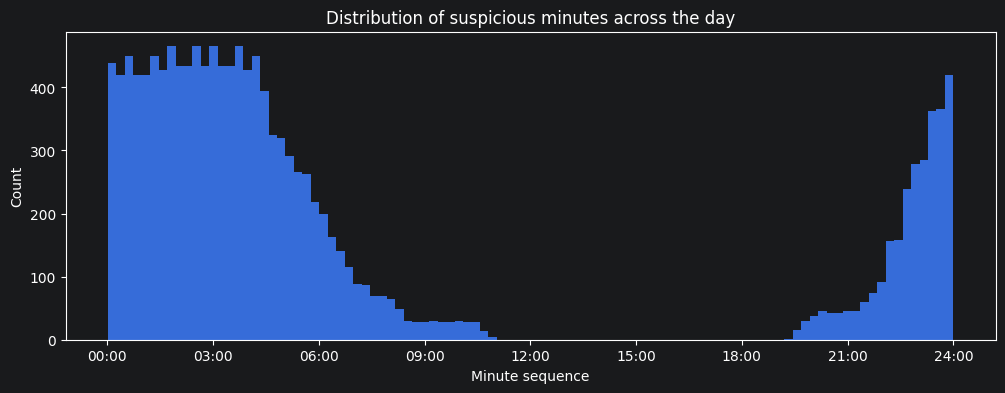

In [74]:
# Explore suspicious minutes distribution across the day

suspicious_minutes = (
    minute_metrics_06[
        minute_metrics_06["is_suspicious"] == True
    ]["minute_sequence"]
)

plt.figure(figsize=(12, 4))
plt.hist(suspicious_minutes, bins=100)
plt.xlabel("Minute sequence")
plt.ylabel("Count")
plt.title("Distribution of suspicious minutes across the day")
plt.xticks(
    ticks=[0, 180, 360, 540, 720, 900, 1080, 1260, 1440],
    labels=["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"],
)
plt.show()

In [75]:
# count of affected participants

suspicious_participants = minute_metrics_06[minute_metrics_06["is_suspicious"] == True]["ID"].nunique()
total_participants = minute_metrics_06["ID"].nunique()

print(f"Participants with at least one suspicious minute: "
      f"{suspicious_participants} of {total_participants} "
      f"({100 * suspicious_participants / total_participants:.1f}%)")

Participants with at least one suspicious minute: 25 of 2011 (1.2%)


In [76]:
# Drop suspicious minutes from the minute-level dataset to avoid skewing the harmonic regression

suspicious_ids = minute_metrics_06[minute_metrics_06["is_suspicious"] == True]["ID"].unique()
minute_metrics_06 = minute_metrics_06[~minute_metrics_06["ID"].isin(suspicious_ids)]

print(f"Removed {len(suspicious_ids)} participants with suspicious flags.")
print(f"Remaining participants: {minute_metrics_06['ID'].nunique():,}")

Removed 25 participants with suspicious flags.
Remaining participants: 1,986


### 1.2 Explore non_wear minutes distribution across the day and remove fully non-wear days

In [77]:
# Identify fully non-wear days
fully_non_wear_days = (
    minute_metrics_06
    .groupby(["ID", "study_day"])
    .apply(lambda day: (day["is_non_wear"] == True).all())
)

fully_non_wear_days = fully_non_wear_days[fully_non_wear_days]
print(f"Participant-days where entire day is non-wear: {len(fully_non_wear_days)}")
print(f"Participants affected: {fully_non_wear_days.index.get_level_values('ID').nunique()}")


Participant-days where entire day is non-wear: 193
Participants affected: 113


In [78]:
# Drop fully non wear days from the minute-level dataset to avoid skewing the harmonic regression
fully_non_wear_days = fully_non_wear_days[fully_non_wear_days]

minute_metrics_06 = minute_metrics_06[
    ~minute_metrics_06.set_index(["ID", "study_day"]).index.isin(fully_non_wear_days.index)
].reset_index(drop=True)

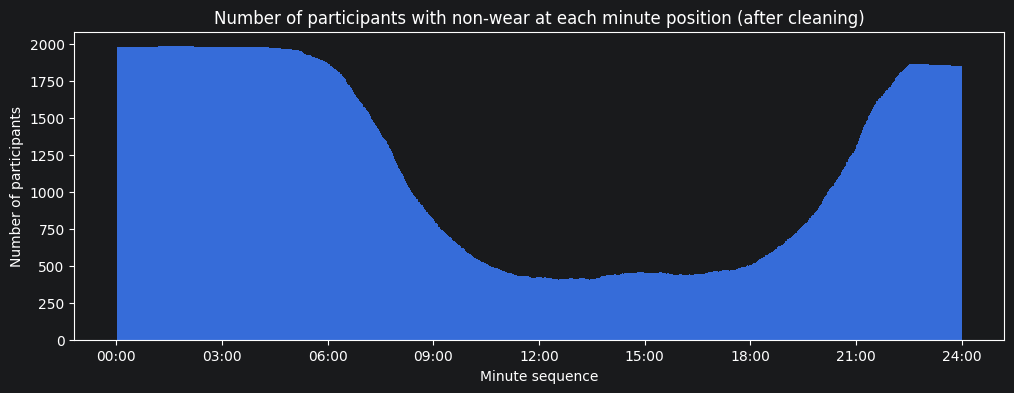

In [79]:
# non wear distribution plot after cleaning
non_wear_per_minute = (
    minute_metrics_06[minute_metrics_06["is_non_wear"] == True]
    .groupby("minute_sequence")["ID"]
    .nunique()
)

plt.figure(figsize=(12, 4))
plt.bar(non_wear_per_minute.index, non_wear_per_minute.values, width=1)
plt.xlabel("Minute sequence")
plt.ylabel("Number of participants")
plt.title("Number of participants with non-wear at each minute position (after cleaning)")
plt.xticks(
    ticks=[0, 180, 360, 540, 720, 900, 1080, 1260, 1440],
    labels=["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"],
)
plt.show()

In [80]:
# compair daily_metrics and minute_metrics ID's
comparison_result = compare_dataframe_ids(
    first_dataframe=daily_metrics_06,
    second_dataframe=minute_metrics_06,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 1976
Only in first: 25
Only in second: 10


### 1.3 Remove days with implausible wear time
Drop days with less than 10 hours of wear and 24 hours of wear time to ensure stable harmonic regression fits

remeber to justify the 10h lower bound and the 24h exclusion

In [81]:
wear_time_per_day = (
    minute_metrics_06
    .groupby(["ID", "study_day"])["is_non_wear"]
    .apply(lambda x: (x == False).sum() / 60)
    .reset_index()
    .rename(columns={"is_non_wear": "wear_hours"})
)

invalid_days = wear_time_per_day[
    (wear_time_per_day["wear_hours"] == 24) |
    (wear_time_per_day["wear_hours"] < 10)
][["ID", "study_day"]]

minute_metrics_06 = minute_metrics_06[
    ~minute_metrics_06.set_index(["ID", "study_day"]).index.isin(
        invalid_days.set_index(["ID", "study_day"]).index
    )
].reset_index(drop=True)

print(f"Dropped {len(invalid_days):,} days.")
print(f"Remaining participants: {minute_metrics_06['ID'].nunique():,}")

Dropped 865 days.
Remaining participants: 1,979


In [82]:
# compair daily_metrics and minute_metrics ID's
comparison_result = compare_dataframe_ids(
    first_dataframe=daily_metrics_06,
    second_dataframe=minute_metrics_06,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 1976
Only in first: 25
Only in second: 3


### 1.4 Remove participants with fewer than 4 valid days

remember to justify why a 4-day minimum

In [83]:
days_per_participant = (
    minute_metrics_06
    .groupby("ID")["study_day"]
    .nunique()
)

valid_participants = days_per_participant[days_per_participant >= 4].index

participants_before = minute_metrics_06["ID"].nunique()
minute_metrics_06 = minute_metrics_06[minute_metrics_06["ID"].isin(valid_participants)].reset_index(drop=True)
participants_after = minute_metrics_06["ID"].nunique()

print(f"Dropped {participants_before - participants_after:,} participants with fewer than 4 valid days.")
print(f"Remaining participants: {participants_after:,}")

Dropped 75 participants with fewer than 4 valid days.
Remaining participants: 1,904


### Compare IDs between summary metric and minute metric datasets to check for any discrepancies after cleaning

In [84]:
# compair daily_metrics and minute_metrics ID's
comparison_result = compare_dataframe_ids(
    first_dataframe=daily_metrics_06,
    second_dataframe=minute_metrics_06,
    id_column="ID",
)
print(f"Shared IDs: {len(comparison_result['in_both'])}")
print(f"Only in first: {len(comparison_result['only_in_first'])}")
print(f"Only in second: {len(comparison_result['only_in_second'])}")

Shared IDs: 1904
Only in first: 97
Only in second: 0


### Synchronise valid IDs across all dataframes after minute level cleaning

In [85]:
valid_ids_after_cleaning = set(minute_metrics_06["ID"].unique())

daily_metrics_06 = daily_metrics_06[
    daily_metrics_06["ID"].isin(valid_ids_after_cleaning)
].reset_index(drop=True)

# summary_metrics_06 uses ID as index at this point in the pipeline
summary_metrics_06 = summary_metrics_06[
    summary_metrics_06["ID"].isin(valid_ids_after_cleaning)
].reset_index(drop=True)

print(
    f"Participants after synchronisation:\n"
    f"  minute_metrics_06 : {minute_metrics_06['ID'].nunique():,}\n"
    f"  daily_metrics_06  : {daily_metrics_06['ID'].nunique():,}\n"
    f"  summary_metrics_06: {len(summary_metrics_06):,}"
)

Participants after synchronisation:
  minute_metrics_06 : 1,904
  daily_metrics_06  : 1,904
  summary_metrics_06: 1,845


## Fit harmonic regression model to each participant's minute-level data and extract activity profile features

five features per participant.
Three from harmonic regression (MESOR, amplitude, acrophase) describing
the *shape* of the average daily rhythm. Two nonparametric indices
(IV, IS) describing within-day fragmentation and between-day consistency,
which the harmonic fit cannot capture by construction.

### 2.1 Compute the mean daily activity curve

In [86]:
# gropupby ID, minute_sequence

mean_daily_curve = (
    minute_metrics_06
    .groupby(["ID", "minute_sequence"])["counts"]
    .mean()
    .reset_index()
    .rename(columns={"counts": "mean_counts"})
)

print(f"Mean daily curve computed for {mean_daily_curve['ID'].nunique():,} participants.")
print(mean_daily_curve.head())

Mean daily curve computed for 1,904 participants.
        ID  minute_sequence  mean_counts
0  9000099                1          0.0
1  9000099                2          0.0
2  9000099                3          0.0
3  9000099                4          0.0
4  9000099                5          0.0


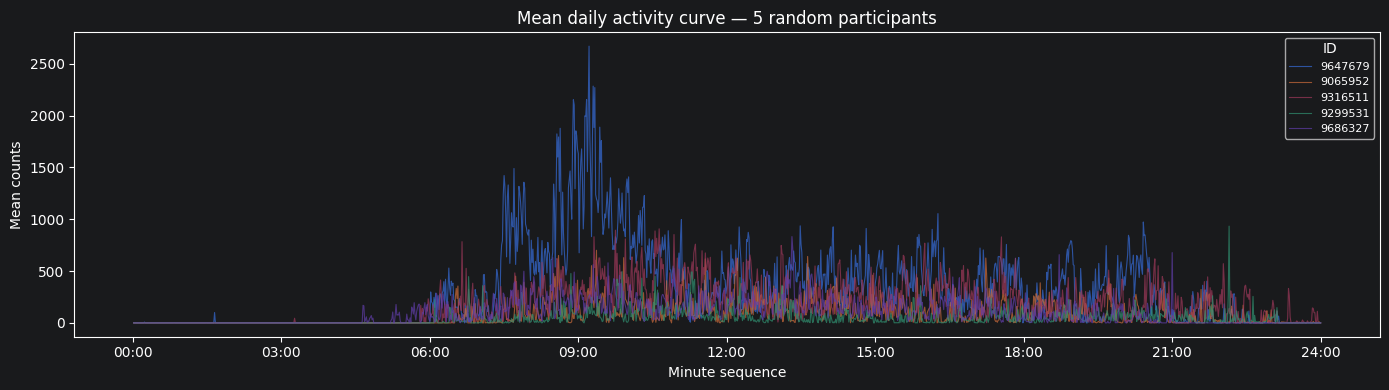

In [87]:
# Plot mean daily curve for a few random participants to verify the shape (sanity check)

sample_ids = mean_daily_curve["ID"].drop_duplicates().sample(5, random_state=42)

fig, ax = plt.subplots(figsize=(14, 4))

for participant_id in sample_ids:
    participant_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]
    ax.plot(
        participant_curve["minute_sequence"],
        participant_curve["mean_counts"],
        alpha=0.7,
        linewidth=0.8,
        label=str(participant_id),
    )

ax.set_xlabel("Minute sequence")
ax.set_ylabel("Mean counts")
ax.set_title("Mean daily activity curve — 5 random participants")
ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
ax.legend(title="ID", fontsize=8)
plt.tight_layout()
plt.show()

### 2.2 Harmonic regression with single participant demonstration

intercept (MESOR) plus two harmonic
pairs at periods of 24h and 12h, fitted with ordinary least squares.
Note that acrophase is read from argmax of the fitted curve rather
than from arctan2 of the coefficients to avoid sign-convention bugs.

In [88]:
# manual fit for single participant

participant_id = 9647679

single_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]

minutes = single_curve["minute_sequence"].to_numpy(dtype=float)
counts = single_curve["mean_counts"].to_numpy(dtype=float)

# Build design matrix: intercept + 2 harmonic pairs
period = 1440
design_matrix = np.column_stack([
    np.ones(len(minutes)),                                    # MESOR
    np.cos(2 * np.pi * 1 * minutes / period),                # harmonic 1 cosine
    np.sin(2 * np.pi * 1 * minutes / period),                # harmonic 1 sine
    np.cos(2 * np.pi * 2 * minutes / period),                # harmonic 2 cosine
    np.sin(2 * np.pi * 2 * minutes / period),                # harmonic 2 sine
])

coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)

mesor = coefficients[0]
amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
# Read acrophase directly from the peak of the fitted curve
# rather than computing from arctan2 to avoid sign convention issues
fitted_counts = design_matrix @ coefficients
peak_minute = minutes[np.argmax(fitted_counts)]
acrophase_hours = peak_minute / 60

print(f"MESOR: {mesor:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Acrophase: {acrophase_hours:.2f} hours ({int(peak_minute // 60):02d}:{int(peak_minute % 60):02d})")

MESOR: 318.84
Amplitude: 325.96
Acrophase: 9.63 hours (09:38)


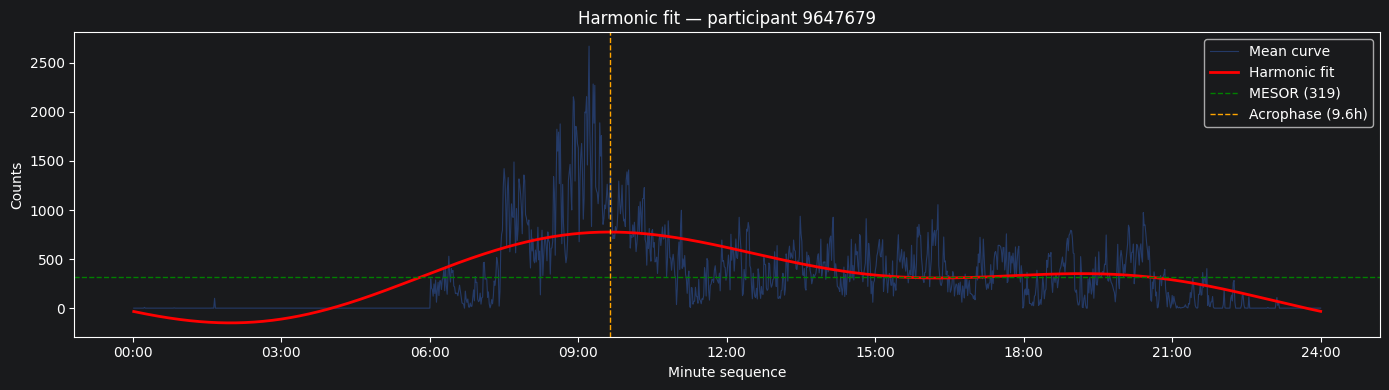

In [89]:
# plot showing curve, fit, MESOR line, acrophase line

fitted_counts = design_matrix @ coefficients

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(minutes, counts, alpha=0.4, linewidth=0.8, label="Mean curve")
ax.plot(minutes, fitted_counts, linewidth=2, color="red", label="Harmonic fit")
ax.axhline(y=mesor, color="green", linestyle="--", linewidth=1, label=f"MESOR ({mesor:.0f})")
ax.axvline(x=acrophase_hours * 60, color="orange", linestyle="--", linewidth=1, label=f"Acrophase ({acrophase_hours:.1f}h)")
ax.set_xlabel("Minute sequence")
ax.set_ylabel("Counts")
ax.set_title(f"Harmonic fit — participant {participant_id}")
ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
ax.legend()
plt.tight_layout()
plt.show()


### 2.3 Apply harmonic regression to all participants

In [90]:
# fit_harmonic_model function

def fit_harmonic_model(
        mean_daily_curve: pd.DataFrame,
        column_id: str,
        column_minute_sequence: str,
        column_mean_counts: str,
        period: int = 1440,
        number_of_harmonics: int = 2,
) -> pd.DataFrame:

    # Fit a harmonic regression model to each participant's mean daily curve and extract MESOR, amplitude, and acrophase.

    records = []

    for participant_id, participant_curve in mean_daily_curve.groupby(column_id):
        minutes = participant_curve[column_minute_sequence].to_numpy(dtype=float)
        counts = participant_curve[column_mean_counts].to_numpy(dtype=float)

        # Build design matrix
        design_matrix = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix.append(np.cos(2 * np.pi * harmonic_index * minutes / period))
            design_matrix.append(np.sin(2 * np.pi * harmonic_index * minutes / period))
        design_matrix = np.column_stack(design_matrix)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)

        fitted_counts = design_matrix @ coefficients
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hour = peak_minute /60

        records.append({
            column_id: participant_id,
            "mesor":mesor,
            "amplitude":amplitude,
            "acrophase":acrophase_hour,
        })

    return pd.DataFrame(records).set_index(column_id)

harmonic_features = fit_harmonic_model(
    mean_daily_curve = mean_daily_curve,
    column_id = "ID",
    column_minute_sequence = "minute_sequence",
    column_mean_counts = "mean_counts",
)

print(f"Harmonic features extracted for {len(harmonic_features)} participants:")
print(harmonic_features.describe())


Harmonic features extracted for 1904 participants:
             mesor    amplitude    acrophase
count  1904.000000  1904.000000  1904.000000
mean    150.681658   157.116953    12.415257
std      76.328299    85.812653     2.922713
min       7.812153     6.294997     3.066667
25%      96.382118    96.712521    10.450000
50%     135.957738   138.868878    11.966667
75%     191.938542   198.559906    14.250000
max     751.080060   711.080432    23.866667


### 2.4 Explore distribution of acrophase values across participants

describe what an extreme acrophase means (needs to be done) — peak before 6am
    or after 8pm is unusual and worth visual inspection. Document the
    decision: keep

In [91]:
# find participants with acrophase < 6 or > 20

print(harmonic_features[harmonic_features["acrophase"] < 6])
print(harmonic_features[harmonic_features["acrophase"] > 20])

              mesor   amplitude  acrophase
ID                                        
9318808  397.091171  493.446784   3.066667
9353017  296.695536  230.105650   5.033333
9540125  213.689683  159.091218   5.183333
9547559  189.666270  133.837106   5.733333
9608765  146.336706  122.280557   5.950000
9617608   83.298016   78.848006   5.033333
9618669  142.020635  152.269939   4.016667
9840817  392.195023  384.289488   4.416667
9850328  187.250992  148.203624   3.750000
              mesor   amplitude  acrophase
ID                                        
9011661  290.622338  266.999324  20.983333
9068197  245.167063  176.132539  20.166667
9093126   53.990774   40.700721  20.433333
9120358  335.321429   75.670989  23.666667
9281591  254.819213  258.206824  20.816667
9369690  195.975000  141.580622  23.866667
9835291  207.147222  187.285765  20.816667


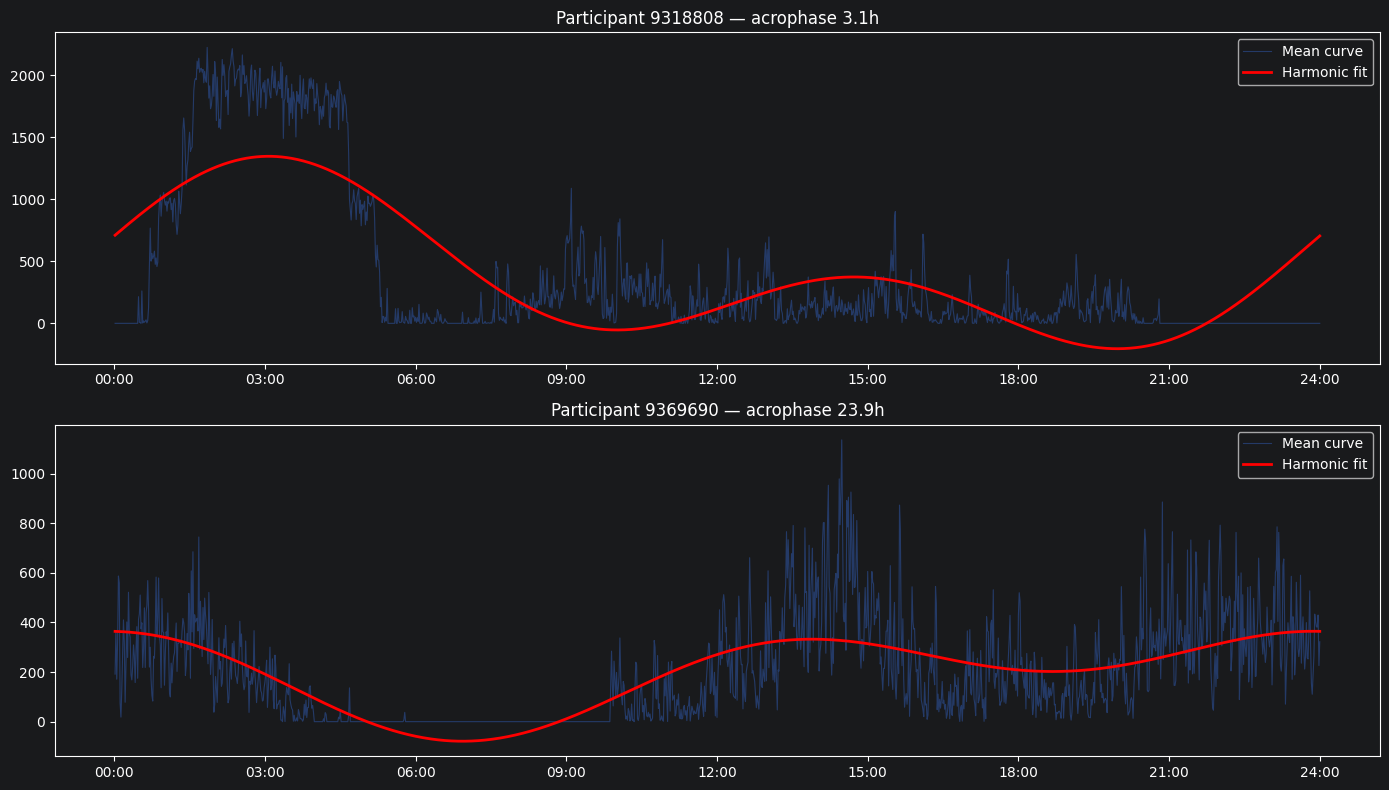

In [92]:
# Plot two outlier examples

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 8))

for ax, participant_id in zip(axes, [9318808, 9369690]):
    participant_curve = mean_daily_curve[mean_daily_curve["ID"] == participant_id]
    minutes = participant_curve["minute_sequence"].to_numpy(dtype=float)
    counts = participant_curve["mean_counts"].to_numpy(dtype=float)

    design_matrix = np.column_stack([
        np.ones(len(minutes)),
        np.cos(2 * np.pi * 1 * minutes / 1440),
        np.sin(2 * np.pi * 1 * minutes / 1440),
        np.cos(2 * np.pi * 2 * minutes / 1440),
        np.sin(2 * np.pi * 2 * minutes / 1440),
    ])
    coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
    fitted_counts = design_matrix @ coefficients

    ax.plot(minutes, counts, alpha=0.4, linewidth=0.8, label="Mean curve")
    ax.plot(minutes, fitted_counts, linewidth=2, color="red", label="Harmonic fit")
    ax.set_title(f"Participant {participant_id} — acrophase {harmonic_features.loc[participant_id, 'acrophase']:.1f}h")
    ax.set_xticks([0, 180, 360, 540, 720, 900, 1080, 1260, 1440])
    ax.set_xticklabels(["00:00", "03:00", "06:00", "09:00", "12:00", "15:00", "18:00", "21:00", "24:00"])
    ax.legend()

plt.tight_layout()
plt.show()

### 2.5 Intradaily Variability (IV) and Interdaily Stability (IS)

Harmonic regression describes the *shape* of the daily activity rhythm (when does
the person peak, how active are they on average). IV and IS describe two complementary
dimensions that harmonic parameters cannot capture:

IV: Within-day fragmentation — how much does the person's activity fluctuate up and down across the day?
    - High IV = lots of short bursts of activity interspersed with rest (frequent stop-and-go pattern)
    - Low IV = more consolidated activity and rest periods (smooth, sustained activity pattern)

IS: Day-to-day consistency — how similar is the person's activity pattern across different days?
    - High IS = very regular routine, similar activity levels at the same times each day
    - Low IS = irregular routine, varying activity levels and timing across days

Technical note
IV and IS are computed from the **raw minute-level data across all valid days**,
not from the mean daily curve. This is intentional, both indices specifically
quantify variability over time, which the mean curve averages away by design.

#### IV single participant demonstration

In [93]:
participant_id = 9647679

participant_data = (
    minute_metrics_06[minute_metrics_06["ID"] == participant_id]
    .sort_values(["study_day", "minute_sequence"])
)

counts = participant_data["counts"].to_numpy(dtype=float)

# IV: ratio of mean squared first-order differences to overall variance
# n * sum of squared differences between consecutive minutes
# divided by (n-1) * overall variance
number_of_minutes = len(counts)
overall_mean = np.mean(counts)
overall_variance = np.sum((counts - overall_mean) ** 2)
squared_differences = np.sum(np.diff(counts) ** 2)

iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

print(f"IV for participant {participant_id}: {iv:.4f}")

IV for participant 9647679: 0.4002


#### 2.5.2 IS single participant demonstration

In [94]:
# IS: ratio of variance of the mean 24h profile to overall variance
# Reshape counts into a matrix of days x minutes
number_of_complete_days = len(counts) // 1440
trimmed_counts = counts[:number_of_complete_days * 1440]
reshaped = trimmed_counts.reshape(number_of_complete_days, 1440)

# Mean activity at each of the 1440 minute positions across all days
mean_24h_profile = np.mean(reshaped, axis=0)
overall_mean = np.mean(trimmed_counts)

profile_variance = np.sum((mean_24h_profile - overall_mean) ** 2)
overall_variance = np.sum((trimmed_counts - overall_mean) ** 2)

is_index = (number_of_complete_days * profile_variance) / overall_variance

print(f"IS for participant {participant_id}: {is_index:.4f}")

IS for participant 9647679: 0.2374


#### 2.5.3 Apply IV and IS to all participants

In [95]:
# compute_iv_and_is function
def compute_iv_and_is(
    minute_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_sequence: str,
    column_counts: str,
    minutes_per_day: int = 1440,
) -> pd.DataFrame:
    """
    Compute intradaily variability (IV) and interdaily stability (IS)
    for each participant from the raw minute-level activity data.

    IV and IS are computed from the raw multi-day signal rather than
    the mean daily curve because both indices specifically quantify
    variability over time, which the mean curve averages away.

    :param minute_dataframe: Cleaned minute-level DataFrame.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_sequence: Minute sequence column.
    :param column_counts: Activity counts column.
    :param minutes_per_day: Number of minutes per day (1440).
    :return: DataFrame indexed by participant ID with columns
        [intradaily_variability, interdaily_stability].
    """
    records = []

    for participant_id, participant_data in minute_dataframe.groupby(column_id):
        participant_data = participant_data.sort_values(
            by=[column_study_day, column_minute_sequence]
        )
         # Fill residual NaN values with 0 before computing variance-based indices
        counts = participant_data[column_counts].to_numpy(dtype=float)
        counts = np.nan_to_num(counts, nan=0.0)

        number_of_minutes = len(counts)
        overall_mean = np.mean(counts)
        overall_variance = np.sum((counts - overall_mean) ** 2)

        # IV
        squared_differences = np.sum(np.diff(counts) ** 2)
        iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

        # IS
        number_of_complete_days = number_of_minutes // minutes_per_day
        trimmed_counts = counts[:number_of_complete_days * minutes_per_day]
        reshaped = trimmed_counts.reshape(number_of_complete_days, minutes_per_day)
        mean_24h_profile = np.mean(reshaped, axis=0)
        overall_mean_trimmed = np.mean(trimmed_counts)
        profile_variance = np.sum((mean_24h_profile - overall_mean_trimmed) ** 2)
        overall_variance_trimmed = np.sum((trimmed_counts - overall_mean_trimmed) ** 2)
        is_index = (number_of_complete_days * profile_variance) / overall_variance_trimmed

        records.append({
            column_id: participant_id,
            "intradaily_variability": iv,
            "interdaily_stability": is_index,
        })

    return pd.DataFrame(records).set_index(column_id)

# apply function
rhythm_indices = compute_iv_and_is(
    minute_dataframe=minute_metrics_06,
    column_id="ID",
    column_study_day="study_day",
    column_minute_sequence="minute_sequence",
    column_counts="counts",
)

# describe IV an IS
print(f"IV and IS computed for {len(rhythm_indices)} participants.")
print(rhythm_indices.describe())

IV and IS computed for 1904 participants.
       intradaily_variability  interdaily_stability
count             1904.000000           1904.000000
mean                 0.647035              0.231534
std                  0.242211              0.050712
min                  0.049364              0.134682
25%                  0.476619              0.198096
50%                  0.666698              0.221602
75%                  0.822725              0.254544
max                  1.635432              0.616200


## 3. Merge features into the summary metrics_06

In [96]:
summary_metrics_06 = summary_metrics_06.set_index("ID")

summary_metrics_06 = summary_metrics_06.join(harmonic_features, how="left")
summary_metrics_06 = summary_metrics_06.join(rhythm_indices, how="left")

print(f"Summary data shape after merging: {summary_metrics_06.shape}")
print(f"Missing values for new features:")
print(summary_metrics_06[["mesor", "amplitude", "acrophase",
                           "intradaily_variability", "interdaily_stability"]].isna().sum())

Summary data shape after merging: (1845, 119)
Missing values for new features:
mesor                     0
amplitude                 0
acrophase                 0
intradaily_variability    0
interdaily_stability      0
dtype: int64


## 4. Descriptive exploration of activity profile features

### 4.1 Defining grouping variables
KL grade, employment, weekend, weekday --> needs later more explanation

#### 4.1.1 KL grade severity groups

In [97]:
# Group KL grades into three clinically meaningful severity groups
kl_grade_mapping = {0: "KL 0-1", 1: "KL 0-1", 2: "KL 2-3", 3: "KL 2-3", 4: "KL 4"}

summary_metrics_06["kl_grade_group"] = summary_metrics_06["kl_grade"].map(kl_grade_mapping)
daily_metrics_06["kl_grade_group"] = daily_metrics_06["kl_grade"].map(kl_grade_mapping)

print("Summary metrics:")
print(summary_metrics_06["kl_grade_group"].value_counts(dropna=False))
print("\nDaily metrics:")
print(daily_metrics_06["kl_grade_group"].value_counts(dropna=False))

Summary metrics:
kl_grade_group
KL 2-3    940
KL 0-1    740
KL 4      164
NaN         1
Name: count, dtype: int64

Daily metrics:
kl_grade_group
KL 2-3    6244
KL 0-1    4991
KL 4      1074
NaN        393
Name: count, dtype: int64


#### 4.1.2. Employmet status

Group employment into working vs not working
Categories 1 (paid) and 2 (unpaid family) are considered working
Categories 3 (not working due to health) and 4 (not working other) are not working

In [98]:
employment_mapping = {
    1.0: "working",
    2.0: "working",
    3.0: "not working",
    4.0: "not working",
}
summary_metrics_06["employment_group"] = summary_metrics_06["V06CEMPLOY"].map(employment_mapping)
print(summary_metrics_06["employment_group"].value_counts())

employment_group
working        984
not working    813
Name: count, dtype: int64


In [99]:
# merge employment status to daily metrics
daily_metrics_06 = daily_metrics_06.merge(
    summary_metrics_06[["employment_group"]].reset_index(),
    on="ID",
    how="left",
)
print(daily_metrics_06["employment_group"].value_counts())

employment_group
working        6592
not working    5401
Name: count, dtype: int64


#### 4.1.3 Weekday vs weekend day type

In [100]:
# define weekend days and weekday days

weekend_days = ["Saturday", "Sunday"]
daily_metrics_06["day_type"] = daily_metrics_06["week_day"].apply(
    lambda day: "weekend" if day in weekend_days else "weekday"
)

### 4.2. Activity profile features by KL grade

In [101]:
features_of_interest = ["mesor", "amplitude", "acrophase",
                         "intradaily_variability", "interdaily_stability"]

kl_grade_descriptives = (
    summary_metrics_06
    .groupby("kl_grade_group")[features_of_interest]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_grade_descriptives)

                  mesor                  amplitude                  acrophase  \
                   mean     std   median      mean     std   median      mean   
kl_grade_group                                                                  
KL 0-1          160.794  80.830  142.324   166.008  88.297  146.129    12.495   
KL 2-3          145.545  72.288  132.773   152.593  83.681  134.594    12.362   
KL 4            133.831  74.929  118.005   141.852  85.572  121.762    12.313   

                              intradaily_variability                \
                  std  median                   mean    std median   
kl_grade_group                                                       
KL 0-1          3.030  12.000                  0.618  0.242  0.632   
KL 2-3          2.912  11.950                  0.659  0.244  0.676   
KL 4            2.506  11.942                  0.707  0.228  0.737   

               interdaily_stability                
                               mean    s

### 4.3 Activity profile features by employment status

activity profile features by day type -> not possible with one curve per participant, try with day to day curve --> maybe add later to explore the differences

In [102]:
employment_status_descriptives = (
    summary_metrics_06
    .groupby("employment_group")[features_of_interest]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(employment_status_descriptives)

                    mesor                  amplitude                   \
                     mean     std   median      mean     std   median   
employment_group                                                        
not working       125.912  69.634  110.904   140.015  81.922  123.350   
working           171.291  76.374  157.412   171.045  86.835  155.031   

                 acrophase                intradaily_variability         \
                      mean    std  median                   mean    std   
employment_group                                                          
not working         11.979  2.427  11.783                  0.685  0.255   
working             12.754  3.242  12.125                  0.615  0.228   

                        interdaily_stability                
                 median                 mean    std median  
employment_group                                            
not working       0.706                0.233  0.051  0.222  
working       

## 5. Per-day harmonic decomposition

description why change to per day harmonic

### 5.1 Single-day demonstration for on participant

In [103]:
participant_id = 9000099
study_day = 414

single_day = (
    minute_metrics_06[
        (minute_metrics_06["ID"] == participant_id) &
        (minute_metrics_06["study_day"] == study_day)
    ]
    .sort_values("minute_sequence")
)

minutes = single_day["minute_sequence"].to_numpy(dtype=float)
counts = single_day["counts"].to_numpy(dtype=float)
counts = np.nan_to_num(counts, nan=0.0)

# Harmonic model
period = 1440
design_matrix = np.column_stack([
    np.ones(len(minutes)),
    np.cos(2 * np.pi * 1 * minutes / period),
    np.sin(2 * np.pi * 1 * minutes / period),
    np.cos(2 * np.pi * 2 * minutes / period),
    np.sin(2 * np.pi * 2 * minutes / period),
])

coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
fitted_counts = design_matrix @ coefficients

mesor = coefficients[0]
amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
peak_minute = minutes[np.argmax(fitted_counts)]
acrophase_hours = peak_minute / 60

# IV
number_of_minutes = len(counts)
overall_mean = np.mean(counts)
overall_variance = np.sum((counts - overall_mean) ** 2)
squared_differences = np.sum(np.diff(counts) ** 2)
iv = (number_of_minutes * squared_differences) / ((number_of_minutes - 1) * overall_variance)

print(f"MESOR: {mesor:.2f}")
print(f"Amplitude: {amplitude:.2f}")
print(f"Acrophase: {acrophase_hours:.2f}h")
print(f"IV: {iv:.4f}")

MESOR: 336.77
Amplitude: 505.76
Acrophase: 9.78h
IV: 0.1152


### 5.2 Per-day function across all participant-days

same harmonic specification as section 2, but fitted to each participant-day independently rather than to the mean curve

In [104]:
# harmonic regression features and iv function

def extract_daily_harmonic_and_iv(
    minute_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_sequence: str,
    column_counts: str,
    period: int = 1440,
    number_of_harmonics: int = 2,
) -> pd.DataFrame:
    """
    Fit harmonic regression and compute intradaily variability (IV)
    for each participant-day.

    Unlike the participant-level harmonic features which are fitted to the
    mean daily curve, these features are computed per individual day to enable
    weekday vs weekend and employment status comparisons.

    IS is excluded here as it requires multiple days by definition and
    remains a participant-level feature only.

    :param minute_dataframe: Cleaned minute-level DataFrame.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_sequence: Minute sequence column.
    :param column_counts: Activity counts column.
    :param period: Period in minutes (1440 for daily rhythm).
    :param number_of_harmonics: Number of harmonic pairs to fit.
    :return: DataFrame with one row per participant-day containing
        mesor, amplitude, acrophase, and intradaily_variability.
    """
    records = []

    for (participant_id, study_day), day_data in minute_dataframe.groupby(
        [column_id, column_study_day]
    ):
        day_data = day_data.sort_values(column_minute_sequence)
        minutes = day_data[column_minute_sequence].to_numpy(dtype=float)
        counts = np.nan_to_num(
            day_data[column_counts].to_numpy(dtype=float), nan=0.0
        )

        # Build design matrix
        design_matrix = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix.append(np.cos(2 * np.pi * harmonic_index * minutes / period))
            design_matrix.append(np.sin(2 * np.pi * harmonic_index * minutes / period))
        design_matrix = np.column_stack(design_matrix)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
        fitted_counts = design_matrix @ coefficients

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1]**2 + coefficients[2]**2)
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hours = peak_minute / 60

        # IV
        number_of_minutes = len(counts)
        overall_mean = np.mean(counts)
        overall_variance = np.sum((counts - overall_mean) ** 2)
        squared_differences = np.sum(np.diff(counts) ** 2)
        iv = (
            (number_of_minutes * squared_differences)
            / ((number_of_minutes - 1) * overall_variance)
            if overall_variance > 0 else np.nan
        )

        records.append({
            column_id: participant_id,
            column_study_day: study_day,
            "mesor_daily": mesor,
            "amplitude_daily": amplitude,
            "acrophase_daily": acrophase_hours,
            "intradaily_variability_daily": iv,
        })

    return pd.DataFrame(records)


# apply function
daily_harmonic_features = extract_daily_harmonic_and_iv(
    minute_dataframe=minute_metrics_06,
    column_id="ID",
    column_study_day="study_day",
    column_minute_sequence="minute_sequence",
    column_counts="counts",
)

print(f"Daily harmonic features extracted for {len(daily_harmonic_features)} participant-days.")
print(daily_harmonic_features.describe())

Daily harmonic features extracted for 12924 participant-days.
                 ID     study_day   mesor_daily  amplitude_daily  \
count  1.292400e+04  12924.000000  12924.000000     12924.000000   
mean   9.507311e+06    302.947539    150.998557       171.025812   
std    2.817533e+05    140.361144     95.169333       126.800386   
min    9.000099e+06     28.000000      0.441667         0.241332   
25%    9.266787e+06    202.000000     84.599653        85.604035   
50%    9.516409e+06    294.500000    127.825694       136.245777   
75%    9.742640e+06    411.000000    193.670312       218.276329   
max    9.999878e+06    707.000000    935.501389      1304.852671   

       acrophase_daily  intradaily_variability_daily  
count     12924.000000                  12924.000000  
mean         12.659724                      0.735601  
std           3.450992                      0.294700  
min           0.250000                      0.027858  
25%          10.116667                      0.5356

#### 5.2.1. Merge features to daily_metrics_06 and save as CSV

In [105]:
# merge daily harmonic features to daily_metrics_06

daily_metrics_06 = daily_metrics_06.merge(
    daily_harmonic_features[
        [
            "ID",
            "study_day",
            "mesor_daily",
            "amplitude_daily",
            "acrophase_daily",
            "intradaily_variability_daily",
        ]
    ],
    on=["ID", "study_day"],
    how="left",
)

daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

#### 5.2.2 Aggregate main curve for weekends and weekdays

In [106]:
# function to extract main curve for weekends and weekdays
def extract_mean_curve_harmonic_by_day_type(
    minute_dataframe: pd.DataFrame,
    daily_metadata_dataframe: pd.DataFrame,
    column_id: str,
    column_study_day: str,
    column_minute_of_day: str,
    column_counts: str,
    column_day_type: str,
    period: int = 1440,
    number_of_harmonics: int = 2,
) -> pd.DataFrame:
    """
    Fit harmonic regression to the participant-level mean daily activity
    curve, separately for weekday and weekend days.

    For each participant and each day type, minute-level activity counts
    are averaged across days at every minute-of-day, producing a single
    24-hour mean curve. A harmonic regression is then fitted to that mean
    curve to derive mesor, amplitude, and acrophase.

    :param minute_dataframe: Cleaned minute-level DataFrame containing
        activity counts.
    :param daily_metadata_dataframe: Daily-level DataFrame containing the
        day type label (weekday / weekend) for each participant-day.
    :param column_id: Participant identifier column.
    :param column_study_day: Study day column.
    :param column_minute_of_day: Minute-of-day column (0 to 1439).
    :param column_counts: Activity counts column.
    :param column_day_type: Column labelling each day as weekday or weekend.
    :param period: Period in minutes (1440 for a daily rhythm).
    :param number_of_harmonics: Number of harmonic pairs to fit.
    :return: DataFrame with one row per participant containing mesor,
        amplitude, and acrophase for both weekday and weekend mean curves.
    """
    minute_with_day_type = minute_dataframe.merge(
        daily_metadata_dataframe[[column_id, column_study_day, column_day_type]].drop_duplicates(),
        on=[column_id, column_study_day],
        how="left",
    )

    records = []

    for (participant_id, day_type), participant_day_type_data in minute_with_day_type.groupby(
        [column_id, column_day_type]
    ):
        mean_curve = (
            participant_day_type_data
            .groupby(column_minute_of_day)[column_counts]
            .mean()
            .sort_index()
        )

        minutes = mean_curve.index.to_numpy(dtype=float)
        counts = np.nan_to_num(mean_curve.to_numpy(dtype=float), nan=0.0)

        design_matrix_columns = [np.ones(len(minutes))]
        for harmonic_index in range(1, number_of_harmonics + 1):
            design_matrix_columns.append(
                np.cos(2 * np.pi * harmonic_index * minutes / period)
            )
            design_matrix_columns.append(
                np.sin(2 * np.pi * harmonic_index * minutes / period)
            )
        design_matrix = np.column_stack(design_matrix_columns)

        coefficients, _, _, _ = lstsq(design_matrix, counts, rcond=None)
        fitted_counts = design_matrix @ coefficients

        mesor = coefficients[0]
        amplitude = np.sqrt(coefficients[1] ** 2 + coefficients[2] ** 2)
        peak_minute = minutes[np.argmax(fitted_counts)]
        acrophase_hours = peak_minute / 60

        records.append(
            {
                column_id: participant_id,
                column_day_type: day_type,
                "mesor_mean_curve": mesor,
                "amplitude_mean_curve": amplitude,
                "acrophase_mean_curve": acrophase_hours,
            }
        )

    long_format = pd.DataFrame(records)

    wide_format = long_format.pivot(
        index=column_id,
        columns=column_day_type,
        values=["mesor_mean_curve", "amplitude_mean_curve", "acrophase_mean_curve"],
    )
    wide_format.columns = [
        f"{feature_name}_{day_type_label}"
        for feature_name, day_type_label in wide_format.columns
    ]
    wide_format = wide_format.reset_index()

    return wide_format

In [107]:
# merge curves into summery metrics
mean_curve_features_by_day_type = extract_mean_curve_harmonic_by_day_type(
    minute_dataframe=minute_metrics_06,
    daily_metadata_dataframe=daily_metrics_06,
    column_id="ID",
    column_study_day="study_day",
    column_minute_of_day="minute_sequence",   # adjust if your column is named differently
    column_counts="counts",
    column_day_type="day_type",
)

summary_metrics_06 = summary_metrics_06.merge(
    mean_curve_features_by_day_type,
    on="ID",
    how="left",
)

#### 5.2.4 Filter IV by daytype

In [108]:
iv_by_daytype = (
    daily_metrics_06.assign(
        day_type=lambda dataframe : dataframe["week_day"].
        isin(weekend_days).
        map({True: "weekend", False: "weekday"})
    )
    .groupby(["ID", "day_type"]) ["intradaily_variability_daily"]
    .mean().unstack("day_type")
   .rename(columns={
        "weekday": "iv_weekday",
        "weekend": "iv_weekend",
    })
             )

iv_by_daytype["iv_contrast"] = (
    iv_by_daytype["iv_weekday"] - iv_by_daytype["iv_weekend"]
)

# Merge into the main summary feature dataframe
summary_metrics_06 = summary_metrics_06.merge(
    iv_by_daytype.reset_index(),
    on="ID",
    how="left",
)

In [109]:
# save to csv
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)

### 5.3 Descriptive comparison

#### 5.3.1 By day type (weekday vs weekend)

In [110]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

day_type_descriptives = (
    daily_metrics_06
    .groupby("day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(day_type_descriptives)

         mesor_daily                   amplitude_daily                    \
                mean      std   median            mean      std   median   
day_type                                                                   
weekday      153.649   93.130  131.659         169.989  121.254  137.160   
weekend      149.034  100.011  122.811         178.602  140.404  138.946   

         acrophase_daily                intradaily_variability_daily         \
                    mean    std  median                         mean    std   
day_type                                                                      
weekday           12.640  3.555  12.083                        0.734  0.292   
weekend           12.702  3.145  12.317                        0.730  0.296   

                 
         median  
day_type         
weekday   0.772  
weekend   0.759  


 #### 5.3.2 By employment status

In [111]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

employment_type_descriptives = (
    daily_metrics_06
    .groupby("employment_group")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(employment_type_descriptives)

                 mesor_daily                  amplitude_daily           \
                        mean     std   median            mean      std   
employment_group                                                         
not working          127.834  84.577  107.360         151.362  114.157   
working              172.582  99.215  148.333         189.526  134.524   

                          acrophase_daily                 \
                   median            mean    std  median   
employment_group                                           
not working       121.039          12.379  3.116  11.883   
working           152.109          12.871  3.684  12.433   

                 intradaily_variability_daily                
                                         mean    std median  
employment_group                                             
not working                             0.769  0.303  0.808  
working                                 0.703  0.284  0.735  


#### 5.3.3 By KL grade

In [112]:
features_of_interest_daily = [
    "mesor_daily",
    "amplitude_daily",
    "acrophase_daily",
    "intradaily_variability_daily",
]

kl_grade_descriptives = (
    daily_metrics_06
    .groupby("kl_grade_group")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_grade_descriptives)

               mesor_daily                   amplitude_daily           \
                      mean      std   median            mean      std   
kl_grade_group                                                          
KL 0-1             162.081  101.856  136.699         183.116  135.115   
KL 2-3             147.624   90.364  126.234         167.118  122.141   
KL 4               133.863   87.009  108.121         152.420  114.745   

                        acrophase_daily                 \
                 median            mean    std  median   
kl_grade_group                                           
KL 0-1          145.763          12.726  3.516  12.317   
KL 2-3          135.287          12.626  3.446  12.125   
KL 4            118.552          12.529  3.125  11.950   

               intradaily_variability_daily                
                                       mean    std median  
kl_grade_group                                             
KL 0-1                          

#### 5.3.4 By KL grade × day type

In [113]:
daily_metrics_06["kl_day_type"] = (
    daily_metrics_06["kl_grade_group"]
    + " - "
    + daily_metrics_06["day_type"]
)

kl_day_type_descriptives = (
    daily_metrics_06
    .groupby("kl_day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_day_type_descriptives)

                 mesor_daily                   amplitude_daily           \
                        mean      std   median            mean      std   
kl_day_type                                                               
KL 0-1 - weekday     162.773   98.872  138.732         179.247  127.706   
KL 0-1 - weekend     160.281  109.258  132.665         193.188  152.314   
KL 2-3 - weekday     148.975   89.041  128.171         165.248  117.854   
KL 2-3 - weekend     144.164   93.604  119.856         171.909  132.408   
KL 4 - weekday       135.098   84.133  112.053         150.204  106.539   
KL 4 - weekend       130.570   94.328   97.756         158.334  134.230   

                          acrophase_daily                 \
                   median            mean    std  median   
kl_day_type                                                
KL 0-1 - weekday  143.285          12.718  3.651  12.267   
KL 0-1 - weekend  151.195          12.745  3.141  12.392   
KL 2-3 - weekday  135.40

#### 5.3.5 By KL grade × employment

In [114]:
daily_metrics_06["kl_employment"] = (
    daily_metrics_06["kl_grade_group"]
    + " - "
    + daily_metrics_06["employment_group"]
)

kl_employment_descriptives = (
    daily_metrics_06
    .groupby("kl_employment")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_employment_descriptives)

                     mesor_daily                   amplitude_daily           \
                            mean      std   median            mean      std   
kl_employment                                                                 
KL 0-1 - not working     135.913   94.120  112.110         160.758  122.875   
KL 0-1 - working         181.103  102.613  154.896         198.959  138.991   
KL 2-3 - not working     125.267   79.317  107.292         148.786  110.321   
KL 2-3 - working         167.151   95.429  144.200         183.225  130.608   
KL 4 - not working       111.994   68.392   95.292         130.937   95.028   
KL 4 - working           158.952  100.375  138.914         176.472  130.611   

                              acrophase_daily                 \
                       median            mean    std  median   
kl_employment                                                  
KL 0-1 - not working  126.319          12.298  3.086  11.867   
KL 0-1 - working      160.353   

#### 5.3.6 By KL grade × employment × day type

In [115]:
daily_metrics_06["kl_employment_day_type"] = (
    daily_metrics_06["kl_grade_group"]
    + " - "
    + daily_metrics_06["employment_group"]
    + " - "
    + daily_metrics_06["day_type"]
)

kl_employment_day_type_descriptives = (
    daily_metrics_06
    .groupby("kl_employment_day_type")[features_of_interest_daily]
    .agg(["mean", "std", "median"])
    .round(3)
)

print(kl_employment_day_type_descriptives)

                               mesor_daily                   amplitude_daily  \
                                      mean      std   median            mean   
kl_employment_day_type                                                         
KL 0-1 - not working - weekday     140.399   94.911  117.077         165.107   
KL 0-1 - not working - weekend     124.451   91.151   99.579         149.643   
KL 0-1 - working - weekday         178.879   97.982  153.735         188.988   
KL 0-1 - working - weekend         186.979  113.805  158.022         225.307   
KL 2-3 - not working - weekday     128.324   79.649  111.020         152.318   
KL 2-3 - not working - weekend     117.348   77.944   96.904         139.637   
KL 2-3 - working - weekday         167.046   93.478  145.383         176.465   
KL 2-3 - working - weekend         167.418  100.279  141.045         200.448   
KL 4 - not working - weekday       113.121   64.949   96.923         132.249   
KL 4 - not working - weekend       109.1

### 5.4 Non-paramatric group comparison (exploratory)

The Kruskal-Wallis test and Dunn post-hoc are applied here as an
exploratory descriptive tool to identify candidate group differences
in the per-day features.

**Important caveat.** These tests assume independent observations, which
is violated in the per-day table because each participant contributes
multiple days (typically 5–7). Within-participant correlation will
deflate the p-values, making them optimistically small. The results
below should therefore be read as a ranking of where group differences
are likely to exist, not as confirmatory inference.

The linear mixed models in section 5.7 address the dependence structure
explicitly by including participant ID as a random intercept, and serve
as the inferential anchor for any conclusions drawn about KL grade,
employment, or day type effects.

In [116]:
def run_kruskal_dunn(
    dataframe: pd.DataFrame,
    feature_columns: list[str],
    group_column: str,
) -> pd.DataFrame:
    """
    Run Kruskal-Wallis test and Dunn post-hoc for each feature across groups.

    Bonferroni correction is applied to the Dunn post-hoc p-values to
    account for multiple comparisons.

    :param dataframe: DataFrame containing features and group column.
    :param feature_columns: List of feature column names to test.
    :param group_column: Column name defining the groups.
    :return: DataFrame with Kruskal-Wallis statistic, p-value, and Dunn
        post-hoc p-values for each feature.
    """
    results = []

    for feature in feature_columns:
        subset = dataframe[[feature, group_column]].dropna()
        groups = [
            group_data[feature].values
            for _, group_data in subset.groupby(group_column)
        ]

        kruskal_statistic, kruskal_pvalue = kruskal(*groups)

        dunn_results = sp.posthoc_dunn(
            subset,
            val_col=feature,
            group_col=group_column,
            p_adjust="bonferroni",
        )

        results.append({
            "feature": feature,
            "kruskal_statistic": round(kruskal_statistic, 3),
            "kruskal_pvalue": round(kruskal_pvalue, 4),
            "dunn_pvalues": dunn_results,
        })

    return results


# Run for all three comparisons
kl_grade_tests = run_kruskal_dunn(
    dataframe=daily_metrics_06,
    feature_columns=features_of_interest_daily,
    group_column="kl_grade_group",
)

day_type_tests = run_kruskal_dunn(
    dataframe=daily_metrics_06,
    feature_columns=features_of_interest_daily,
    group_column="day_type",
)

employment_tests = run_kruskal_dunn(
    dataframe=daily_metrics_06,
    feature_columns=features_of_interest_daily,
    group_column="employment_group",
)

In [117]:
# Print KL grade results
print("KL grade comparisons:")
for result in kl_grade_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

print("\nDay type comparisons:")
for result in day_type_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

print("\nEmployment comparisons:")
for result in employment_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")

KL grade comparisons:

mesor_daily:
  Kruskal-Wallis: H=113.049, p=0.0
  Dunn post-hoc:
        KL 0-1  KL 2-3  KL 4
KL 0-1     1.0     0.0   0.0
KL 2-3     0.0     1.0   0.0
KL 4       0.0     0.0   1.0

amplitude_daily:
  Kruskal-Wallis: H=82.913, p=0.0
  Dunn post-hoc:
        KL 0-1  KL 2-3  KL 4
KL 0-1     1.0     0.0   0.0
KL 2-3     0.0     1.0   0.0
KL 4       0.0     0.0   1.0

acrophase_daily:
  Kruskal-Wallis: H=3.64, p=0.162
  Dunn post-hoc:
        KL 0-1  KL 2-3    KL 4
KL 0-1  1.0000   0.443  0.3068
KL 2-3  0.4430   1.000  1.0000
KL 4    0.3068   1.000  1.0000

intradaily_variability_daily:
  Kruskal-Wallis: H=47.602, p=0.0
  Dunn post-hoc:
        KL 0-1  KL 2-3  KL 4
KL 0-1  1.0000  0.0003   0.0
KL 2-3  0.0003  1.0000   0.0
KL 4    0.0000  0.0000   1.0

Day type comparisons:

mesor_daily:
  Kruskal-Wallis: H=29.041, p=0.0
  Dunn post-hoc:
         weekday  weekend
weekday      1.0      0.0
weekend      0.0      1.0

amplitude_daily:
  Kruskal-Wallis: H=0.231, p=0.6309


In [118]:
kl_employment_day_type_tests = run_kruskal_dunn(
    dataframe=daily_metrics_06,
    feature_columns=features_of_interest_daily,
    group_column="kl_employment_day_type",
)

for result in kl_employment_day_type_tests:
    print(f"\n{result['feature']}:")
    print(f"  Kruskal-Wallis: H={result['kruskal_statistic']}, p={result['kruskal_pvalue']}")
    print(f"  Dunn post-hoc:\n{result['dunn_pvalues'].round(4)}")


mesor_daily:
  Kruskal-Wallis: H=966.18, p=0.0
  Dunn post-hoc:
                                KL 0-1 - not working - weekday  \
KL 0-1 - not working - weekday                          1.0000   
KL 0-1 - not working - weekend                          0.0006   
KL 0-1 - working - weekday                              0.0000   
KL 0-1 - working - weekend                              0.0000   
KL 2-3 - not working - weekday                          0.0987   
KL 2-3 - not working - weekend                          0.0000   
KL 2-3 - working - weekday                              0.0000   
KL 2-3 - working - weekend                              0.0000   
KL 4 - not working - weekday                            0.0000   
KL 4 - not working - weekend                            0.0000   
KL 4 - working - weekday                                0.0026   
KL 4 - working - weekend                                1.0000   

                                KL 0-1 - not working - weekend  \
KL 0-1 - n

In [119]:
# summarise dunn results
def summarise_dunn_results(
    test_results: list[dict],
    significance_threshold: float = 0.05,
) -> pd.DataFrame:
    """
    Extract only significant pairwise comparisons from Dunn post-hoc results.

    :param test_results: Output from run_kruskal_dunn.
    :param significance_threshold: P-value threshold for significance.
    :return: Tidy DataFrame with one row per significant pairwise comparison.
    """
    rows = []
    for result in test_results:
        feature = result["feature"]
        kruskal_statistic = result["kruskal_statistic"]
        kruskal_pvalue = result["kruskal_pvalue"]
        dunn = result["dunn_pvalues"]

        groups = dunn.columns.tolist()
        for i, group_a in enumerate(groups):
            for group_b in groups[i + 1:]:
                pvalue = dunn.loc[group_a, group_b]
                if pvalue < significance_threshold:
                    rows.append({
                        "feature": feature,
                        "kruskal_H": kruskal_statistic,
                        "kruskal_p": kruskal_pvalue,
                        "group_a": group_a,
                        "group_b": group_b,
                        "dunn_p": round(pvalue, 4),
                    })

    return pd.DataFrame(rows)


combined_significant = summarise_dunn_results(
    test_results=kl_employment_day_type_tests,
    significance_threshold=0.05,
)

print(f"Total significant pairwise comparisons: {len(combined_significant)}")
print(combined_significant.to_string())


Total significant pairwise comparisons: 128
                          feature  kruskal_H  kruskal_p                         group_a                         group_b  dunn_p
0                     mesor_daily    966.180        0.0  KL 0-1 - not working - weekday  KL 0-1 - not working - weekend  0.0006
1                     mesor_daily    966.180        0.0  KL 0-1 - not working - weekday      KL 0-1 - working - weekday  0.0000
2                     mesor_daily    966.180        0.0  KL 0-1 - not working - weekday      KL 0-1 - working - weekend  0.0000
3                     mesor_daily    966.180        0.0  KL 0-1 - not working - weekday  KL 2-3 - not working - weekend  0.0000
4                     mesor_daily    966.180        0.0  KL 0-1 - not working - weekday      KL 2-3 - working - weekday  0.0000
5                     mesor_daily    966.180        0.0  KL 0-1 - not working - weekday      KL 2-3 - working - weekend  0.0000
6                     mesor_daily    966.180        0.0  KL 

### 5.5 Linear mixed models

the Kruskal-Wallis tests above treat each
    participant-day as an independent observation, which is incorrect
    because each participant contributes multiple days. The mixed model
    addresses this by including participant ID as a random intercept,
    so within-participant correlation is properly accounted for. Fixed
    effects: KL grade group, employment group, day type, and the
    KL × employment interaction

In [120]:
# define run_linear_mixed_model function
def run_linear_mixed_model(
    dataframe: pd.DataFrame,
    outcome: str,
    fixed_effects: str,
    group_column: str,
) -> None:
    """
    Fit a linear mixed model with participant as random effect.

    :param dataframe: DataFrame containing outcome, predictors and group.
    :param outcome: Outcome column name.
    :param fixed_effects: Formula string for fixed effects.
    :param group_column: Column defining the random effect grouping (participant ID).
    """
    subset = dataframe[[outcome, "kl_grade_group", "employment_group",
                         "day_type", group_column]].dropna()

    # Encode categorical variables
    subset["kl_grade_group"] = pd.Categorical(
        subset["kl_grade_group"],
        categories=["KL 0-1", "KL 2-3", "KL 4"],
        ordered=True,
    )

    formula = f"{outcome} ~ {fixed_effects}"
    model = smf.mixedlm(
        formula=formula,
        data=subset,
        groups=subset[group_column],
    )
    fitted_model = model.fit(method="bfgs")
    print(f"\n{'='*60}")
    print(f"Outcome: {outcome}")
    print(f"{'='*60}")
    print(fitted_model.summary())


for outcome in features_of_interest_daily:
    run_linear_mixed_model(
        dataframe=daily_metrics_06,
        outcome=outcome,
        fixed_effects="kl_grade_group + employment_group + day_type + kl_grade_group:employment_group",
        group_column="ID",
    )


Outcome: mesor_daily
                               Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               mesor_daily
No. Observations:               11954                 Method:                           REML       
No. Groups:                     1796                  Scale:                            3797.1090  
Min. group size:                1                     Log-Likelihood:                   -68208.5389
Max. group size:                7                     Converged:                        Yes        
Mean group size:                6.7                                                                
---------------------------------------------------------------------------------------------------
                                                      Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
---------------------------------------------------------------------------------------------------
Intercept

### 5.6 Visualisations

In [121]:
# Plot configuration for per-day feature visualisations

# Ordered KL severity groups for consistent plotting across all charts
kl_order = ["KL 0-1", "KL 2-3", "KL 4"]

# Human-readable axis labels for each per-day feature
feature_labels = {
    "mesor_daily": "MESOR (rhythm-adjusted mean activity)",
    "amplitude_daily": "Amplitude (peak-to-trough range)",
    "acrophase_daily": "Acrophase (clock hour of peak)",
    "intradaily_variability_daily": "Intradaily variability (IV)",
}

# Y-axis limits per feature, set to the 1st and 99th percentiles to clip
# extreme outliers and keep the violin shapes visually comparable across groups.
y_limits = {
    feature: (
        daily_metrics_06[feature].quantile(0.01),
        daily_metrics_06[feature].quantile(0.99),
    )
    for feature in feature_labels
}

#### 5.6.1 Violin plots — feature distributions by KL × employment

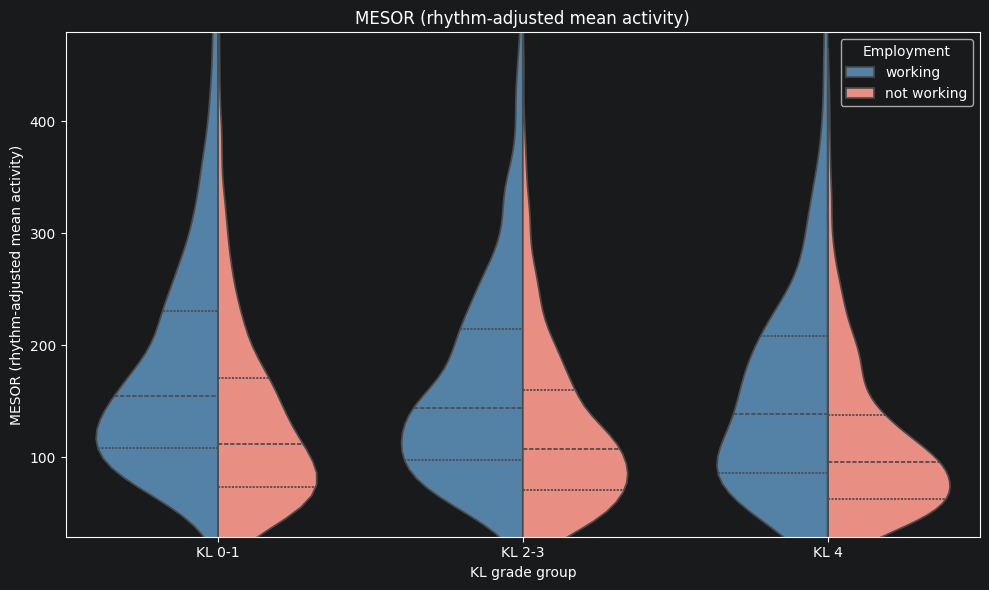

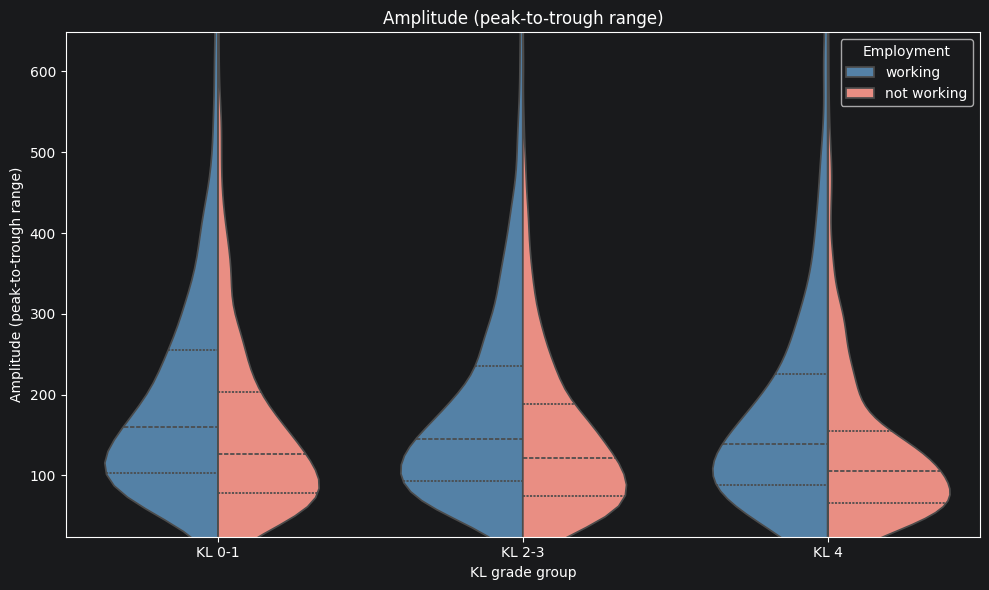

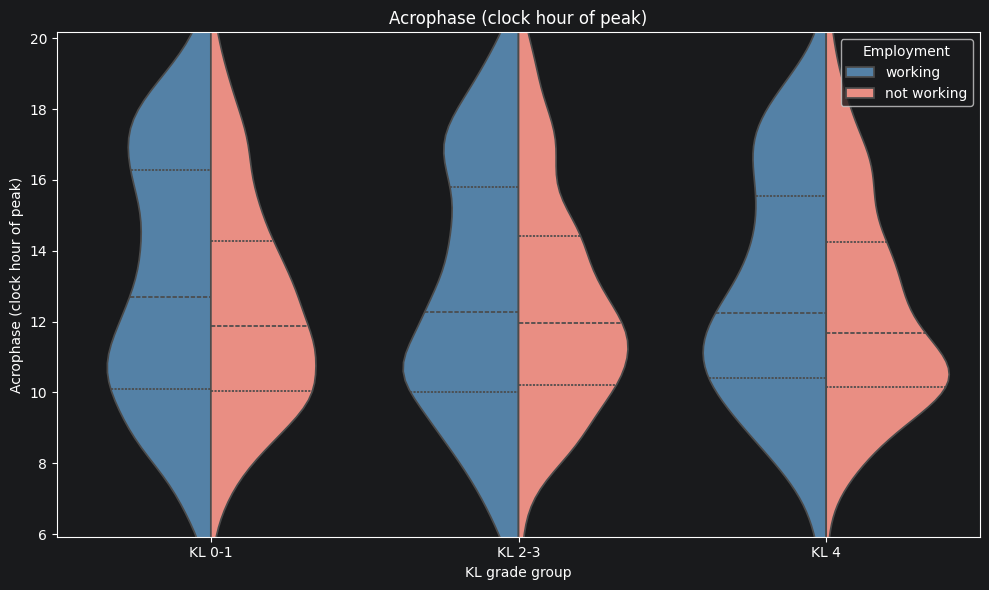

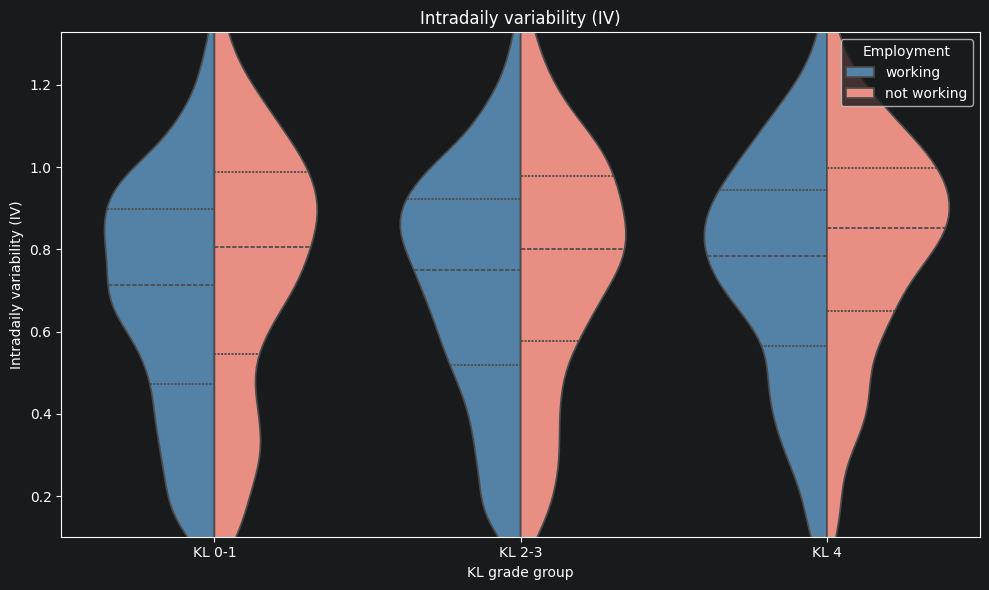

In [122]:
for feature in features_of_interest_daily:
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.violinplot(
        data=daily_metrics_06.dropna(subset=[feature]),
        x="kl_grade_group",
        y=feature,
        hue="employment_group",
        order=kl_order,
        hue_order=["working", "not working"],
        split=True,
        inner="quartile",
        palette={"working": "steelblue", "not working": "salmon"},
        ax=ax,
    )
    ax.set_xlabel("KL grade group")
    ax.set_ylabel(feature_labels[feature])
    ax.set_title(feature_labels[feature])
    ax.set_ylim(y_limits[feature])
    ax.legend(title="Employment", loc="upper right")

    plt.tight_layout()
    plt.show()

#### 5.6.2 Interaction plots — KL trajectories split by context

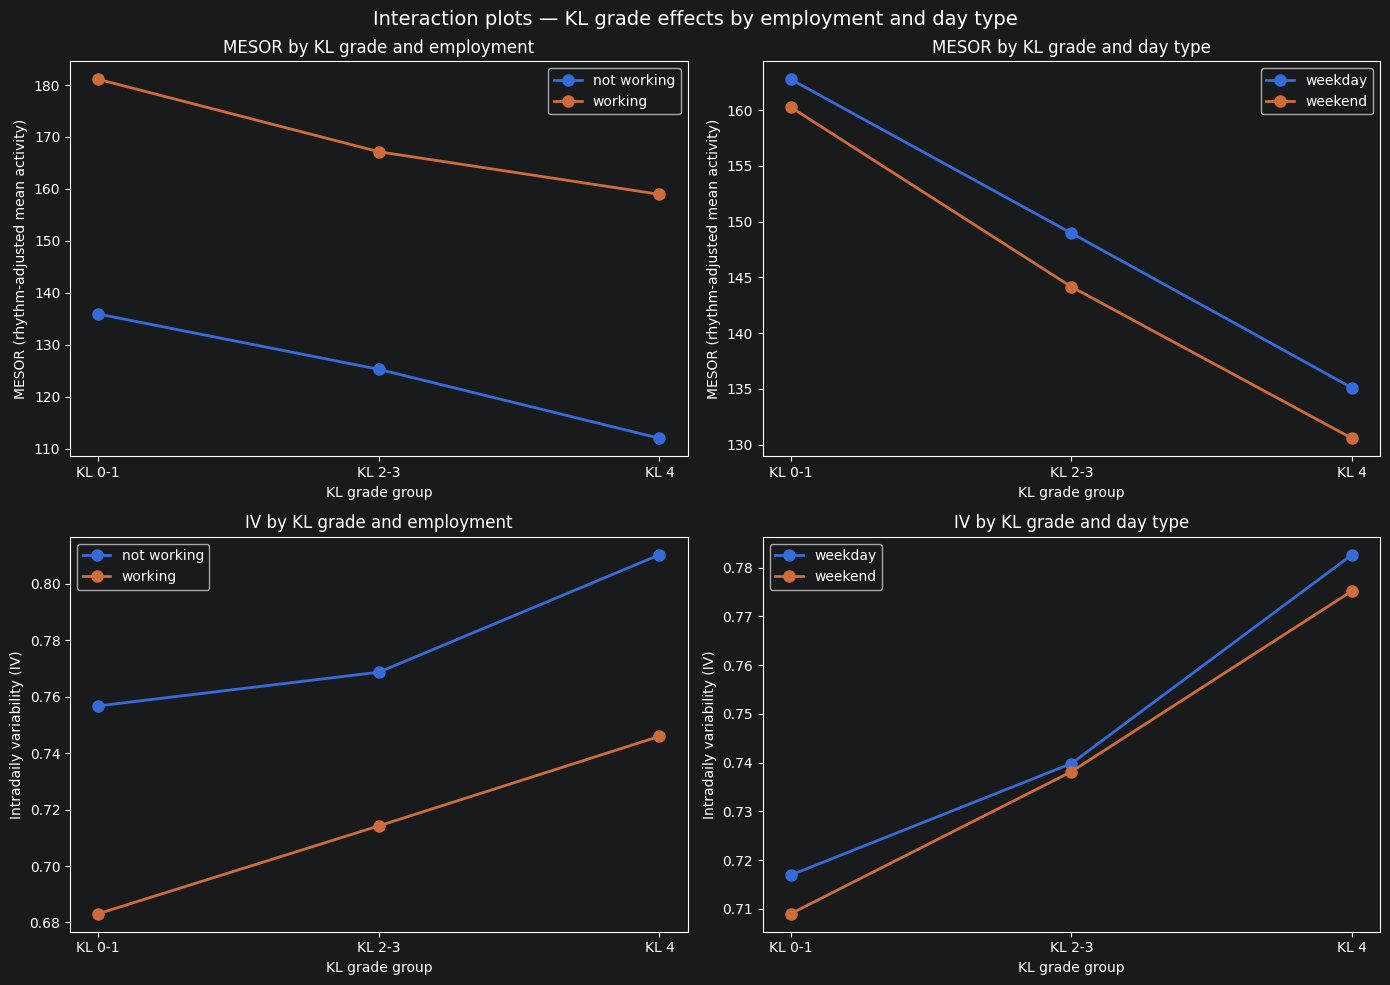

In [123]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

plot_specifications = [
    {"feature": "mesor_daily", "group": "employment_group", "title": "MESOR by KL grade and employment"},
    {"feature": "mesor_daily", "group": "day_type", "title": "MESOR by KL grade and day type"},
    {"feature": "intradaily_variability_daily", "group": "employment_group", "title": "IV by KL grade and employment"},
    {"feature": "intradaily_variability_daily", "group": "day_type", "title": "IV by KL grade and day type"},
]

for axis, specification in zip(axes.flatten(), plot_specifications):
    plot_data = (
        daily_metrics_06
        .groupby(["kl_grade_group", specification["group"]])[specification["feature"]]
        .mean()
        .reset_index()
    )

    for group_value, group_data in plot_data.groupby(specification["group"]):
        group_data = group_data.sort_values("kl_grade_group")
        axis.plot(
            group_data["kl_grade_group"],
            group_data[specification["feature"]],
            marker="o",
            linewidth=2,
            markersize=8,
            label=group_value,
        )

    axis.set_xlabel("KL grade group")
    axis.set_ylabel(feature_labels[specification["feature"]])
    axis.set_title(specification["title"])
    axis.legend()

plt.suptitle("Interaction plots — KL grade effects by employment and day type", fontsize=14)
plt.tight_layout()
plt.show()

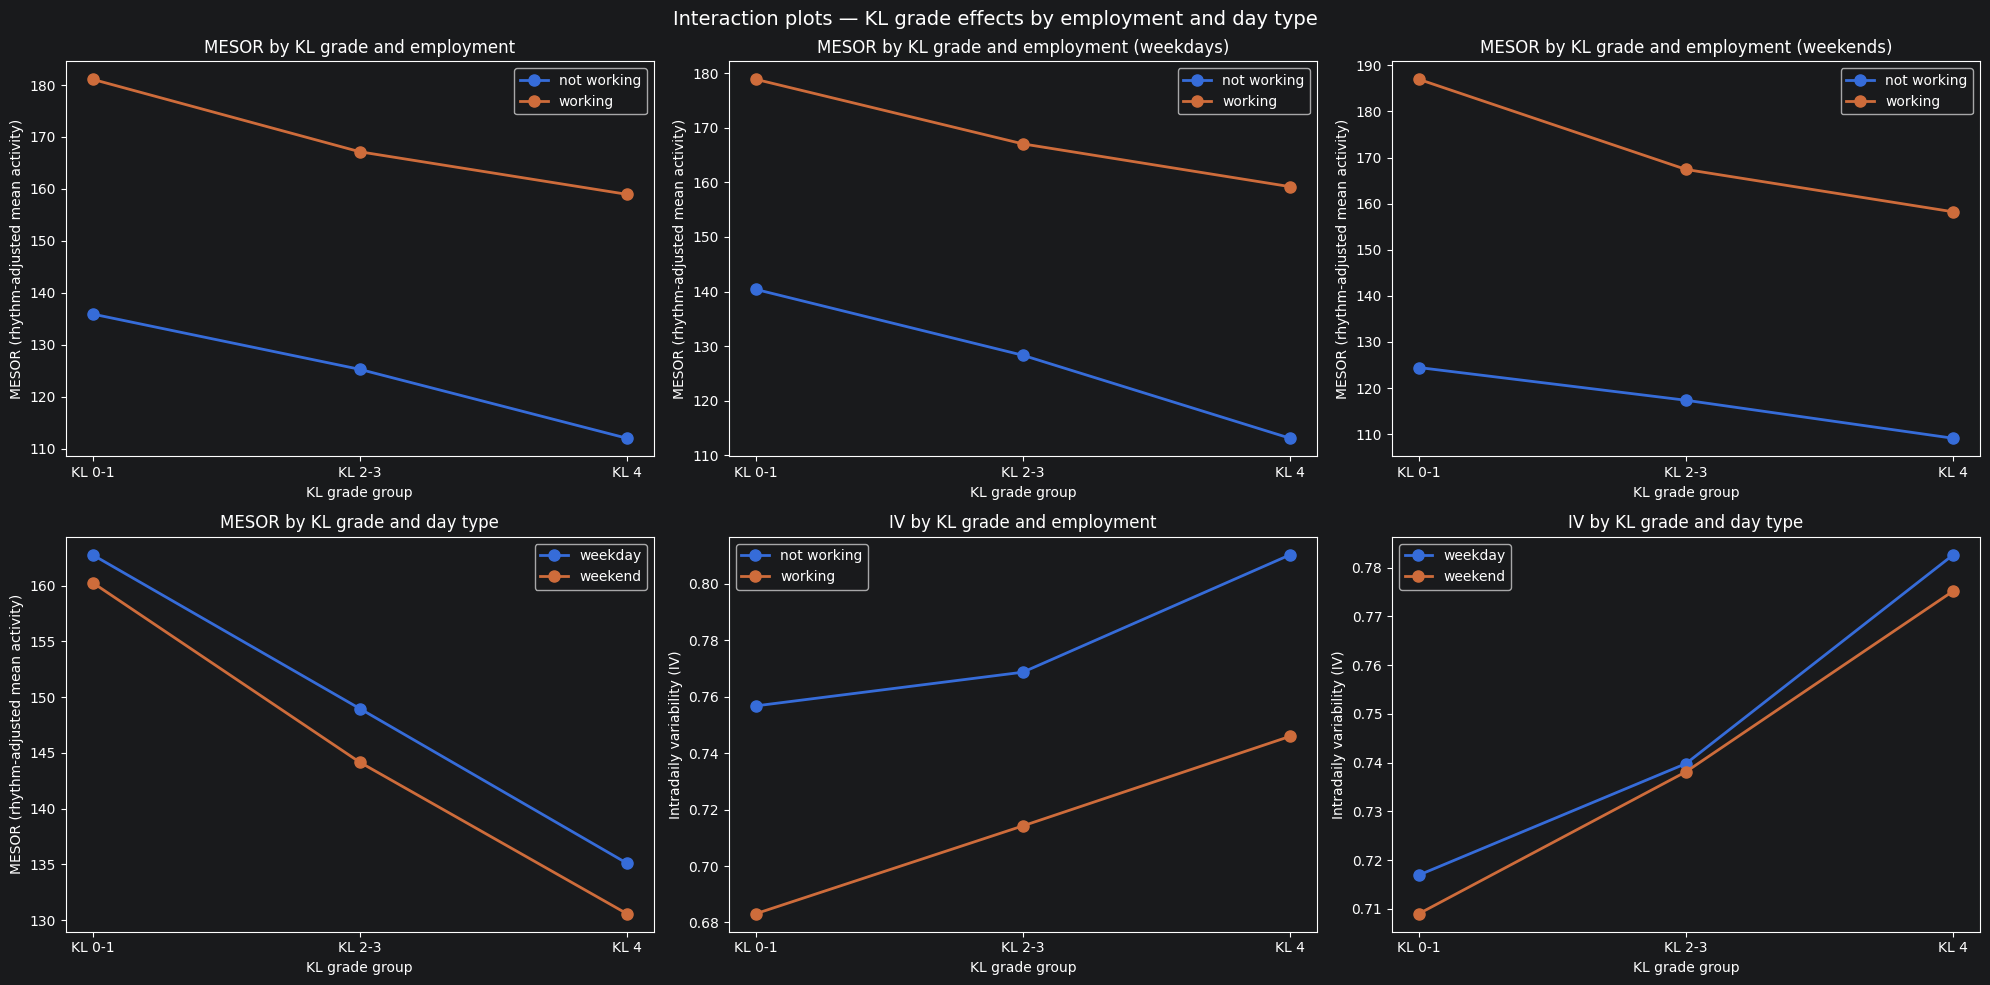

In [124]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))

plot_specifications = [
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment",
        "filter": None,
    },
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment (weekdays)",
        "filter": {"column": "day_type", "value": "weekday"},
    },
    {
        "feature": "mesor_daily",
        "group": "employment_group",
        "title": "MESOR by KL grade and employment (weekends)",
        "filter": {"column": "day_type", "value": "weekend"},
    },
    {
        "feature": "mesor_daily",
        "group": "day_type",
        "title": "MESOR by KL grade and day type",
        "filter": None,
    },
    {
        "feature": "intradaily_variability_daily",
        "group": "employment_group",
        "title": "IV by KL grade and employment",
        "filter": None,
    },
    {
        "feature": "intradaily_variability_daily",
        "group": "day_type",
        "title": "IV by KL grade and day type",
        "filter": None,
    },
]

for axis, specification in zip(axes.flatten(), plot_specifications):
    data_subset = (
        daily_metrics_06[
            daily_metrics_06[specification["filter"]["column"]] == specification["filter"]["value"]
        ]
        if specification["filter"] is not None
        else daily_metrics_06
    )

    plot_data = (
        data_subset
        .groupby(["kl_grade_group", specification["group"]])[specification["feature"]]
        .mean()
        .reset_index()
    )

    for group_value, group_data in plot_data.groupby(specification["group"]):
        group_data = group_data.sort_values("kl_grade_group")
        axis.plot(
            group_data["kl_grade_group"],
            group_data[specification["feature"]],
            marker="o",
            linewidth=2,
            markersize=8,
            label=group_value,
        )

    axis.set_xlabel("KL grade group")
    axis.set_ylabel(feature_labels[specification["feature"]])
    axis.set_title(specification["title"])
    axis.legend()

plt.suptitle("Interaction plots — KL grade effects by employment and day type", fontsize=14)
plt.tight_layout()
plt.show()

#### 5.6.3 Radar chart — overall rhythm profile by KL grade

In [125]:
# Radar chart setup — aggregate per-day features by KL group and orient
# all axes so that "outer ring = healthier rhythm".

# Aggregate features per KL group (one mean per cell of a 3 x 4 table)
radar_data_for_chart = (
    daily_metrics_06
    .groupby("kl_grade_group")[list(feature_labels.keys())]
    .mean()
    .reindex(kl_order)
)

# Direction of "better" per feature.
# IV is inverted so that lower IV (less fragmentation) plots outward,
# matching the chart title's claim that higher = better.
# Acrophase is excluded because "later peak" is not directionally interpretable.
higher_is_better = {
    "mesor_daily": True,
    "amplitude_daily": True,
    "intradaily_variability_daily": False,
}

radar_data_for_chart = radar_data_for_chart[list(higher_is_better.keys())]

for feature, is_higher_better in higher_is_better.items():
    if not is_higher_better:
        radar_data_for_chart[feature] = -radar_data_for_chart[feature]

# Short axis labels for the corners of the polygon (must match column order)
categories = ["MESOR", "Amplitude", "IV (inverted)"]

# Angle for each axis around the circle, with a closing angle to wrap the polygon
number_of_features = len(categories)
angles = [
    n / number_of_features * 2 * np.pi
    for n in range(number_of_features)
]
angles += angles[:1]

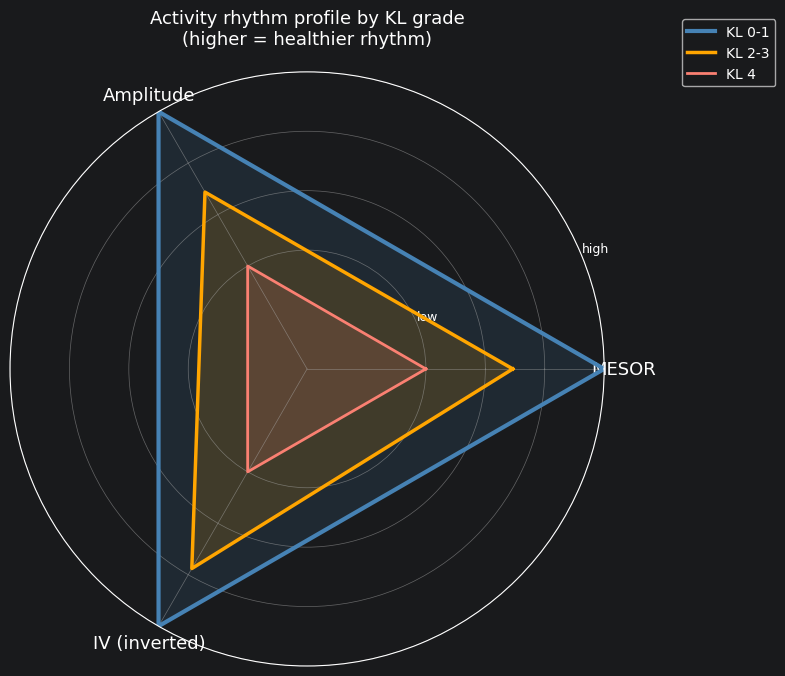

In [126]:
# Radar chart — activity rhythm profile by KL grade
# Each axis represents one feature, oriented so outer ring = healthier rhythm.
# Min-max scaled to a 0.4–1.0 band to amplify between-group differences
# while keeping all polygons visible inside the chart area.

radar_data_for_chart_scaled = (
    (radar_data_for_chart - radar_data_for_chart.min())
    / (radar_data_for_chart.max() - radar_data_for_chart.min())
) * 0.6 + 0.4

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})

kl_group_colors = {
    "KL 0-1": "steelblue",
    "KL 2-3": "orange",
    "KL 4": "salmon",
}
kl_group_linewidths = {
    "KL 0-1": 3,
    "KL 2-3": 2.5,
    "KL 4": 2,
}

for kl_group in kl_order:
    values = radar_data_for_chart_scaled.loc[kl_group].tolist()
    values += values[:1]  # close the polygon

    ax.plot(
        angles,
        values,
        linewidth=kl_group_linewidths[kl_group],
        label=kl_group,
        color=kl_group_colors[kl_group],
    )
    ax.fill(
        angles,
        values,
        alpha=0.15,
        color=kl_group_colors[kl_group],
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=13)
ax.set_ylim(0, 1)
ax.set_yticks([0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["low", "", "", "high"], fontsize=9)
ax.set_title(
    "Activity rhythm profile by KL grade\n(higher = healthier rhythm)",
    fontsize=13,
    pad=20,
)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

# Prediction modeling

## Check predicotrs for redundancy

In [127]:
HARMONIC_PREDICTOR_COLUMNS = [
'mesor', 'amplitude', 'acrophase', 'intradaily_variability', 'interdaily_stability', 'mesor_mean_curve_weekday', 'mesor_mean_curve_weekend', 'amplitude_mean_curve_weekday', 'amplitude_mean_curve_weekend', 'acrophase_mean_curve_weekday', 'acrophase_mean_curve_weekend', 'iv_weekday', 'iv_weekend', 'iv_contrast']

In [128]:
print(summary_metrics_06[HARMONIC_PREDICTOR_COLUMNS])

           mesor   amplitude  acrophase  intradaily_variability  \
0     337.930278  449.962633   9.716667                0.108076   
1     196.920486  170.440801  16.566667                0.651857   
2      72.021962   86.515124  11.583333                0.527742   
3     209.247817  312.323592   9.750000                0.566317   
4     265.163294  246.325508   8.283333                0.376340   
...          ...         ...        ...                     ...   
1840   99.786012   97.408775   8.900000                0.484587   
1841  324.538889  383.160403   8.583333                0.353270   
1842  183.124306  201.348345   8.233333                0.422178   
1843   64.626389   61.331548   9.650000                1.018331   
1844  100.929365  110.385742  12.616667                0.994877   

      interdaily_stability  mesor_mean_curve_weekday  \
0                 0.529832                336.812731   
1                 0.206699                178.901389   
2                 0.141771 

### Run Spearman correlation

In [129]:
correlation_matrix_predictors = compute_spearman_correlation_matrix(
    dataframe= summary_metrics_06,
    columns= HARMONIC_PREDICTOR_COLUMNS + predictor_columns
)

print(correlation_matrix_predictors)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix_predictors,
    redundancy_threshold=0.85,
)

                                      mesor  amplitude  acrophase  \
mesor                              1.000000   0.911888  -0.010771   
amplitude                          0.911888   1.000000   0.005994   
acrophase                         -0.010771   0.005994   1.000000   
intradaily_variability            -0.678387  -0.672112   0.056273   
interdaily_stability               0.373039   0.477409  -0.107726   
mesor_mean_curve_weekday           0.972670   0.891751  -0.022603   
mesor_mean_curve_weekend           0.876954   0.793628   0.024822   
amplitude_mean_curve_weekday       0.847958   0.947869  -0.021476   
amplitude_mean_curve_weekend       0.818251   0.826574   0.055442   
acrophase_mean_curve_weekday      -0.009734  -0.001611   0.800605   
acrophase_mean_curve_weekend       0.001835   0.004920   0.517357   
iv_weekday                        -0.674661  -0.653497   0.055662   
iv_weekend                        -0.621511  -0.607523   0.021199   
iv_contrast                       

In [130]:
FINAL_PREDICTOR_COLUMNS = [
    # ── Sleep / wear ──────────────────────────────────────────────────────────
    "wake_minute_mean",                # Mean wake time across valid days
    "wake_minute_sd",                  # Standard deviation of wake time
    "wear_duration_mean",              # Mean daily wear duration in minutes

    # ── Bout structure: sedentary ─────────────────────────────────────────────
    # mean_active_bout_count dropped — redundant with mean_sedentary_bout_count (ρ=1.00)
    # mean_light_bout_count dropped  — redundant with mean_sedentary_bout_count (ρ=0.94)
    "mean_sedentary_bout_count",
    "mean_sedentary_bout_mean_duration",
    "mean_sedentary_bout_max_duration",
    "mean_sedentary_bout_total_minutes",

    # ── Bout structure: light ─────────────────────────────────────────────────
    # mean_light_bout_count dropped         — redundant with mean_sedentary_bout_count (ρ=0.94)
    # mean_light_bout_mean_duration dropped — redundant with mean_active_bout_mean_duration (ρ=0.86)
    "mean_light_bout_max_duration",

    # ── Bout structure: MVPA ──────────────────────────────────────────────────
    # mean_mvpa_bout_max_duration dropped — redundant with mean_mvpa_bout_mean_duration (ρ=0.96)
    "mean_mvpa_bout_count",
    "mean_mvpa_bout_mean_duration",

    # ── Bout structure: active ────────────────────────────────────────────────
    # mean_active_bout_count dropped — redundant with mean_sedentary_bout_count (ρ=1.00)
    "mean_active_bout_mean_duration",
    "mean_active_bout_max_duration",
    "mean_active_bout_total_minutes",

    # ── Harmonic features: overall ────────────────────────────────────────────
    # mesor dropped     — redundant with day-type specific mesor columns (ρ=0.97/0.88)
    # amplitude dropped — redundant with day-type specific amplitude columns (ρ=0.95/0.89)
    # intradaily_variability dropped — redundant with iv_weekday (ρ=0.89)
    "acrophase",                       # Overall acrophase retained — not involved in any redundant pair
    "interdaily_stability",            # IS retained as overall only — day-split not meaningful

    # ── Harmonic features: day-type specific ──────────────────────────────────
    "mesor_mean_curve_weekday",        # Mean activity level on weekdays
    "mesor_mean_curve_weekend",        # Mean activity level on weekends
    "amplitude_mean_curve_weekday",    # Peak-to-mean swing on weekdays
    "amplitude_mean_curve_weekend",    # Peak-to-mean swing on weekends
    "acrophase_mean_curve_weekday",    # Timing of activity peak on weekdays
    "acrophase_mean_curve_weekend",    # Timing of activity peak on weekends

    # ── IV: day-type specific ─────────────────────────────────────────────────
    "iv_weekday",                      # Within-day fragmentation on weekdays
    "iv_weekend",                      # Within-day fragmentation on weekends
    "iv_contrast",                     # iv_weekday - iv_weekend: work-related fragmentation burden
]

In [131]:
correlation_matrix_predictors = compute_spearman_correlation_matrix(
    dataframe=summary_metrics_06,
    columns=FINAL_PREDICTOR_COLUMNS
)

redundant_pairs = print_redundant_pairs(
    correlation_matrix=correlation_matrix_predictors,
    redundancy_threshold=0.85,
)


Redundant pairs (|ρ| ≥ 0.85)
Variable A           Variable B                ρ
--------------------------------------------------
mesor_mean_curve_weekend amplitude_mean_curve_weekend  0.937
mesor_mean_curve_weekday amplitude_mean_curve_weekday  0.890

2 redundant pairs found.


# 00. Prediction Part

## 00.1. Prepare modelling dataframe
Derives the columns required by the modelling pipeline from the summary_metrics_06 dataframe.

Derivations:
- kl_grade_index_knee: worse-knee KL grade, used as structural, covariate and train/test stratification key in every stage.
- employment_working: binary working indicator derived from V06CEMPLOY, used as a demographic covariate.
- Symptomatic-side outcome columns: for bilateral knee variables, the more symptomatic knee is selected based on the outcome value. Lower = worse for KOOS-type scales; higher = worse for pain severity and ICOAP scales.

In [133]:
# Constants

DEMOGRAPHIC_COVARIATE_COLUMNS = [
    "V06AGE",
    "V06BMI",
    "V06COMORB",
    "employment_working",
]

STRUCTURAL_COVARIATE_COLUMN = "kl_grade_index_knee"

FINAL_PREDICTOR_COLUMNS = [
    # Sleep / wear
    "wake_minute_mean",                # Mean wake time across valid days
    "wake_minute_sd",                  # Standard deviation of wake time
    "wear_duration_mean",              # Mean daily wear duration in minutes

    # Bout structure: sedentary
    "mean_sedentary_bout_count",
    "mean_sedentary_bout_mean_duration",
    "mean_sedentary_bout_max_duration",
    "mean_sedentary_bout_total_minutes",

    # Bout structure: light
    "mean_light_bout_max_duration",

    # Bout structure: MVPA
    "mean_mvpa_bout_count",
    "mean_mvpa_bout_mean_duration",

    # Bout structure: active
    "mean_active_bout_mean_duration",
    "mean_active_bout_max_duration",
    "mean_active_bout_total_minutes",

    # Harmonic features: overall
    "acrophase",                       # Overall acrophase retained — not involved in any redundant pair
    "interdaily_stability",            # IS retained as overall only — day-split not meaningful

    # Harmonic features: day-type specific
    "mesor_mean_curve_weekday",        # Mean activity level on weekdays
    "mesor_mean_curve_weekend",        # Mean activity level on weekends
    "amplitude_mean_curve_weekday",    # Peak-to-mean swing on weekdays
    "amplitude_mean_curve_weekend",    # Peak-to-mean swing on weekends
    "acrophase_mean_curve_weekday",    # Timing of activity peak on weekdays
    "acrophase_mean_curve_weekend",    # Timing of activity peak on weekends

    # IV: day-type specific
    "iv_weekday",                      # Within-day fragmentation on weekdays
    "iv_weekend",                      # Within-day fragmentation on weekends
    "iv_contrast",                     # iv_weekday - iv_weekend: work-related fragmentation burden
]

OUTCOME_GROUPS: dict[str, list[str]] = {
    "pain": [
        "koos_pain_symptomatic_side",      # V06KOOSKPR / V06KOOSKPL — lower is worse
        "icoap_total_symptomatic_side",    # V06ICPTSKR / V06ICPTSKL — higher is worse
        "pain_7day_symptomatic_side",      # V06P7RKRCV / V06P7LKRCV — higher is worse
        "pain_bed_symptomatic_side",       # V06WPRKN3  / V06WPLKN3  — higher is worse
        "global_rating_symptomatic_side",  # V06KGLRS only (right side) — higher is worse
    ],
    "function": [
        "V0620MPACE",    # 20m walk pace (m/s)
        "V06CSPACE",     # repeated chair stand pace (stands/sec)
        "V06STEPST1",    # 20m walk trial 1 number of steps
        "V06400MTIM",    # 400m walk total time at 400m or at stop
        # V06400MTR dropped: severely negative baseline R² in Stage 1 (-0.43),
        # Ridge test R² 0.037 — variable distribution appears problematic
        # V06CSTSGL dropped: LASSO incremental R² -0.008, inconsistent signal
    ],
    "adl": [
        "V06LLD6B",      # LLDI: extent feel limited in taking part in active recreation
        "V06LLD6A",      # LLDI: how often take part in active recreation
        "V06LLDILST",    # LLDI: limitation dimension total score (calculated)
        "V06LLD10B",     # LLDI: extent feel limited in taking part in regular fitness program
        # V06ADL7A dropped: LASSO incremental R² 0.002, zero predictors selected,
        # Ridge test R² -0.05 — no signal across both stages
    ],
    "catastrophizing": [
        "V06CSQCAT",     # CSQ: coping strategies questionnaire catastrophizing score
    ],
    "self_reported_function": [
        "dirkn1_symptomatic_side",    # down stairs
        "dirkn2_symptomatic_side",    # up stairs
        "dirkn3_symptomatic_side",    # stand from sitting
        "dirkn4_symptomatic_side",    # standing
        "dirkn5_symptomatic_side",    # bending
        "dirkn6_symptomatic_side",    # walking
        "dirkn7_symptomatic_side",    # in car / out of car
        "dirkn8_symptomatic_side",    # shopping
        "dirkn9_symptomatic_side",    # socks on
        "dirkn13_symptomatic_side",   # get in / out of bathtub
        "dirkn15_symptomatic_side",   # on / off toilet
        "dirkn16_symptomatic_side",   # heavy chores
        "dirkn17_symptomatic_side",   # light chores
        "dilkn10_symptomatic_side",   # get out of bed (left only)
        # dilkn12_symptomatic_side dropped: LASSO incremental R² -0.0008,
        # Ridge test R² 0.02 — no signal across both stages
        "V06KOOSFX1",                 # either knee: squatting
        "V06KOOSFX2",                 # either knee: running — keep, 44% complete cases
        "V06KOOSFX4",                 # either knee: twisting / pivoting
        "V06KOOSFX5",                 # either knee: kneeling
    ],
    "activity": [
        "V06HOUACT6",    # household activities: caring for another person, past 7 days
        # V06PASE6HR dropped: LASSO incremental R² -0.0007, Ridge test R² -0.028,
        # only 41% complete cases — no signal and insufficient data
    ],
}

# Execution

"""
Copy summary_metrics_06 into the modelling dataframe.
summary_metrics_06 has ID set as the index at this point in the notebook
from the harmonic regression merge. Reset it to a regular column so that
prepare_modelling_dataset can use it for joins and stratification.
"""

modelling_dataframe = summary_metrics_06.copy().reset_index()

print(
    f"Loaded from memory:  {modelling_dataframe.shape[0]:,} participants, "
    f"{modelling_dataframe.shape[1]} columns"
)

# Rename kl_grade to kl_grade_index_knee.
modelling_dataframe = modelling_dataframe.rename(
    columns={"kl_grade": STRUCTURAL_COVARIATE_COLUMN}
)

kl_missing = modelling_dataframe[STRUCTURAL_COVARIATE_COLUMN].isna().sum()
print(f"kl_grade_index_knee ready — missing in {kl_missing} participants")

# employment_group string labels "working" and "not working". A numeric binary column employment_working (1 = working, 0 = not working) is derived

modelling_dataframe["employment_working"] = modelling_dataframe["employment_group"].map(
    {"working": 1.0, "not working": 0.0}
)

employment_counts = modelling_dataframe["employment_working"].value_counts(dropna=False)
print(
    f"employment_working derived:\n"
    f"  Working     : {employment_counts.get(1.0, 0)}\n"
    f"  Not working : {employment_counts.get(0.0, 0)}\n"
    f"  Missing     : {modelling_dataframe['employment_working'].isna().sum()}"
)

# Derive symptomatic-side outcome columns. Derive_symptomatic_side_outcome is defined earlier in this notebook.
for output_column, (right_column, left_column) in BILATERAL_PAIRS_LOWER_IS_WORSE.items():
    modelling_dataframe = derive_symptomatic_side_outcome(
        dataframe=modelling_dataframe,
        output_column=output_column,
        right_column=right_column,
        left_column=left_column,
        higher_is_worse=False,
    )

for output_column, (right_column, left_column) in BILATERAL_PAIRS_HIGHER_IS_WORSE.items():
    modelling_dataframe = derive_symptomatic_side_outcome(
        dataframe=modelling_dataframe,
        output_column=output_column,
        right_column=right_column,
        left_column=left_column,
        higher_is_worse=True,
    )

print(
    f"Symptomatic-side outcomes derived: "
    f"{len(BILATERAL_PAIRS_LOWER_IS_WORSE) + len(BILATERAL_PAIRS_HIGHER_IS_WORSE)}"
)

# Verify that all predictor columns are present. Missing columns here will cause silent NaN propagation or KeyErrors in later stages, so fail loudly now.
missing_predictors = [
    column for column in FINAL_PREDICTOR_COLUMNS
    if column not in modelling_dataframe.columns
]

if missing_predictors:
    print(
        f"WARNING — the following predictor columns are missing from the "
        f"dataframe and will cause errors in later stages:\n"
        f"  {missing_predictors}"
    )
else:
    print(f"All {len(FINAL_PREDICTOR_COLUMNS)} predictor columns present.")

# Final shape and missingness summary.
print(
    f"\nModelling dataframe ready:\n"
    f"  Shape         : {modelling_dataframe.shape}\n"
    f"  Participants  : {len(modelling_dataframe):,}"
)

predictor_missingness = (
    modelling_dataframe[FINAL_PREDICTOR_COLUMNS]
    .isna()
    .sum()
    .sort_values(ascending=False)
)
predictors_with_missing = predictor_missingness[predictor_missingness > 0]

if predictors_with_missing.empty:
    print("  Predictor missingness: none")
else:
    print("  Predictor missingness (columns with any NaN):")
    for column_name, missing_count in predictors_with_missing.items():
        print(
            f"    {column_name:<45} {missing_count:>4} "
            f"({100 * missing_count / len(modelling_dataframe):.1f} %)"
        )

Loaded from memory:  1,845 participants, 132 columns
kl_grade_index_knee ready — missing in 1 participants
employment_working derived:
  Working     : 984
  Not working : 813
  Missing     : 48
Symptomatic-side outcomes derived: 20
All 24 predictor columns present.

Modelling dataframe ready:
  Shape         : (1845, 153)
  Participants  : 1,845
  Predictor missingness (columns with any NaN):
    iv_contrast                                     41 (2.2 %)
    iv_weekend                                      41 (2.2 %)
    acrophase_mean_curve_weekend                    41 (2.2 %)
    amplitude_mean_curve_weekend                    41 (2.2 %)
    mesor_mean_curve_weekend                        41 (2.2 %)


## 00.2 Models

### 00.2.1 LASSO

**Purpose**
LASSO (Least Absolute Shrinkage and Selection Operator) is used here in its explanatory role rather than as a pure predictive model. The key result is the incremental R² — how much additional variance in each outcome is explained by the activity predictor block on top of the demographic and structural covariates alone.

**Why LASSO for the explanatory stage**
LASSO applies L1 regularisation, which shrinks the coefficients of weak or redundant predictors exactly to zero. This produces a sparse solution that identifies which activity features carry independent signal after the covariate block is accounted for. The sparsity is methodologically useful for a thesis: it forces explicit feature selection rather than distributing signal across all predictors, and the selected predictors can be reported and interpreted directly.

**Two-block design**
The model is fitted in two blocks: Block 1 (baseline): demographic covariates only (age, BMI, comorbidity count, employment status), fitted with plain OLS. Block 2 (full): covariates (unregularised) + activity predictors (standardised and L1-regularised via LassoCV).
The incremental R² (full minus baseline, both evaluated via 10-fold cross-validation on the training set) is the primary reported metric. It quantifies the unique contribution of the accelerometry-derived activity features independent of clinical background characteristics.

KL grade is included as an additional structural covariate for all non-structural outcomes. It is excluded only when KL grade is itself the outcome (Stage 6).

**What is NOT reported here**
Held-out test set performance is not the focus of this stage. The predictive model families (Ridge, Elastic Net, Random Forest, XGBoost) in Stages 2–5 are evaluated on the held-out test set. LASSO is evaluated on the training set via cross-validation to preserve its explanatory interpretation.

**Output**
lasso_results: dict mapping outcome_group_name -> list of per-outcome result dicts. Each result dict contains:
   - outcome_column
   - baseline_r2_cv
   - full_r2_cv
   - incremental_r2
   - selected_predictors (list of non-zero activity predictors)
   - lasso_coefficients (Series ranked by absolute magnitude)
   - optimal_alpha

In [134]:
def prepare_modelling_dataset_for_stage(
    *,
    dataframe: pd.DataFrame,
    outcome_column: str,
    activity_predictor_columns: list[str],
    demographic_covariate_columns: list[str],
    structural_covariate_column: str,
    include_structural_covariate: bool = True,
    test_set_fraction: float = 0.20,
    cross_validation_folds: int = 10,
    random_state: int = 42,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]:
    """
    Prepare a clean train/test split for a single outcome variable.

    Rows with any missing value in the covariate, predictor, or outcome
    columns are dropped before splitting. The split is stratified on KL
    grade (binned into three groups: 0–1, 2–3, 4) to preserve the
    severity distribution across both sets.

    :param dataframe: Modelling dataframe with one row per participant.
    :param outcome_column: Name of the outcome variable to predict.
    :param activity_predictor_columns: Activity predictor column names.
    :param demographic_covariate_columns: Demographic covariate column
        names included without regularisation.
    :param structural_covariate_column: KL grade column name.
    :param include_structural_covariate: Whether to include KL grade in
        the covariate block. Set to False only when KL grade is the
        outcome (Stage 6).
    :param test_set_fraction: Proportion of data held out for testing.
    :param cross_validation_folds: Number of folds for cross-validation.
    :param random_state: Random seed for reproducibility.
    :returns: Tuple of (training_predictors, training_outcome,
        test_predictors, test_outcome).
    :raises ValueError: If fewer than 100 complete cases remain after
        dropping missing values.
    """
    covariate_columns = list(demographic_covariate_columns)
    if include_structural_covariate:
        covariate_columns.append(structural_covariate_column)

    all_required_columns = covariate_columns + activity_predictor_columns + [outcome_column]
    complete_cases = dataframe[all_required_columns].dropna()

    complete_case_count = len(complete_cases)
    total_count = len(dataframe)

    print(
        f"  Complete cases : {complete_case_count:,} of {total_count:,} "
        f"({100 * complete_case_count / total_count:.1f} %)"
    )

    if complete_case_count < 100:
        raise ValueError(
            f"Only {complete_case_count} complete cases remain for "
            f"'{outcome_column}'. Modelling would be unreliable."
        )

    outcome_series = complete_cases[outcome_column]
    predictor_dataframe = complete_cases[covariate_columns + activity_predictor_columns]

    kl_grade_bins = pd.cut(
        complete_cases[structural_covariate_column],
        bins=[-0.5, 1.5, 3.5, 4.5],
        labels=["kl_0_1", "kl_2_3", "kl_4"],
    )

    (
        training_predictors,
        test_predictors,
        training_outcome,
        test_outcome,
    ) = train_test_split(
        predictor_dataframe,
        outcome_series,
        test_size=test_set_fraction,
        random_state=random_state,
        stratify=kl_grade_bins,
    )

    print(
        f"  Training set   : {len(training_predictors):,} participants\n"
        f"  Test set       : {len(test_predictors):,} participants"
    )

    return training_predictors, training_outcome, test_predictors, test_outcome


def run_lasso_for_outcome(
    *,
    outcome_column: str,
    dataframe: pd.DataFrame,
    activity_predictor_columns: list[str],
    demographic_covariate_columns: list[str],
    structural_covariate_column: str,
    include_structural_covariate: bool = True,
    cross_validation_folds: int = 10,
    random_state: int = 42,
) -> dict:
    """
    Fit the two-block explanatory LASSO model for a single outcome and
    return all metrics in a result dictionary.

    Block 1 (baseline): demographic covariates only, plain OLS, evaluated
    via cross-validation to produce baseline_r2_cv.

    Block 2 (full): covariates (unregularised) concatenated with
    standardised activity predictors, regularised via LassoCV.
    Cross-validated R² on the training set produces full_r2_cv.

    The incremental R² (full_r2_cv minus baseline_r2_cv) is the primary
    reported metric: it quantifies the unique variance explained by the
    activity block after controlling for demographic and structural
    covariates.

    :param outcome_column: Name of the outcome variable to model.
    :param dataframe: Modelling dataframe with one row per participant.
    :param activity_predictor_columns: Activity predictor column names
        (standardised and regularised).
    :param demographic_covariate_columns: Demographic covariate column
        names (included unregularised in both blocks).
    :param structural_covariate_column: KL grade column name.
    :param include_structural_covariate: Whether to include KL grade as
        a covariate. Always True except for Stage 6.
    :param cross_validation_folds: Number of CV folds (default 10).
    :param random_state: Random seed for reproducibility.
    :returns: Dictionary with keys baseline_r2_cv, full_r2_cv,
        incremental_r2, selected_predictors, lasso_coefficients,
        optimal_alpha, outcome_column, n_training, n_test.
    """
    covariate_columns = list(demographic_covariate_columns)
    if include_structural_covariate:
        covariate_columns.append(structural_covariate_column)

    (
        training_predictors,
        training_outcome,
        test_predictors,
        test_outcome,
    ) = prepare_modelling_dataset_for_stage(
        dataframe=dataframe,
        outcome_column=outcome_column,
        activity_predictor_columns=activity_predictor_columns,
        demographic_covariate_columns=demographic_covariate_columns,
        structural_covariate_column=structural_covariate_column,
        include_structural_covariate=include_structural_covariate,
    )

    covariate_training = training_predictors[covariate_columns]
    activity_training = training_predictors[activity_predictor_columns]

    # Block 1 — baseline: covariates only, plain OLS
    kfold = KFold(
        n_splits=cross_validation_folds,
        shuffle=True,
        random_state=random_state,
    )

    baseline_scores = cross_val_score(
        estimator=LinearRegression(),
        X=covariate_training,
        y=training_outcome,
        cv=kfold,
        scoring="r2",
    )
    baseline_r2_cv = float(baseline_scores.mean())

    # Block 2 — full: covariates (unscaled) + standardised activity predictors
    scaler = StandardScaler()
    activity_training_scaled = scaler.fit_transform(activity_training)

    full_training_matrix = np.hstack(
        [covariate_training.values, activity_training_scaled]
    )

    lasso_model = LassoCV(
        cv=cross_validation_folds,
        random_state=random_state,
        max_iter=50_000,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lasso_model.fit(full_training_matrix, training_outcome)

    full_scores = cross_val_score(
        estimator=lasso_model,
        X=full_training_matrix,
        y=training_outcome,
        cv=KFold(
            n_splits=cross_validation_folds,
            shuffle=True,
            random_state=random_state,
        ),
        scoring="r2",
    )
    full_r2_cv = float(full_scores.mean())
    incremental_r2 = full_r2_cv - baseline_r2_cv

    # Extract non-zero activity predictor coefficients
    # The covariate block occupies the first len(covariate_columns) positions.
    # Activity coefficients start immediately after.
    number_of_covariates = len(covariate_columns)
    activity_coefficients = lasso_model.coef_[number_of_covariates:]
    non_zero_mask = activity_coefficients != 0

    selected_predictors = [
        column
        for column, is_selected in zip(activity_predictor_columns, non_zero_mask)
        if is_selected
    ]

    lasso_coefficients = pd.Series(
        data=activity_coefficients[non_zero_mask],
        index=selected_predictors,
        name="lasso_coefficient",
    ).sort_values(key=abs, ascending=False)

    print(
        f"\n  Baseline R² (covariates only, {cross_validation_folds}-fold CV) : "
        f"{baseline_r2_cv:.4f}\n"
        f"  Full R²     (covariates + activity)            : "
        f"{full_r2_cv:.4f}\n"
        f"  Incremental R² (activity block)                : "
        f"{incremental_r2:.4f}\n"
        f"  Optimal alpha                                  : "
        f"{lasso_model.alpha_:.6f}\n"
        f"  Predictors selected (non-zero)                 : "
        f"{len(selected_predictors)} / {len(activity_predictor_columns)}"
    )

    if selected_predictors:
        print("\n  Non-zero coefficients (ranked by absolute magnitude):")
        for predictor_name, coefficient_value in lasso_coefficients.items():
            print(f"    {predictor_name:<45} {coefficient_value:+.4f}")

    return {
        "outcome_column": outcome_column,
        "n_training": len(training_predictors),
        "n_test": len(test_predictors),
        "baseline_r2_cv": baseline_r2_cv,
        "full_r2_cv": full_r2_cv,
        "incremental_r2": incremental_r2,
        "selected_predictors": selected_predictors,
        "lasso_coefficients": lasso_coefficients,
        "optimal_alpha": float(lasso_model.alpha_),
    }

#### Execution

LASSO is run across all outcome groups defined in OUTCOME_GROUPS. Results are stored in lasso_results, a dict keyed by group name. Each value is a list of per-outcome result dicts.
 Outcomes that fail the 100 complete-case threshold are skipped with a printed warning and excluded from lasso_results for that group.


In [135]:
RANDOM_STATE = 42
CROSS_VALIDATION_FOLDS = 10

lasso_results: dict[str, list[dict]] = {}

for group_name, outcome_columns in OUTCOME_GROUPS.items():
    print(f"\n{'=' * 70}")
    print(f"Group: {group_name}  ({len(outcome_columns)} outcomes)")
    print(f"{'=' * 70}")

    group_results = []

    for outcome_column in outcome_columns:
        print(f"\n  Outcome: {outcome_column}")
        print(f"  {'-' * 50}")

        try:
            result = run_lasso_for_outcome(
                outcome_column=outcome_column,
                dataframe=modelling_dataframe,
                activity_predictor_columns=FINAL_PREDICTOR_COLUMNS,
                demographic_covariate_columns=DEMOGRAPHIC_COVARIATE_COLUMNS,
                structural_covariate_column=STRUCTURAL_COVARIATE_COLUMN,
                include_structural_covariate=True,
                cross_validation_folds=CROSS_VALIDATION_FOLDS,
                random_state=RANDOM_STATE,
            )
            group_results.append(result)

        except ValueError as error:
            print(f"  Skipped: {error}")

    lasso_results[group_name] = group_results


Group: pain  (5 outcomes)

  Outcome: koos_pain_symptomatic_side
  --------------------------------------------------
  Complete cases : 1,736 of 1,845 (94.1 %)
  Training set   : 1,388 participants
  Test set       : 348 participants

  Baseline R² (covariates only, 10-fold CV) : 0.1201
  Full R²     (covariates + activity)            : 0.1354
  Incremental R² (activity block)                : 0.0153
  Optimal alpha                                  : 0.336356
  Predictors selected (non-zero)                 : 8 / 24

  Non-zero coefficients (ranked by absolute magnitude):
    mean_mvpa_bout_count                          +1.4730
    mean_sedentary_bout_total_minutes             +1.1071
    wake_minute_sd                                -0.8628
    iv_weekend                                    -0.7125
    interdaily_stability                          -0.5365
    mean_mvpa_bout_mean_duration                  +0.3174
    amplitude_mean_curve_weekday                  +0.1041
    iv_weekda

#### LASSO summary table

In [136]:
summary_rows = []

for group_name, group_results in lasso_results.items():
    for result in group_results:
        summary_rows.append({
            "group": group_name,
            "outcome": result["outcome_column"],
            "n_training": result["n_training"],
            "baseline_r2_cv": round(result["baseline_r2_cv"], 4),
            "full_r2_cv": round(result["full_r2_cv"], 4),
            "incremental_r2": round(result["incremental_r2"], 4),
            "n_selected_predictors": len(result["selected_predictors"]),
            "optimal_alpha": round(result["optimal_alpha"], 6),
        })

lasso_summary_table = pd.DataFrame(summary_rows)

print("\nStage 1 — LASSO summary (sorted by incremental R²):")
print(
    lasso_summary_table
    .sort_values("incremental_r2", ascending=False)
    .to_string(index=False)
)


Stage 1 — LASSO summary (sorted by incremental R²):
                 group                        outcome  n_training  baseline_r2_cv  full_r2_cv  incremental_r2  n_selected_predictors  optimal_alpha
                   adl                       V06LLD6A        1386          0.0474      0.1440          0.0965                     20       0.004237
              function                     V06STEPST1        1364          0.1831      0.2747          0.0916                     14       0.031829
              function                     V0620MPACE        1364          0.1726      0.2258          0.0531                     12       0.002958
              function                     V06400MTIM        1248          0.1783      0.2285          0.0501                     12       0.698085
                   adl                     V06LLDILST        1352          0.0243      0.0600          0.0358                     15       0.148915
                   adl                       V06LLD6B      

### 00.2.2 Ridge regression

**Purpose**

Ridge regression is the first purely predictive model in the pipeline.Unlike Stage 1 LASSO, the goal here is not feature selection or incremental explanation — it is to assess how well the full predictor set predicts each outcome on unseen data, evaluated on the held-out test set.

**Why Ridge after LASSO**
 LASSO (L1) shrinks weak coefficients to exactly zero, producing a sparse solution. Ridge (L2) shrinks all coefficients continuously toward zero but retains every predictor in the model. This means Ridge can outperform LASSO when many predictors each carry a small amount of genuine signal — a situation that is plausible here given the moderate intercorrelations among bout-structure and harmonic features. Comparing Ridge test R² against LASSO full_r2_cv gives a first indication of whether sparsity or dense shrinkage better fits the data for each outcome.

 **Regularisation**
 The regularisation strength alpha is selected via RidgeCV using 10-fold cross-validation on the training set across a log-spaced grid from 0.001 to 1000. Activity predictors are standardised on the training set; the same scaler is applied to the test set. Covariates are passed through unscaled, consistent with the convention used in Stage 1.

 **Output**

 ridge_results: dict mapping outcome_group_name -> list of per-outcome result dicts. Each result dict contains:
   - outcome_column
   - n_training, n_test
   - cross_validated_r2 (training set, 10-fold CV)
   - test_r2
   - test_rmse
   - test_mae
   - optimal_alpha


In [137]:
def run_ridge_for_outcome(
    *,
    outcome_column: str,
    dataframe: pd.DataFrame,
    activity_predictor_columns: list[str],
    demographic_covariate_columns: list[str],
    structural_covariate_column: str,
    include_structural_covariate: bool = True,
    cross_validation_folds: int = 10,
    random_state: int = 42,
) -> dict:
    """
    Fit a Ridge regression model with cross-validated alpha selection
    for a single outcome and return held-out test set metrics.

    Activity predictors are standardised on the training set; the same
    scaler is applied to the test set without refitting. Covariates are
    passed through unscaled. Alpha is selected from a log-spaced grid
    of 25 values between 0.001 and 1000 using RidgeCV with 10-fold CV
    on the training set.

    A second cross-validation pass using the selected alpha is run on
    the full training matrix to produce a cross_validated_r2 that is
    directly comparable to the baseline_r2_cv and full_r2_cv from
    Stage 1.

    :param outcome_column: Name of the outcome variable to model.
    :param dataframe: Modelling dataframe with one row per participant.
    :param activity_predictor_columns: Activity predictor column names
        (standardised before fitting).
    :param demographic_covariate_columns: Demographic covariate column
        names (passed through unscaled).
    :param structural_covariate_column: KL grade column name.
    :param include_structural_covariate: Whether to include KL grade as
        a covariate. Always True except for Stage 6.
    :param cross_validation_folds: Number of CV folds (default 10).
    :param random_state: Random seed for reproducibility.
    :returns: Dictionary with keys outcome_column, n_training, n_test,
        cross_validated_r2, test_r2, test_rmse, test_mae, optimal_alpha.
    """
    covariate_columns = list(demographic_covariate_columns)
    if include_structural_covariate:
        covariate_columns.append(structural_covariate_column)

    (
        training_predictors,
        training_outcome,
        test_predictors,
        test_outcome,
    ) = prepare_modelling_dataset_for_stage(
        dataframe=dataframe,
        outcome_column=outcome_column,
        activity_predictor_columns=activity_predictor_columns,
        demographic_covariate_columns=demographic_covariate_columns,
        structural_covariate_column=structural_covariate_column,
        include_structural_covariate=include_structural_covariate,
    )

    scaler = StandardScaler()
    activity_training_scaled = scaler.fit_transform(
        training_predictors[activity_predictor_columns]
    )
    activity_test_scaled = scaler.transform(
        test_predictors[activity_predictor_columns]
    )

    full_training_matrix = np.hstack([
        training_predictors[covariate_columns].values,
        activity_training_scaled,
    ])
    full_test_matrix = np.hstack([
        test_predictors[covariate_columns].values,
        activity_test_scaled,
    ])

    # Alpha selection via RidgeCV on the training set
    ridge_model = RidgeCV(
        alphas=np.logspace(-3, 3, 25),
        cv=cross_validation_folds,
    )
    ridge_model.fit(full_training_matrix, training_outcome)

    # Cross-validated R² on the training set using the selected alpha
    cross_validation_scores = cross_val_score(
        estimator=RidgeCV(
            alphas=np.logspace(-3, 3, 25),
            cv=cross_validation_folds,
        ),
        X=full_training_matrix,
        y=training_outcome,
        cv=KFold(
            n_splits=cross_validation_folds,
            shuffle=True,
            random_state=random_state,
        ),
        scoring="r2",
    )

    test_predictions = ridge_model.predict(full_test_matrix)
    test_r2 = r2_score(test_outcome, test_predictions)
    test_rmse = float(np.sqrt(mean_squared_error(test_outcome, test_predictions)))
    test_mae = float(mean_absolute_error(test_outcome, test_predictions))

    print(
        f"\n  Cross-validated R² (train, 10-fold) : "
        f"{cross_validation_scores.mean():.4f}\n"
        f"  Test R²                             : {test_r2:.4f}\n"
        f"  Test RMSE                           : {test_rmse:.4f}\n"
        f"  Test MAE                            : {test_mae:.4f}\n"
        f"  Optimal alpha                       : {ridge_model.alpha_:.6f}"
    )

    return {
        "outcome_column": outcome_column,
        "n_training": len(training_predictors),
        "n_test": len(test_predictors),
        "cross_validated_r2": float(cross_validation_scores.mean()),
        "test_r2": test_r2,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "optimal_alpha": float(ridge_model.alpha_),
    }


#### Execution Ridge Regression

In [138]:
ridge_results: dict[str, list[dict]] = {}

for group_name, outcome_columns in OUTCOME_GROUPS.items():
    print(f"\n{'=' * 70}")
    print(f"Group: {group_name}  ({len(outcome_columns)} outcomes)")
    print(f"{'=' * 70}")

    group_results = []

    for outcome_column in outcome_columns:
        print(f"\n  Outcome: {outcome_column}")
        print(f"  {'-' * 50}")

        try:
            result = run_ridge_for_outcome(
                outcome_column=outcome_column,
                dataframe=modelling_dataframe,
                activity_predictor_columns=FINAL_PREDICTOR_COLUMNS,
                demographic_covariate_columns=DEMOGRAPHIC_COVARIATE_COLUMNS,
                structural_covariate_column=STRUCTURAL_COVARIATE_COLUMN,
                include_structural_covariate=True,
                cross_validation_folds=CROSS_VALIDATION_FOLDS,
                random_state=RANDOM_STATE,
            )
            group_results.append(result)

        except ValueError as error:
            print(f"  Skipped: {error}")

    ridge_results[group_name] = group_results


Group: pain  (5 outcomes)

  Outcome: koos_pain_symptomatic_side
  --------------------------------------------------
  Complete cases : 1,736 of 1,845 (94.1 %)
  Training set   : 1,388 participants
  Test set       : 348 participants

  Cross-validated R² (train, 10-fold) : 0.1301
  Test R²                             : 0.1368
  Test RMSE                           : 16.2789
  Test MAE                            : 12.9739
  Optimal alpha                       : 562.341325

  Outcome: icoap_total_symptomatic_side
  --------------------------------------------------
  Complete cases : 1,733 of 1,845 (93.9 %)
  Training set   : 1,386 participants
  Test set       : 347 participants

  Cross-validated R² (train, 10-fold) : 0.0798
  Test R²                             : 0.1308
  Test RMSE                           : 12.8644
  Test MAE                            : 9.1322
  Optimal alpha                       : 316.227766

  Outcome: pain_7day_symptomatic_side
  -----------------------------

#### Ridge Regression summary table

In [139]:
summary_rows = []

for group_name, group_results in ridge_results.items():
    for result in group_results:
        summary_rows.append({
            "group": group_name,
            "outcome": result["outcome_column"],
            "n_training": result["n_training"],
            "cv_r2_train": round(result["cross_validated_r2"], 4),
            "test_r2": round(result["test_r2"], 4),
            "test_rmse": round(result["test_rmse"], 4),
            "test_mae": round(result["test_mae"], 4),
            "optimal_alpha": round(result["optimal_alpha"], 6),
        })

ridge_summary_table = pd.DataFrame(summary_rows)

print("\nStage 2 — Ridge summary (sorted by test R²):")
print(
    ridge_summary_table
    .sort_values("test_r2", ascending=False)
    .to_string(index=False)
)


Stage 2 — Ridge summary (sorted by test R²):
                 group                        outcome  n_training  cv_r2_train  test_r2  test_rmse  test_mae  optimal_alpha
              function                     V0620MPACE        1364       0.2269   0.3361     0.1814    0.1424     316.227766
              function                     V06STEPST1        1364       0.2755   0.3350     3.5847    2.6960     177.827941
              function                     V06400MTIM        1248       0.2345   0.2117    49.8131   33.9983     316.227766
self_reported_function        dirkn1_symptomatic_side        1384       0.0888   0.1712     0.8247    0.6729     316.227766
self_reported_function        dirkn5_symptomatic_side        1341       0.0881   0.1621     0.9650    0.7967     316.227766
self_reported_function        dirkn2_symptomatic_side        1383       0.1073   0.1469     0.8664    0.7112     316.227766
self_reported_function       dirkn13_symptomatic_side        1149       0.0676   0.139

### Elastic Net

## Purpose

Elastic Net is the second predictive model in the pipeline and serves
as the bridge between LASSO (Stage 1) and Ridge (Stage 2). It combines
L1 and L2 regularisation in a single penalty term controlled by two
hyperparameters: alpha (overall regularisation strength) and l1_ratio
(the balance between L1 and L2).

## Why Elastic Net after LASSO and Ridge

LASSO produces sparse solutions but struggles when predictors are
correlated — it tends to arbitrarily select one from a correlated
group and zero out the rest. Ridge retains all predictors but cannot
perform selection. Elastic Net inherits the selection property of
LASSO while using the L2 component to stabilise coefficient estimates
across correlated predictors. Given the moderate intercorrelations
among bout-structure and harmonic features in this predictor set,
Elastic Net may outperform both pure L1 and pure L2 models for some
outcomes.

## Hyperparameter tuning

Both alpha and l1_ratio are tuned jointly via ElasticNetCV using
10-fold cross-validation on the training set. The l1_ratio grid
covers the full spectrum from predominantly Ridge (0.1) to pure
LASSO (1.0), with denser coverage in the sparser region:
[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0]. This allows the model to
select pure LASSO behaviour when sparsity is optimal, or a blend
when correlated predictors benefit from joint shrinkage.

Activity predictors are standardised on the training set; the same
scaler is applied to the test set. Covariates are passed through
unscaled, consistent with Stages 1 and 2.

## Output

elastic_net_results: dict mapping outcome_group_name -> list of
per-outcome result dicts. Each result dict contains:
- outcome_column
- n_training, n_test
- cross_validated_r2 (training set, 10-fold CV)
- test_r2
- test_rmse
- test_mae
- optimal_alpha
- optimal_l1_ratio

In [140]:
def run_elastic_net_for_outcome(
    *,
    outcome_column: str,
    dataframe: pd.DataFrame,
    activity_predictor_columns: list[str],
    demographic_covariate_columns: list[str],
    structural_covariate_column: str,
    include_structural_covariate: bool = True,
    cross_validation_folds: int = 10,
    random_state: int = 42,
) -> dict:
    """
    Fit an Elastic Net model with jointly tuned alpha and l1_ratio for
    a single outcome and return held-out test set metrics.

    Alpha and l1_ratio are selected jointly via ElasticNetCV using
    10-fold cross-validation on the training set. The l1_ratio grid
    covers [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0], allowing the model
    to select anywhere from predominantly Ridge to pure LASSO behaviour.

    Activity predictors are standardised on the training set; the same
    scaler is applied to the test set without refitting. Covariates are
    passed through unscaled, consistent with Stages 1 and 2.

    A cross-validated R² on the training set is computed after fitting
    to provide a training-set estimate directly comparable across stages.

    :param outcome_column: Name of the outcome variable to model.
    :param dataframe: Modelling dataframe with one row per participant.
    :param activity_predictor_columns: Activity predictor column names
        (standardised before fitting).
    :param demographic_covariate_columns: Demographic covariate column
        names (passed through unscaled).
    :param structural_covariate_column: KL grade column name.
    :param include_structural_covariate: Whether to include KL grade as
        a covariate. Always True except for Stage 6.
    :param cross_validation_folds: Number of CV folds (default 10).
    :param random_state: Random seed for reproducibility.
    :returns: Dictionary with keys outcome_column, n_training, n_test,
        cross_validated_r2, test_r2, test_rmse, test_mae,
        optimal_alpha, optimal_l1_ratio.
    """
    covariate_columns = list(demographic_covariate_columns)
    if include_structural_covariate:
        covariate_columns.append(structural_covariate_column)

    (
        training_predictors,
        training_outcome,
        test_predictors,
        test_outcome,
    ) = prepare_modelling_dataset_for_stage(
        dataframe=dataframe,
        outcome_column=outcome_column,
        activity_predictor_columns=activity_predictor_columns,
        demographic_covariate_columns=demographic_covariate_columns,
        structural_covariate_column=structural_covariate_column,
        include_structural_covariate=include_structural_covariate,
    )

    scaler = StandardScaler()
    activity_training_scaled = scaler.fit_transform(
        training_predictors[activity_predictor_columns]
    )
    activity_test_scaled = scaler.transform(
        test_predictors[activity_predictor_columns]
    )

    full_training_matrix = np.hstack([
        training_predictors[covariate_columns].values,
        activity_training_scaled,
    ])
    full_test_matrix = np.hstack([
        test_predictors[covariate_columns].values,
        activity_test_scaled,
    ])

    elastic_net_model = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=cross_validation_folds,
        random_state=random_state,
        max_iter=50_000,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        elastic_net_model.fit(full_training_matrix, training_outcome)

    cross_validation_scores = cross_val_score(
        estimator=ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
            cv=cross_validation_folds,
            random_state=random_state,
            max_iter=50_000,
        ),
        X=full_training_matrix,
        y=training_outcome,
        cv=KFold(
            n_splits=cross_validation_folds,
            shuffle=True,
            random_state=random_state,
        ),
        scoring="r2",
    )

    test_predictions = elastic_net_model.predict(full_test_matrix)
    test_r2 = r2_score(test_outcome, test_predictions)
    test_rmse = float(np.sqrt(mean_squared_error(test_outcome, test_predictions)))
    test_mae = float(mean_absolute_error(test_outcome, test_predictions))

    print(
        f"\n  Cross-validated R² (train, 10-fold) : "
        f"{cross_validation_scores.mean():.4f}\n"
        f"  Test R²                             : {test_r2:.4f}\n"
        f"  Test RMSE                           : {test_rmse:.4f}\n"
        f"  Test MAE                            : {test_mae:.4f}\n"
        f"  Optimal alpha                       : "
        f"{elastic_net_model.alpha_:.6f}\n"
        f"  Optimal l1_ratio                    : "
        f"{elastic_net_model.l1_ratio_:.2f}"
    )

    return {
        "outcome_column": outcome_column,
        "n_training": len(training_predictors),
        "n_test": len(test_predictors),
        "cross_validated_r2": float(cross_validation_scores.mean()),
        "test_r2": test_r2,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "optimal_alpha": float(elastic_net_model.alpha_),
        "optimal_l1_ratio": float(elastic_net_model.l1_ratio_),
    }

#### Execution elastic net

In [141]:
elastic_net_results: dict[str, list[dict]] = {}

for group_name, outcome_columns in OUTCOME_GROUPS.items():
    print(f"\n{'=' * 70}")
    print(f"Group: {group_name}  ({len(outcome_columns)} outcomes)")
    print(f"{'=' * 70}")

    group_results = []

    for outcome_column in outcome_columns:
        print(f"\n  Outcome: {outcome_column}")
        print(f"  {'-' * 50}")

        try:
            result = run_elastic_net_for_outcome(
                outcome_column=outcome_column,
                dataframe=modelling_dataframe,
                activity_predictor_columns=FINAL_PREDICTOR_COLUMNS,
                demographic_covariate_columns=DEMOGRAPHIC_COVARIATE_COLUMNS,
                structural_covariate_column=STRUCTURAL_COVARIATE_COLUMN,
                include_structural_covariate=True,
                cross_validation_folds=CROSS_VALIDATION_FOLDS,
                random_state=RANDOM_STATE,
            )
            group_results.append(result)

        except ValueError as error:
            print(f"  Skipped: {error}")

    elastic_net_results[group_name] = group_results



Group: pain  (5 outcomes)

  Outcome: koos_pain_symptomatic_side
  --------------------------------------------------
  Complete cases : 1,736 of 1,845 (94.1 %)
  Training set   : 1,388 participants
  Test set       : 348 participants

  Cross-validated R² (train, 10-fold) : 0.1355
  Test R²                             : 0.1426
  Test RMSE                           : 16.2236
  Test MAE                            : 12.9090
  Optimal alpha                       : 0.336356
  Optimal l1_ratio                    : 1.00

  Outcome: icoap_total_symptomatic_side
  --------------------------------------------------
  Complete cases : 1,733 of 1,845 (93.9 %)
  Training set   : 1,386 participants
  Test set       : 347 participants

  Cross-validated R² (train, 10-fold) : 0.0782
  Test R²                             : 0.1330
  Test RMSE                           : 12.8485
  Test MAE                            : 9.0903
  Optimal alpha                       : 0.259137
  Optimal l1_ratio           

#### Elastic net summary table

In [142]:
summary_rows = []

for group_name, group_results in elastic_net_results.items():
    for result in group_results:
        summary_rows.append({
            "group": group_name,
            "outcome": result["outcome_column"],
            "n_training": result["n_training"],
            "cv_r2_train": round(result["cross_validated_r2"], 4),
            "test_r2": round(result["test_r2"], 4),
            "test_rmse": round(result["test_rmse"], 4),
            "test_mae": round(result["test_mae"], 4),
            "optimal_alpha": round(result["optimal_alpha"], 6),
            "optimal_l1_ratio": round(result["optimal_l1_ratio"], 2),
        })

elastic_net_summary_table = pd.DataFrame(summary_rows)

print("\nStage 3 — Elastic Net summary (sorted by test R²):")
print(
    elastic_net_summary_table
    .sort_values("test_r2", ascending=False)
    .to_string(index=False)
)


Stage 3 — Elastic Net summary (sorted by test R²):
                 group                        outcome  n_training  cv_r2_train  test_r2  test_rmse  test_mae  optimal_alpha  optimal_l1_ratio
              function                     V0620MPACE        1364       0.2248   0.3400     0.1809    0.1419       0.029585               0.1
              function                     V06STEPST1        1364       0.2769   0.3354     3.5838    2.6980       0.080257               0.3
              function                     V06400MTIM        1248       0.2339   0.2133    49.7633   33.9261       0.629154               0.9
self_reported_function        dirkn1_symptomatic_side        1384       0.0943   0.1687     0.8260    0.6728       0.013982               1.0
self_reported_function        dirkn5_symptomatic_side        1341       0.0893   0.1682     0.9615    0.7909       0.010254               1.0
self_reported_function        dirkn2_symptomatic_side        1383       0.1111   0.1521     0.86

## 00.1.4 Random Forest

## Purpose

Random Forest is the first non-linear model in the pipeline. Unlike
the three linear models in Stages 1–3, Random Forest makes no
assumption about the functional form of the relationship between
predictors and outcomes. It can capture interactions between
predictors and non-linear effects that linear regularisation cannot
represent, making it a useful benchmark for whether the activity-
outcome relationships in this dataset are adequately described by
linear models.

## Why Random Forest at this stage

If Random Forest substantially outperforms the linear models on the
held-out test set, this indicates that non-linear or interaction
effects are present and that the linear models are underfitting. If
performance is comparable, the simpler linear models are sufficient
and preferable for interpretability. This comparison is one of the
central methodological questions Stage 7 will answer.

## Model specification

A single Random Forest regressor is fitted per outcome with the
following fixed hyperparameters:

- n_estimators = 500: enough trees for stable importance estimates
  at this sample size without excessive computation time
- max_depth = None: trees grow until leaves are pure or contain
  fewer than min_samples_leaf samples, allowing the model to
  capture deep interactions if they exist
- min_samples_leaf = 10: minimum 10 participants per leaf node,
  chosen to prevent overfitting on a dataset of approximately
  1,300–1,400 training participants
- No standardisation is applied: tree-based models are scale-
  invariant and do not require feature scaling

Hyperparameters are not grid-searched here. The fixed specification
is a deliberate choice for a dataset of this size — grid search over
Random Forest hyperparameters is computationally expensive and the
chosen defaults are well-validated for n ≈ 1,000–2,000 in the
literature.

## Feature importance

Mean decrease in impurity (MDI) importance is reported for the top
10 predictors per outcome. M

In [143]:
def run_random_forest_for_outcome(
    *,
    outcome_column: str,
    dataframe: pd.DataFrame,
    activity_predictor_columns: list[str],
    demographic_covariate_columns: list[str],
    structural_covariate_column: str,
    include_structural_covariate: bool = True,
    number_of_trees: int = 500,
    minimum_samples_per_leaf: int = 10,
    random_state: int = 42,
) -> dict:
    """
    Fit a Random Forest regressor for a single outcome and return
    held-out test set metrics and feature importances.

    No standardisation is applied since tree-based models are scale-
    invariant. Hyperparameters are fixed rather than grid-searched:
    500 trees and a minimum of 10 samples per leaf are well-validated
    defaults for datasets of approximately 1,000–2,000 participants.

    Feature importances are mean decrease in impurity (MDI), reported
    for all predictors ranked by importance descending. MDI is biased
    toward high-cardinality continuous predictors; rankings should be
    read as indicative rather than definitive.

    :param outcome_column: Name of the outcome variable to model.
    :param dataframe: Modelling dataframe with one row per participant.
    :param activity_predictor_columns: Activity predictor column names.
    :param demographic_covariate_columns: Demographic covariate column
        names.
    :param structural_covariate_column: KL grade column name.
    :param include_structural_covariate: Whether to include KL grade as
        a covariate. Always True except for Stage 6.
    :param number_of_trees: Number of trees in the forest (default 500).
    :param minimum_samples_per_leaf: Minimum number of participants per
        leaf node (default 10).
    :param random_state: Random seed for reproducibility.
    :returns: Dictionary with keys outcome_column, n_training, n_test,
        test_r2, test_rmse, test_mae, feature_importances.
    """
    covariate_columns = list(demographic_covariate_columns)
    if include_structural_covariate:
        covariate_columns.append(structural_covariate_column)

    all_predictor_columns = covariate_columns + activity_predictor_columns

    (
        training_predictors,
        training_outcome,
        test_predictors,
        test_outcome,
    ) = prepare_modelling_dataset_for_stage(
        dataframe=dataframe,
        outcome_column=outcome_column,
        activity_predictor_columns=activity_predictor_columns,
        demographic_covariate_columns=demographic_covariate_columns,
        structural_covariate_column=structural_covariate_column,
        include_structural_covariate=include_structural_covariate,
    )

    training_matrix = training_predictors[all_predictor_columns].values
    test_matrix = test_predictors[all_predictor_columns].values

    random_forest_model = RandomForestRegressor(
        n_estimators=number_of_trees,
        max_depth=None,
        min_samples_leaf=minimum_samples_per_leaf,
        n_jobs=-1,
        random_state=random_state,
    )
    random_forest_model.fit(training_matrix, training_outcome)

    test_predictions = random_forest_model.predict(test_matrix)
    test_r2 = r2_score(test_outcome, test_predictions)
    test_rmse = float(np.sqrt(mean_squared_error(test_outcome, test_predictions)))
    test_mae = float(mean_absolute_error(test_outcome, test_predictions))

    feature_importances = pd.Series(
        data=random_forest_model.feature_importances_,
        index=all_predictor_columns,
        name="importance",
    ).sort_values(ascending=False)

    print(
        f"\n  Test R²   : {test_r2:.4f}\n"
        f"  Test RMSE : {test_rmse:.4f}\n"
        f"  Test MAE  : {test_mae:.4f}\n"
        f"\n  Top 10 feature importances (MDI):"
    )
    for predictor_name, importance_value in feature_importances.head(10).items():
        print(f"    {predictor_name:<45} {importance_value:.4f}")

    return {
        "outcome_column": outcome_column,
        "n_training": len(training_predictors),
        "n_test": len(test_predictors),
        "test_r2": test_r2,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "feature_importances": feature_importances,
    }

#### Execution Random Forest

In [144]:
random_forest_results: dict[str, list[dict]] = {}

for group_name, outcome_columns in OUTCOME_GROUPS.items():
    print(f"\n{'=' * 70}")
    print(f"Group: {group_name}  ({len(outcome_columns)} outcomes)")
    print(f"{'=' * 70}")

    group_results = []

    for outcome_column in outcome_columns:
        print(f"\n  Outcome: {outcome_column}")
        print(f"  {'-' * 50}")

        try:
            result = run_random_forest_for_outcome(
                outcome_column=outcome_column,
                dataframe=modelling_dataframe,
                activity_predictor_columns=FINAL_PREDICTOR_COLUMNS,
                demographic_covariate_columns=DEMOGRAPHIC_COVARIATE_COLUMNS,
                structural_covariate_column=STRUCTURAL_COVARIATE_COLUMN,
                include_structural_covariate=True,
                number_of_trees=500,
                minimum_samples_per_leaf=10,
                random_state=RANDOM_STATE,
            )
            group_results.append(result)

        except ValueError as error:
            print(f"  Skipped: {error}")

    random_forest_results[group_name] = group_results



Group: pain  (5 outcomes)

  Outcome: koos_pain_symptomatic_side
  --------------------------------------------------
  Complete cases : 1,736 of 1,845 (94.1 %)
  Training set   : 1,388 participants
  Test set       : 348 participants

  Test R²   : 0.1078
  Test RMSE : 16.5498
  Test MAE  : 12.9491

  Top 10 feature importances (MDI):
    kl_grade_index_knee                           0.1619
    V06BMI                                        0.0951
    wake_minute_sd                                0.0619
    mean_sedentary_bout_total_minutes             0.0534
    V06AGE                                        0.0415
    mean_mvpa_bout_mean_duration                  0.0357
    mean_mvpa_bout_count                          0.0335
    mean_sedentary_bout_count                     0.0318
    iv_contrast                                   0.0318
    interdaily_stability                          0.0314

  Outcome: icoap_total_symptomatic_side
  ------------------------------------------------

#### Random forest summary table

In [145]:
summary_rows = []

for group_name, group_results in random_forest_results.items():
    for result in group_results:
        summary_rows.append({
            "group": group_name,
            "outcome": result["outcome_column"],
            "n_training": result["n_training"],
            "test_r2": round(result["test_r2"], 4),
            "test_rmse": round(result["test_rmse"], 4),
            "test_mae": round(result["test_mae"], 4),
        })

random_forest_summary_table = pd.DataFrame(summary_rows)

print("\nStage 4 — Random Forest summary (sorted by test R²):")
print(
    random_forest_summary_table
    .sort_values("test_r2", ascending=False)
    .to_string(index=False)
)


Stage 4 — Random Forest summary (sorted by test R²):
                 group                        outcome  n_training  test_r2  test_rmse  test_mae
              function                     V06STEPST1        1364   0.3762     3.4720    2.5892
              function                     V0620MPACE        1364   0.3468     0.1799    0.1403
              function                     V06400MTIM        1248   0.2465    48.7012   33.3090
self_reported_function        dirkn1_symptomatic_side        1384   0.1357     0.8422    0.6982
                   adl                       V06LLD6A        1386   0.1330     1.0966    0.8992
self_reported_function        dirkn8_symptomatic_side        1384   0.1197     0.7677    0.5542
self_reported_function        dirkn2_symptomatic_side        1383   0.1193     0.8803    0.7246
                  pain   icoap_total_symptomatic_side        1386   0.1080    13.0324    9.2384
                  pain     koos_pain_symptomatic_side        1388   0.1078    16.5

## 00.2.5 XGBoost

## Purpose

XGBoost is the final and most flexible model in the pipeline. It fits
an ensemble of gradient-boosted decision trees sequentially, where
each tree corrects the residual errors of the previous ensemble.
Compared to Random Forest (Stage 4), which builds trees independently
in parallel, XGBoost uses a more targeted learning process that often
achieves higher predictive accuracy at the cost of additional
hyperparameters requiring tuning.

## Why XGBoost after Random Forest

Random Forest established whether non-linear effects are present.
XGBoost answers whether those non-linear effects can be exploited
more efficiently with a sequential boosting strategy. If XGBoost
substantially outperforms Random Forest, the outcome-predictor
relationships contain structured residual patterns that boosting
can exploit. If performance is comparable, Random Forest's simpler
parallel averaging is sufficient.

## Hyperparameter tuning

A focused grid search is performed over two hyperparameters:

- max_depth: [3, 4, 6] — controls tree complexity and the depth
  of interactions captured. Shallow trees (3) produce smoother,
  more regularised fits; deeper trees (6) can capture higher-order
  interactions at the risk of overfitting.
- learning_rate: [0.03, 0.05, 0.1] — controls the contribution
  of each tree to the ensemble. Lower rates require more trees but
  generalise better.

All other hyperparameters are fixed:
- n_estimators = 500: sufficient trees for convergence at the
  learning rates used
- subsample = 0.8: each tree is fitted on 80% of the training
  data, reducing variance
- colsample_bytree = 0.8: each tree uses 80% of predictors,
  further reducing variance and computation time

Grid search uses 10-fold cross-validation on the training set with
R² as the scoring metric, yielding 9 configurations × 10 folds =
90 fits per outcome. No standardisation is applied since tree-based
models are scale-invariant.

## Feature importance

Gain-based feature importance is reported for the top 10 predictors
per outcome. Gain measures the average improvement in the loss
function brought by a feature across all splits where it is used,
making it more informative than the frequency-based importance used
in Random Forest.

## Output

xgboost_results: dict mapping outcome_group_name -> list of
per-outcome result dicts. Each result dict contains:
- outcome_column
- n_training, n_test
- cross_validated_r2 (training set, best CV score from grid search)
- test_r2
- test_rmse
- test_mae
- best_hyperparameters
- feature_importances (Series, all predictors ranked by gain)

In [153]:
def run_xgboost_for_outcome(
    *,
    outcome_column: str,
    dataframe: pd.DataFrame,
    activity_predictor_columns: list[str],
    demographic_covariate_columns: list[str],
    structural_covariate_column: str,
    include_structural_covariate: bool = True,
    cross_validation_folds: int = 10,
    random_state: int = 42,
) -> dict:
    """
    Fit an XGBoost gradient-boosted regressor with grid-searched
    hyperparameters for a single outcome and return held-out test
    set metrics and feature importances.

    A focused grid search over max_depth [3, 4, 6] and learning_rate
    [0.03, 0.05, 0.1] is performed using 10-fold cross-validation on
    the training set. All other hyperparameters are fixed: 500 trees,
    subsample 0.8, colsample_bytree 0.8.

    No standardisation is applied since tree-based models are scale-
    invariant. Feature importances are gain-based, measuring the
    average loss improvement per split where each feature is used.

    :param outcome_column: Name of the outcome variable to model.
    :param dataframe: Modelling dataframe with one row per participant.
    :param activity_predictor_columns: Activity predictor column names.
    :param demographic_covariate_columns: Demographic covariate column
        names.
    :param structural_covariate_column: KL grade column name.
    :param include_structural_covariate: Whether to include KL grade as
        a covariate. Always True except for Stage 6.
    :param cross_validation_folds: Number of CV folds (default 10).
    :param random_state: Random seed for reproducibility.
    :returns: Dictionary with keys outcome_column, n_training, n_test,
        cross_validated_r2, test_r2, test_rmse, test_mae,
        best_hyperparameters, feature_importances.
    """
    covariate_columns = list(demographic_covariate_columns)
    if include_structural_covariate:
        covariate_columns.append(structural_covariate_column)

    all_predictor_columns = covariate_columns + activity_predictor_columns

    (
        training_predictors,
        training_outcome,
        test_predictors,
        test_outcome,
    ) = prepare_modelling_dataset_for_stage(
        dataframe=dataframe,
        outcome_column=outcome_column,
        activity_predictor_columns=activity_predictor_columns,
        demographic_covariate_columns=demographic_covariate_columns,
        structural_covariate_column=structural_covariate_column,
        include_structural_covariate=include_structural_covariate,
    )

    training_matrix = training_predictors[all_predictor_columns].values
    test_matrix = test_predictors[all_predictor_columns].values

    hyperparameter_grid = {
        "max_depth": [3, 4, 6],
        "learning_rate": [0.03, 0.05, 0.1],
    }

    grid_search = GridSearchCV(
        estimator=xgboost.XGBRegressor(
            n_estimators=500,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=random_state,
            n_jobs=-1,
            verbosity=0,
        ),
        param_grid=hyperparameter_grid,
        cv=KFold(
            n_splits=cross_validation_folds,
            shuffle=True,
            random_state=random_state,
        ),
        scoring="r2",
        n_jobs=-1,
    )
    grid_search.fit(training_matrix, training_outcome)

    best_model = grid_search.best_estimator_
    test_predictions = best_model.predict(test_matrix)
    test_r2 = r2_score(test_outcome, test_predictions)
    test_rmse = float(np.sqrt(mean_squared_error(test_outcome, test_predictions)))
    test_mae = float(mean_absolute_error(test_outcome, test_predictions))

    feature_importances = pd.Series(
        data=best_model.feature_importances_,
        index=all_predictor_columns,
        name="importance",
    ).sort_values(ascending=False)

    print(
        f"\n  Cross-validated R² (train, 10-fold) : "
        f"{grid_search.best_score_:.4f}\n"
        f"  Test R²                             : {test_r2:.4f}\n"
        f"  Test RMSE                           : {test_rmse:.4f}\n"
        f"  Test MAE                            : {test_mae:.4f}\n"
        f"  Best hyperparameters                : "
        f"{grid_search.best_params_}\n"
        f"\n  Top 10 feature importances (gain):"
    )
    for predictor_name, importance_value in feature_importances.head(10).items():
        print(f"    {predictor_name:<45} {importance_value:.4f}")

    return {
        "outcome_column": outcome_column,
        "n_training": len(training_predictors),
        "n_test": len(test_predictors),
        "cross_validated_r2": float(grid_search.best_score_),
        "test_r2": test_r2,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "best_hyperparameters": grid_search.best_params_,
        "feature_importances": feature_importances,
    }

#### Execution XGBoost

In [156]:
xgboost_results: dict[str, list[dict]] = {}

for group_name, outcome_columns in OUTCOME_GROUPS.items():
    print(f"\n{'=' * 70}")
    print(f"Group: {group_name}  ({len(outcome_columns)} outcomes)")
    print(f"{'=' * 70}")

    group_results = []

    for outcome_column in outcome_columns:
        print(f"\n  Outcome: {outcome_column}")
        print(f"  {'-' * 50}")

        try:
            result = run_xgboost_for_outcome(
                outcome_column=outcome_column,
                dataframe=modelling_dataframe,
                activity_predictor_columns=FINAL_PREDICTOR_COLUMNS,
                demographic_covariate_columns=DEMOGRAPHIC_COVARIATE_COLUMNS,
                structural_covariate_column=STRUCTURAL_COVARIATE_COLUMN,
                include_structural_covariate=True,
                cross_validation_folds=CROSS_VALIDATION_FOLDS,
                random_state=RANDOM_STATE,
            )
            group_results.append(result)

        except ValueError as error:
            print(f"  Skipped: {error}")

    xgboost_results[group_name] = group_results


Group: pain  (5 outcomes)

  Outcome: koos_pain_symptomatic_side
  --------------------------------------------------
  Complete cases : 1,736 of 1,845 (94.1 %)
  Training set   : 1,388 participants
  Test set       : 348 participants

  Cross-validated R² (train, 10-fold) : 0.0643
  Test R²                             : 0.1061
  Test RMSE                           : 16.5655
  Test MAE                            : 12.8742
  Best hyperparameters                : {'learning_rate': 0.03, 'max_depth': 3}

  Top 10 feature importances (gain):
    kl_grade_index_knee                           0.0987
    V06COMORB                                     0.0499
    V06BMI                                        0.0431
    mean_mvpa_bout_count                          0.0426
    wake_minute_sd                                0.0414
    mean_sedentary_bout_total_minutes             0.0409
    mean_mvpa_bout_mean_duration                  0.0404
    V06AGE                                        0.0369

#### XGBosst summary table

In [157]:
summary_rows = []

for group_name, group_results in xgboost_results.items():
    for result in group_results:
        summary_rows.append({
            "group": group_name,
            "outcome": result["outcome_column"],
            "n_training": result["n_training"],
            "cv_r2_train": round(result["cross_validated_r2"], 4),
            "test_r2": round(result["test_r2"], 4),
            "test_rmse": round(result["test_rmse"], 4),
            "test_mae": round(result["test_mae"], 4),
            "max_depth": result["best_hyperparameters"]["max_depth"],
            "learning_rate": result["best_hyperparameters"]["learning_rate"],
        })

xgboost_summary_table = pd.DataFrame(summary_rows)

print("\nStage 5 — XGBoost summary (sorted by test R²):")
print(
    xgboost_summary_table
    .sort_values("test_r2", ascending=False)
    .to_string(index=False)
)


Stage 5 — XGBoost summary (sorted by test R²):
                 group                        outcome  n_training  cv_r2_train  test_r2  test_rmse  test_mae  max_depth  learning_rate
              function                     V06STEPST1        1364       0.3355   0.3879     3.4392    2.5823          3           0.03
              function                     V0620MPACE        1364       0.2405   0.3460     0.1800    0.1426          3           0.03
              function                     V06400MTIM        1248       0.1934   0.2197    49.5610   33.0613          3           0.03
                   adl                      V06LLD10B        1385       0.0291   0.1557     0.8590    0.7028          3           0.03
                  pain     koos_pain_symptomatic_side        1388       0.0643   0.1061    16.5655   12.8742          3           0.03
self_reported_function        dirkn1_symptomatic_side        1384       0.0279   0.1060     0.8565    0.6922          3           0.03
       

## 00.2.6 — KL grade classification

## Purpose

Stage 6 treats KL grade as a multiclass ordinal outcome rather than
a covariate. The question being asked is different from Stages 1–5:
not "how well do activity features predict a clinical symptom outcome"
but "how much does the activity pattern alone reveal about the
structural severity of a participant's knee osteoarthritis".

This is methodologically distinct because KL grade is a radiographic
measure of structural joint damage that is only loosely coupled to
symptoms. A participant with KL grade 4 may report minimal pain if
they have adapted their behaviour; a participant with KL grade 1 may
report severe pain due to sensitisation. If activity features
nonetheless predict KL grade above chance, this suggests that
structural severity leaves a detectable signature in movement patterns
independent of subjective symptom reporting.

## Why ordinal classification rather than regression

KL grade takes integer values from 0 to 4 with an ordered but not
necessarily interval-scaled relationship. Treating it as a continuous
regression target would impose the assumption that the step from
KL 0 to KL 1 represents the same magnitude of change as KL 3 to KL 4,
which is not clinically justified. Ordinal classification preserves
the ordering without imposing equal spacing.

## Evaluation metric

Quadratic weighted kappa (QWK) is the primary metric. QWK penalises
predictions in proportion to how far they are from the true class —
a prediction of KL 4 when the true grade is KL 0 is penalised much
more heavily than a prediction of KL 2 when the true grade is KL 1.
This is the appropriate metric for an ordinal outcome where adjacent
misclassifications are less serious than distant ones.

Accuracy and mean absolute error on the integer-coded grade are
reported as secondary metrics for interpretability.

## Class imbalance

KL grade is not uniformly distributed — KL 2 and KL 3 are the most
common grades while KL 4 is rare. Class imbalance is handled via:
- Random Forest: balanced class weights, which up-weight minority
  classes during tree fitting
- XGBoost: sample weights inversely proportional to class frequency,
  applied during fitting

## Model specification

Two classifiers are fitted:

Random Forest classifier:
- 500 trees, balanced class weights, min 10 samples per leaf
- No standardisation required

XGBoost classifier:
- 400 trees, max_depth 4, learning_rate 0.05
- subsample 0.8, colsample_bytree 0.8
- Inverse frequency sample weights for class imbalance
- Hyperparameters are fixed rather than grid-searched to keep
  runtime manageable; the specification follows the same
  rationale as Stage 5

## Important note on covariates

KL grade must not appear in the covariate block when it is the
outcome. The structural covariate (kl_grade_index_knee) is therefore
excluded and the model uses demographic covariates only: age, BMI,
comorbidity count, and employment status.

## Output

kl_grade_results: dict with keys random_forest and xgboost, each
containing:
- test_kappa (quadratic weighted kappa, primary metric)
- test_accuracy
- test_mean_absolute_error_grade
- cross_validated_kappa (training set, stratified 10-fold CV)
- feature_importances (Series, all predictors ranked)
- confusion_matrix (DataFrame, rows = actual, columns = predicted)

In [158]:
def run_kl_grade_classification(
    *,
    dataframe: pd.DataFrame,
    activity_predictor_columns: list[str],
    demographic_covariate_columns: list[str],
    structural_covariate_column: str,
    model_name: str,
    cross_validation_folds: int = 10,
    random_state: int = 42,
) -> dict:
    """
    Fit a multiclass classifier for KL grade (0 to 4) and evaluate
    using metrics appropriate for an ordinal outcome.

    KL grade is excluded from the covariate block to prevent data
    leakage. The train/test split is stratified by KL grade itself.
    Class imbalance is handled via balanced class weights for Random
    Forest and normalised inverse frequency sample weights for XGBoost.

    Quadratic weighted kappa is the primary evaluation metric. It
    penalises predictions in proportion to the squared distance from
    the true class, which is appropriate for an ordinal outcome where
    distant misclassifications are more serious than adjacent ones.

    :param dataframe: Modelling dataframe with one row per participant.
    :param activity_predictor_columns: Activity predictor column names.
    :param demographic_covariate_columns: Demographic covariate column
        names. Must not contain KL grade.
    :param structural_covariate_column: KL grade column name. Used only
        to verify it is absent from covariate_columns and to prepare
        the dataset split — not included as a predictor.
    :param model_name: Either ``"random_forest"`` or ``"xgboost"``.
    :param cross_validation_folds: Number of CV folds (default 10).
    :param random_state: Random seed for reproducibility.
    :returns: Dictionary with keys cross_validated_kappa, test_kappa,
        test_accuracy, test_mean_absolute_error_grade,
        feature_importances, confusion_matrix.
    :raises ValueError: If ``model_name`` is not recognised or if KL
        grade appears in ``demographic_covariate_columns``.
    """
    if structural_covariate_column in demographic_covariate_columns:
        raise ValueError(
            f"KL grade column '{structural_covariate_column}' must not "
            f"appear in demographic_covariate_columns when modelling KL "
            f"grade as the outcome — this would cause data leakage."
        )

    if model_name not in {"random_forest", "xgboost"}:
        raise ValueError(
            f"Unrecognised model_name '{model_name}'. "
            f"Expected 'random_forest' or 'xgboost'."
        )

    all_predictor_columns = (
        list(demographic_covariate_columns) + activity_predictor_columns
    )

    (
        training_predictors,
        training_outcome,
        test_predictors,
        test_outcome,
    ) = prepare_modelling_dataset_for_stage(
        dataframe=dataframe,
        outcome_column=structural_covariate_column,
        activity_predictor_columns=activity_predictor_columns,
        demographic_covariate_columns=demographic_covariate_columns,
        structural_covariate_column=structural_covariate_column,
        include_structural_covariate=False,
    )

    training_matrix = training_predictors[all_predictor_columns].values
    test_matrix = test_predictors[all_predictor_columns].values

    training_classes = training_outcome.astype(int).values
    test_classes = test_outcome.astype(int).values

    if model_name == "random_forest":
        classifier = RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=10,
            class_weight="balanced",
            n_jobs=-1,
            random_state=random_state,
        )
        classifier.fit(training_matrix, training_classes)

    else:
        # Scale each sample's weight by the inverse of its class frequency,
        # normalised so the total weight equals the number of training
        # samples. This avoids the over-correction that occurs with raw
        # inverse counts and prevents the classifier collapsing to a
        # single predicted class.
        class_counts = np.bincount(training_classes)
        class_weights = len(training_classes) / (
            len(class_counts) * class_counts
        )
        sample_weights = class_weights[training_classes]

        classifier = xgboost.XGBClassifier(
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="multi:softmax",
            num_class=int(np.max(training_classes)) + 1,
            random_state=random_state,
            n_jobs=-1,
            verbosity=0,
        )
        classifier.fit(
            training_matrix,
            training_classes,
            sample_weight=sample_weights,
        )

    def score_quadratic_weighted_kappa(
        estimator,
        predictor_matrix,
        true_values,
    ) -> float:
        """
        Scorer function for cross_val_score computing quadratic weighted
        kappa between true and predicted KL grade classes.

        :param estimator: Fitted classifier with a predict method.
        :param predictor_matrix: Feature matrix to predict from.
        :param true_values: True integer-coded KL grade values.
        :returns: Quadratic weighted kappa score.
        """
        return cohen_kappa_score(
            y1=true_values,
            y2=estimator.predict(predictor_matrix),
            weights="quadratic",
        )

    cross_validation_kappa_scores = cross_val_score(
        estimator=classifier.__class__(**classifier.get_params()),
        X=training_matrix,
        y=training_classes,
        cv=StratifiedKFold(
            n_splits=cross_validation_folds,
            shuffle=True,
            random_state=random_state,
        ),
        scoring=score_quadratic_weighted_kappa,
        n_jobs=-1,
    )

    test_predictions = classifier.predict(test_matrix)

    test_kappa = cohen_kappa_score(
        y1=test_classes,
        y2=test_predictions,
        weights="quadratic",
    )
    test_accuracy = accuracy_score(test_classes, test_predictions)
    test_mean_absolute_error_grade = float(
        np.mean(np.abs(test_classes - test_predictions))
    )

    feature_importances = pd.Series(
        data=classifier.feature_importances_,
        index=all_predictor_columns,
        name="importance",
    ).sort_values(ascending=False)

    confusion_matrix = pd.crosstab(
        pd.Series(test_classes, name="actual"),
        pd.Series(test_predictions, name="predicted"),
    )

    print(
        f"\n  Cross-validated kappa (train, {cross_validation_folds}-fold) : "
        f"{cross_validation_kappa_scores.mean():.4f}\n"
        f"  Test quadratic weighted kappa          : {test_kappa:.4f}\n"
        f"  Test accuracy                          : {test_accuracy:.4f}\n"
        f"  Test MAE (grade)                       : "
        f"{test_mean_absolute_error_grade:.4f}\n"
        f"\n  Confusion matrix (rows: actual, columns: predicted):\n"
        f"{confusion_matrix}\n"
        f"\n  Top 10 feature importances:"
    )
    for predictor_name, importance_value in feature_importances.head(10).items():
        print(f"    {predictor_name:<45} {importance_value:.4f}")

    return {
        "cross_validated_kappa": float(cross_validation_kappa_scores.mean()),
        "test_kappa": test_kappa,
        "test_accuracy": test_accuracy,
        "test_mean_absolute_error_grade": test_mean_absolute_error_grade,
        "feature_importances": feature_importances,
        "confusion_matrix": confusion_matrix,
    }

In [159]:
print(f"\n{'=' * 70}")
print("Stage 6 — KL grade classification")
print(f"{'=' * 70}")

kl_grade_results: dict[str, dict] = {}

for model_name in ["random_forest", "xgboost"]:
    print(f"\n  Model: {model_name}")
    print(f"  {'-' * 50}")

    kl_grade_results[model_name] = run_kl_grade_classification(
        dataframe=modelling_dataframe,
        activity_predictor_columns=FINAL_PREDICTOR_COLUMNS,
        demographic_covariate_columns=DEMOGRAPHIC_COVARIATE_COLUMNS,
        structural_covariate_column=STRUCTURAL_COVARIATE_COLUMN,
        model_name=model_name,
        cross_validation_folds=CROSS_VALIDATION_FOLDS,
        random_state=RANDOM_STATE,
    )

# %% Stage 6 summary

print(f"\n{'=' * 70}")
print("Stage 6 — KL grade classification summary")
print(f"{'=' * 70}")

for model_name, result in kl_grade_results.items():
    print(
        f"\n  {model_name.replace('_', ' ').title()}\n"
        f"    CV kappa (train)          : "
        f"{result['cross_validated_kappa']:.4f}\n"
        f"    Test kappa (QWK)          : {result['test_kappa']:.4f}\n"
        f"    Test accuracy             : {result['test_accuracy']:.4f}\n"
        f"    Test MAE (grade)          : "
        f"{result['test_mean_absolute_error_grade']:.4f}"
    )

best_model_name = max(
    kl_grade_results,
    key=lambda name: kl_grade_results[name]["test_kappa"],
)
print(
    f"\n  Best model: {best_model_name.replace('_', ' ').title()} "
    f"(test kappa = "
    f"{kl_grade_results[best_model_name]['test_kappa']:.4f})"
)


Stage 6 — KL grade classification

  Model: random_forest
  --------------------------------------------------
  Complete cases : 1,736 of 1,845 (94.1 %)
  Training set   : 1,388 participants
  Test set       : 348 participants

  Cross-validated kappa (train, 10-fold) : 0.2085
  Test quadratic weighted kappa          : 0.2556
  Test accuracy                          : 0.2874
  Test MAE (grade)                       : 1.2270

  Confusion matrix (rows: actual, columns: predicted):
predicted   0   1   2   3   4
actual                       
0          35   7  23  15   5
1          17   5  21   9   5
2          22   9  34  20  14
3          12  10  18  22  16
4           2   3  10  10   4

  Top 10 feature importances:
    V06BMI                                        0.0633
    mean_mvpa_bout_mean_duration                  0.0440
    mean_mvpa_bout_count                          0.0436
    wake_minute_sd                                0.0432
    mean_active_bout_mean_duration           

## Cross-model comparison

## Purpose

Stage 7 assembles the results from all previous stages into a single
comparison table per outcome, enabling direct comparison of all five
model families on a common held-out test set metric. This is the
primary results table for the thesis modelling chapter.

## What is being compared

For continuous outcomes (Stages 1–5), the comparison metric is test
R² — the proportion of variance in the held-out test set explained
by each model. All models were evaluated on the same 20% held-out
test set produced by the same stratified split, so test R² values
are directly comparable across model families.

Stage 1 LASSO contributes full_r2_cv rather than a test set R²
because its role is explanatory rather than predictive. It is included
in the table for reference but is not directly comparable to the
held-out test R² values from Stages 2–5. The incremental_r2 from
Stage 1 is reported as a separate column.

For KL grade (Stage 6), the comparison metric is quadratic weighted
kappa. This is reported in a separate table.

## Best model selection

The best model per outcome is selected as the model family with the
highest test R² among Stages 2–5. Stage 1 is excluded from best
model selection because it optimises for explanation rather than
prediction.

## What the table reveals

Outcomes where all models produce similar test R² indicate that the
predictor-outcome relationship is well-described by linear models and
tree-based models offer no advantage. Outcomes where tree-based
models substantially outperform linear models indicate non-linear or
interaction effects. Outcomes where all models produce low test R²
across the board indicate weak or absent signal from the activity
predictor set for that outcome.

In [160]:
def build_continuous_outcome_comparison_table(
    *,
    lasso_results: dict[str, list[dict]],
    ridge_results: dict[str, list[dict]],
    elastic_net_results: dict[str, list[dict]],
    random_forest_results: dict[str, list[dict]],
    xgboost_results: dict[str, list[dict]],
) -> pd.DataFrame:
    """
    Assemble a single comparison table across all five model families
    for every continuous outcome modelled in Stages 1–5.

    For each outcome the table contains:
    - Stage 1 LASSO: incremental_r2 and full_r2_cv (explanatory,
      training set CV — not directly comparable to test R²)
    - Stages 2–5: test_r2 on the held-out test set
    - best_model: model family with the highest test R² among
      Stages 2–5
    - best_test_r2: the corresponding test R²

    :param lasso_results: Output of Stage 1 execution cell.
    :param ridge_results: Output of Stage 2 execution cell.
    :param elastic_net_results: Output of Stage 3 execution cell.
    :param random_forest_results: Output of Stage 4 execution cell.
    :param xgboost_results: Output of Stage 5 execution cell.
    :returns: DataFrame with one row per outcome sorted by
        best_test_r2 descending.
    """
    lasso_lookup: dict[str, dict] = {
        result["outcome_column"]: result
        for group_results in lasso_results.values()
        for result in group_results
    }
    ridge_lookup: dict[str, dict] = {
        result["outcome_column"]: result
        for group_results in ridge_results.values()
        for result in group_results
    }
    elastic_net_lookup: dict[str, dict] = {
        result["outcome_column"]: result
        for group_results in elastic_net_results.values()
        for result in group_results
    }
    random_forest_lookup: dict[str, dict] = {
        result["outcome_column"]: result
        for group_results in random_forest_results.values()
        for result in group_results
    }
    xgboost_lookup: dict[str, dict] = {
        result["outcome_column"]: result
        for group_results in xgboost_results.values()
        for result in group_results
    }

    all_outcome_columns = list(ridge_lookup.keys())

    rows = []

    for outcome_column in all_outcome_columns:
        lasso_result = lasso_lookup.get(outcome_column, {})
        ridge_result = ridge_lookup.get(outcome_column, {})
        elastic_net_result = elastic_net_lookup.get(outcome_column, {})
        random_forest_result = random_forest_lookup.get(outcome_column, {})
        xgboost_result = xgboost_lookup.get(outcome_column, {})

        ridge_test_r2 = ridge_result.get("test_r2", np.nan)
        elastic_net_test_r2 = elastic_net_result.get("test_r2", np.nan)
        random_forest_test_r2 = random_forest_result.get("test_r2", np.nan)
        xgboost_test_r2 = xgboost_result.get("test_r2", np.nan)

        predictive_model_r2_values = {
            "ridge": ridge_test_r2,
            "elastic_net": elastic_net_test_r2,
            "random_forest": random_forest_test_r2,
            "xgboost": xgboost_test_r2,
        }

        best_model_name = max(
            predictive_model_r2_values,
            key=lambda name: (
                predictive_model_r2_values[name]
                if not np.isnan(predictive_model_r2_values[name])
                else -np.inf
            ),
        )
        best_test_r2 = predictive_model_r2_values[best_model_name]

        group_name = next(
            (
                group
                for group, group_results in ridge_results.items()
                for result in group_results
                if result["outcome_column"] == outcome_column
            ),
            "unknown",
        )

        rows.append({
            "group": group_name,
            "outcome": outcome_column,
            "n_training": ridge_result.get("n_training", np.nan),
            "lasso_incremental_r2": round(
                lasso_result.get("incremental_r2", np.nan), 4
            ),
            "lasso_full_r2_cv": round(
                lasso_result.get("full_r2_cv", np.nan), 4
            ),
            "ridge_test_r2": round(ridge_test_r2, 4),
            "elastic_net_test_r2": round(elastic_net_test_r2, 4),
            "random_forest_test_r2": round(random_forest_test_r2, 4),
            "xgboost_test_r2": round(xgboost_test_r2, 4),
            "best_model": best_model_name,
            "best_test_r2": round(best_test_r2, 4),
        })

    comparison_table = (
        pd.DataFrame(rows)
        .sort_values("best_test_r2", ascending=False)
        .reset_index(drop=True)
    )

    return comparison_table


def print_comparison_table_by_group(
    comparison_table: pd.DataFrame,
) -> None:
    """
    Print the comparison table grouped by outcome domain for
    readability in the notebook output.

    :param comparison_table: Output of
        build_continuous_outcome_comparison_table.
    """
    column_widths = {
        "outcome": 40,
        "n_training": 10,
        "lasso_incremental_r2": 14,
        "lasso_full_r2_cv": 14,
        "ridge_test_r2": 13,
        "elastic_net_test_r2": 16,
        "random_forest_test_r2": 18,
        "xgboost_test_r2": 13,
        "best_model": 14,
        "best_test_r2": 12,
    }

    header = (
        f"{'Outcome':<40} {'n_train':>10} {'LASSO_incR²':>14} "
        f"{'LASSO_cvR²':>14} {'Ridge_R²':>13} {'ElNet_R²':>16} "
        f"{'RF_R²':>18} {'XGB_R²':>13} {'Best':>14} {'BestR²':>12}"
    )
    separator = "-" * len(header)

    for group_name, group_data in comparison_table.groupby("group", sort=False):
        print(f"\n{'=' * len(header)}")
        print(f"Group: {group_name}")
        print(f"{'=' * len(header)}")
        print(header)
        print(separator)

        for _, row in group_data.iterrows():
            print(
                f"{row['outcome']:<40} "
                f"{row['n_training']:>10} "
                f"{row['lasso_incremental_r2']:>14.4f} "
                f"{row['lasso_full_r2_cv']:>14.4f} "
                f"{row['ridge_test_r2']:>13.4f} "
                f"{row['elastic_net_test_r2']:>16.4f} "
                f"{row['random_forest_test_r2']:>18.4f} "
                f"{row['xgboost_test_r2']:>13.4f} "
                f"{row['best_model']:>14} "
                f"{row['best_test_r2']:>12.4f}"
            )


# %% Execution

comparison_table = build_continuous_outcome_comparison_table(
    lasso_results=lasso_results,
    ridge_results=ridge_results,
    elastic_net_results=elastic_net_results,
    random_forest_results=random_forest_results,
    xgboost_results=xgboost_results,
)

print_comparison_table_by_group(comparison_table=comparison_table)

# %% Save results

comparison_table.to_csv(
    output_path / "stage_7_model_comparison.csv",
    index=False,
)

print(f"\nComparison table saved to: stage_7_model_comparison.csv")
print(f"Total outcomes compared: {len(comparison_table)}")

# %% KL grade classification summary

print(f"\n{'=' * 70}")
print("KL grade classification (Stage 6)")
print(f"{'=' * 70}")
print(
    f"\n{'Model':<20} {'CV kappa':>12} {'Test kappa':>12} "
    f"{'Accuracy':>12} {'MAE grade':>12}"
)
print("-" * 70)

for model_name, result in kl_grade_results.items():
    print(
        f"{model_name.replace('_', ' ').title():<20} "
        f"{result['cross_validated_kappa']:>12.4f} "
        f"{result['test_kappa']:>12.4f} "
        f"{result['test_accuracy']:>12.4f} "
        f"{result['test_mean_absolute_error_grade']:>12.4f}"
    )


Group: function
Outcome                                     n_train    LASSO_incR²     LASSO_cvR²      Ridge_R²         ElNet_R²              RF_R²        XGB_R²           Best       BestR²
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------
V06STEPST1                                     1364         0.0916         0.2747        0.3350           0.3354             0.3762        0.3879        xgboost       0.3879
V0620MPACE                                     1364         0.0531         0.2258        0.3361           0.3400             0.3468        0.3460  random_forest       0.3468
V06400MTIM                                     1248         0.0501         0.2285        0.2117           0.2133             0.2465        0.2197  random_forest       0.2465
V06CSPACE                                      1310         0.0015         0.1195        0.0729           0.0731 